<a href="https://colab.research.google.com/github/eandrade14/MATH-4230/blob/Final_Capstone_Project/What_Makes_a_Song_Popular%3F_A_Methods_Atlas_of_Spotify_Track_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded 113,999 tracks across 114 genres
Popularity — mean: 33.2, median: 35, std: 22.3
Binary threshold (median popularity): 35
Popular tracks: 55,549 (48.7%)


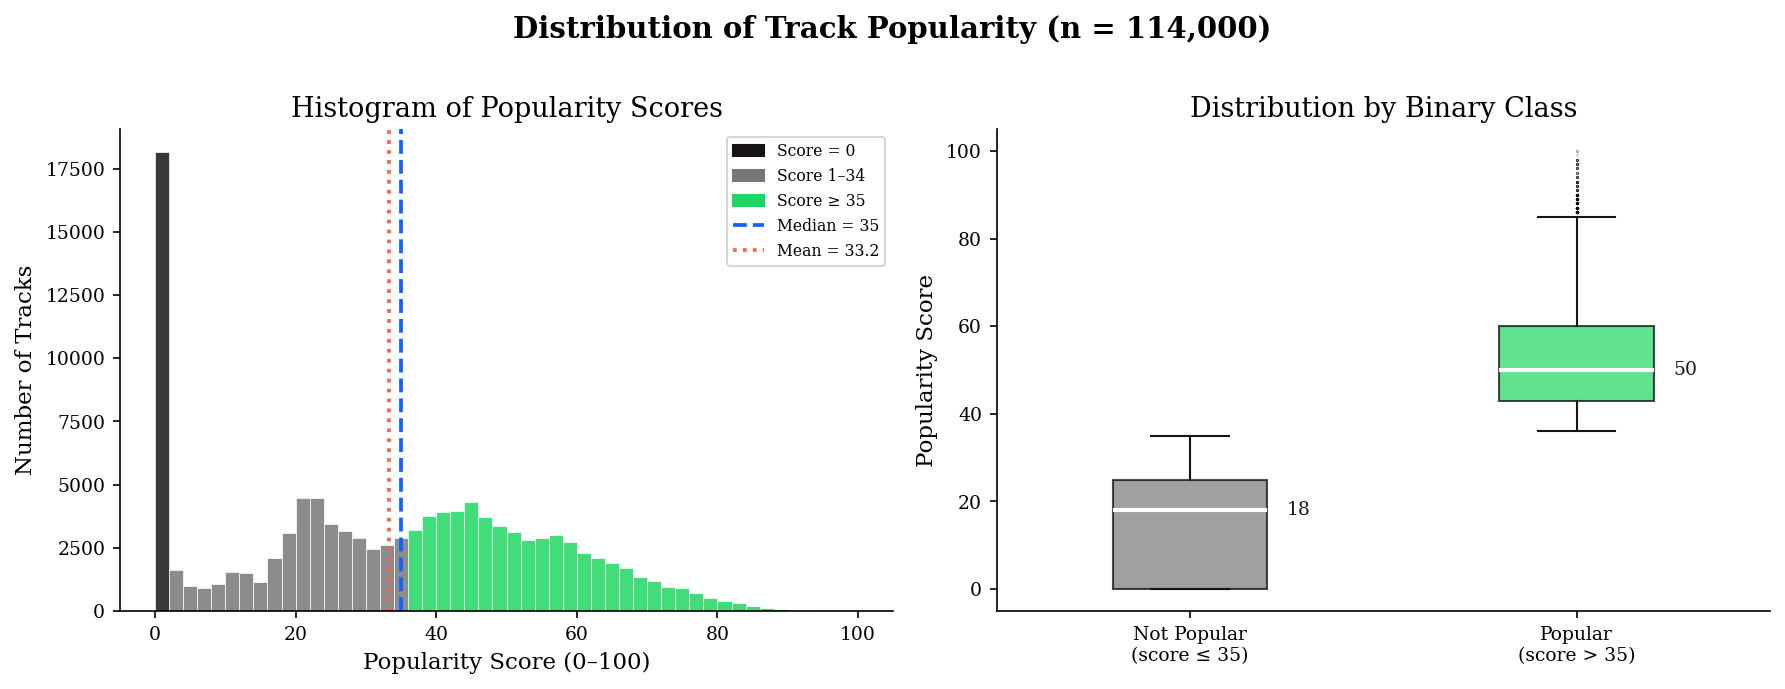

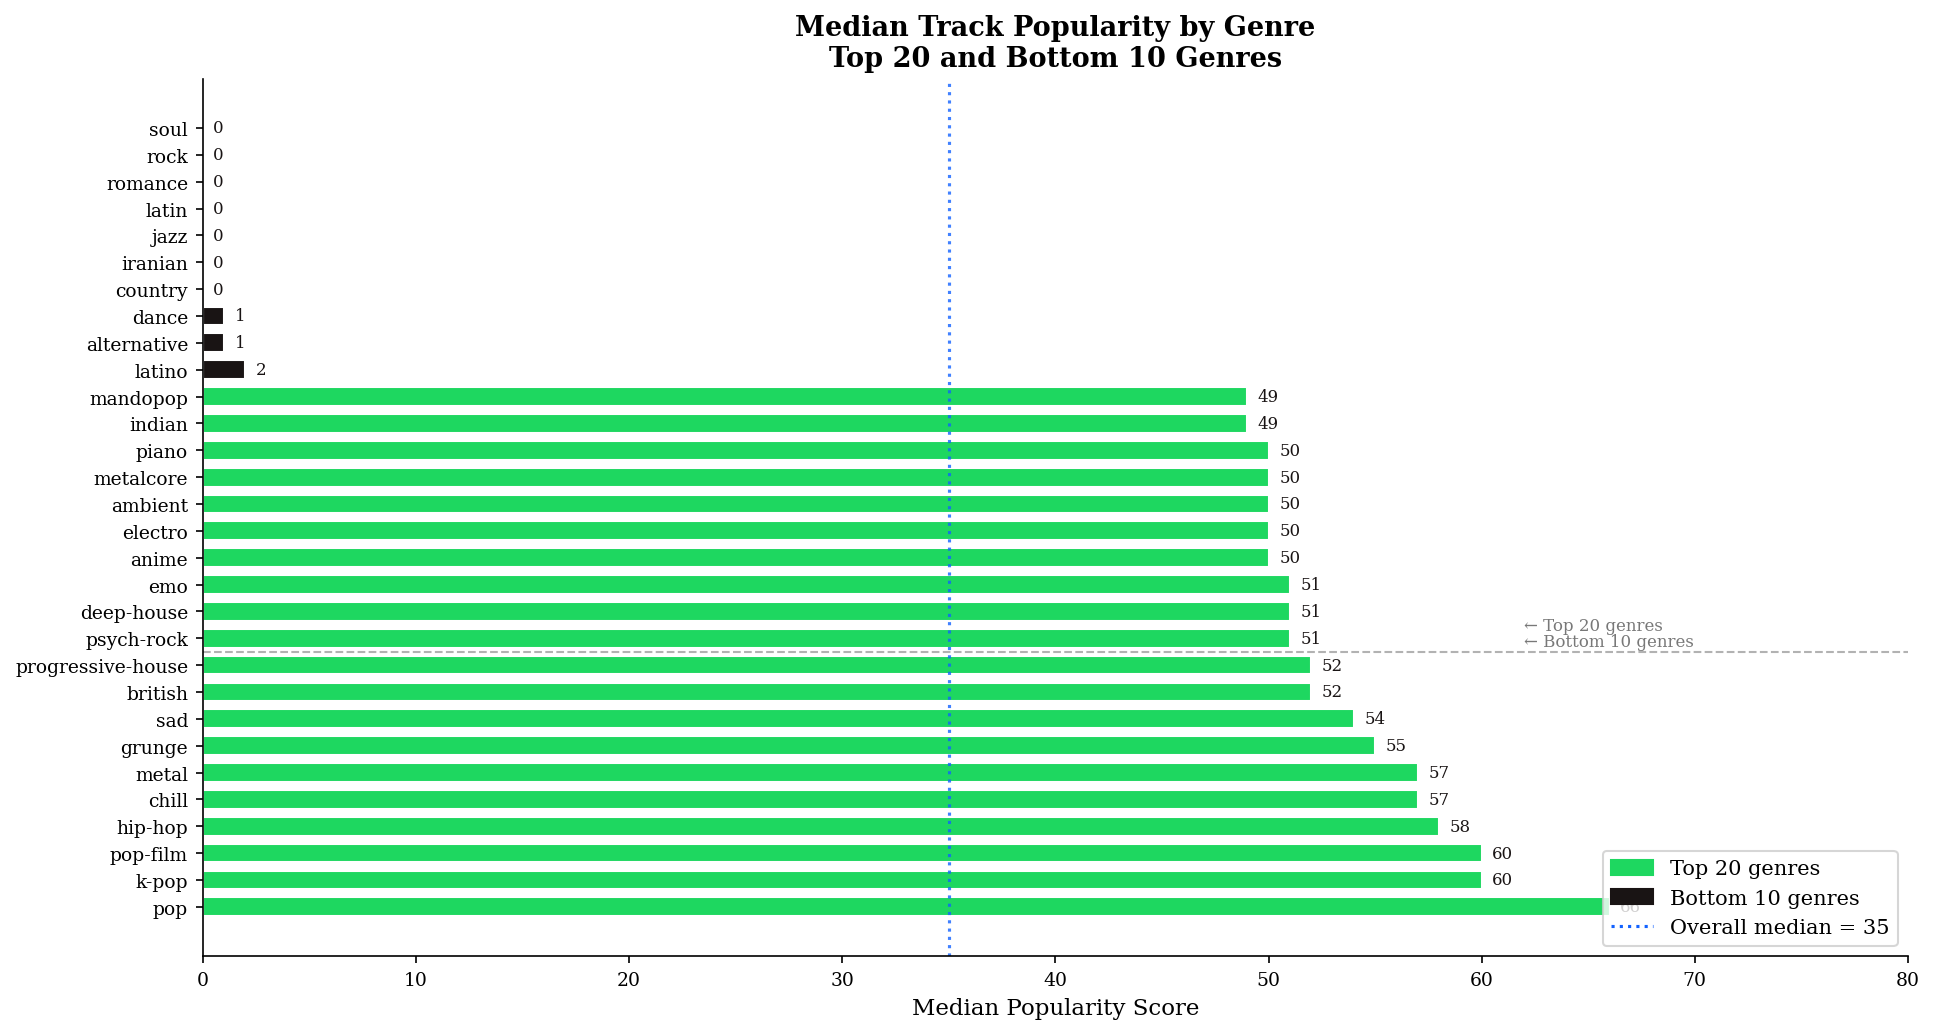

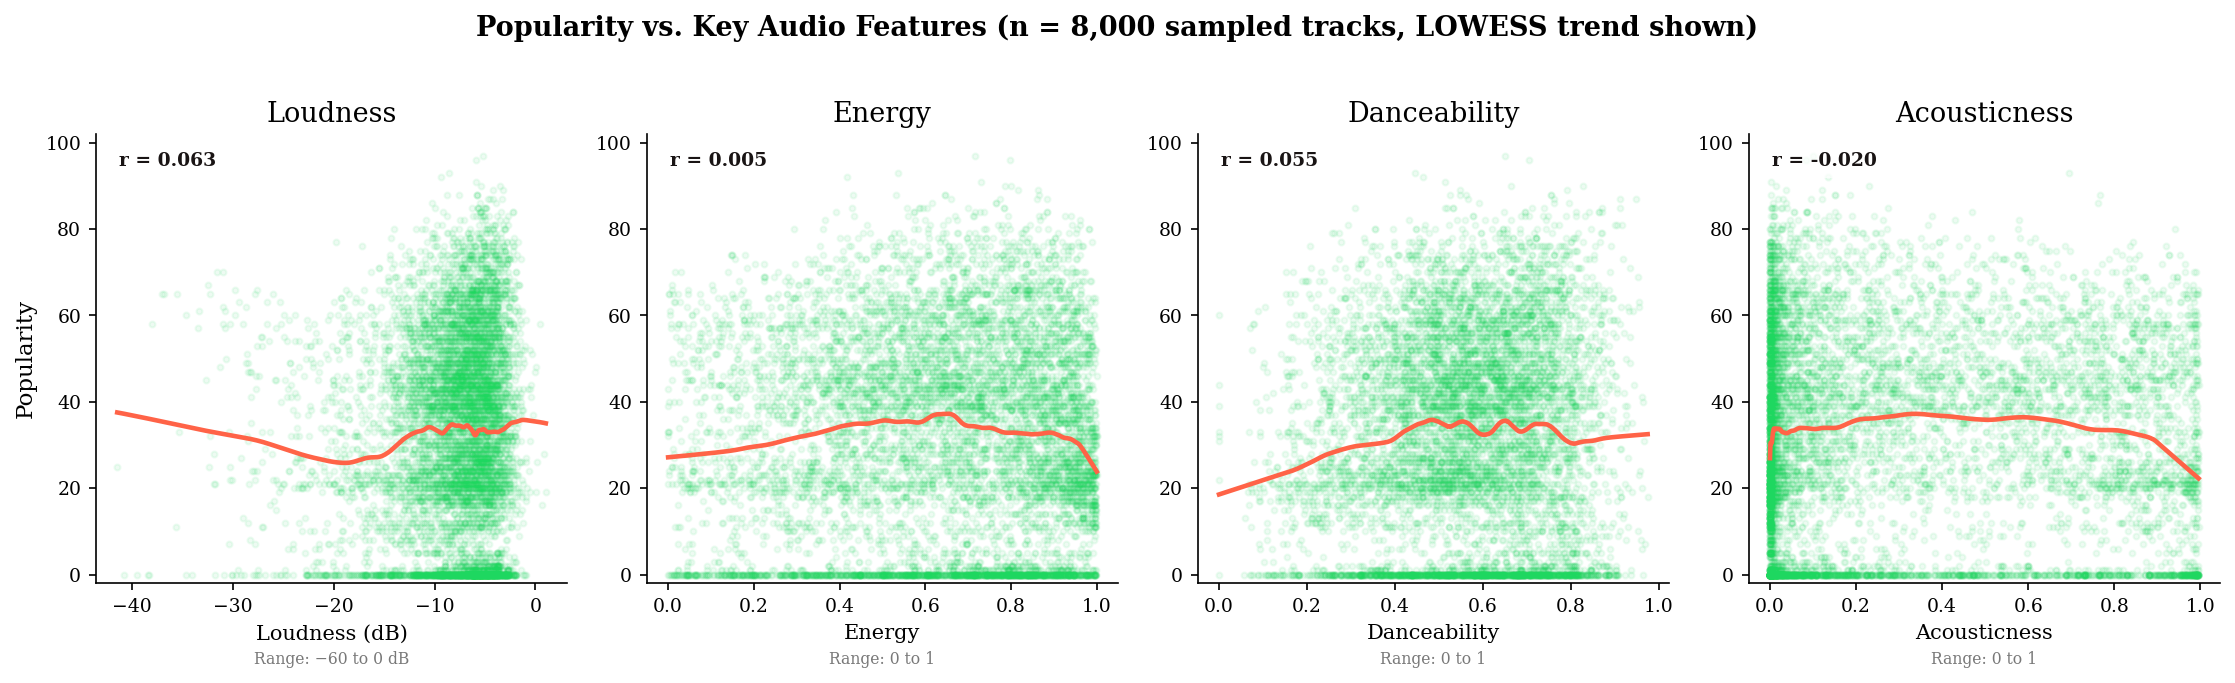

In [ ]:
# =============================================================
#  MATH 4230 Capstone — Chapter 1: Introduction & Statistical Thinking
#  Purpose: Generate figures for Spotify popularity analysis
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.nonparametric.smoothers_lowess import lowess

# ── 0. Style config ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

BLUE   = "#1262FF"
GREEN  = "#1ED760"
GRAY   = "#787878"
LIGHT  = "#F5F5F5"
DARK   = "#191414"

# ── 1. Load data ─────────────────────────────────────────────────────────────
DATA_PATH = "spotify-tracks-dataset-detailed.csv"
df = pd.read_csv(DATA_PATH)

df = df.dropna(subset=["artists", "album_name", "track_name"]).copy()

print(f"Loaded {len(df):,} tracks across {df['track_genre'].nunique()} genres")
print(f"Popularity — mean: {df['popularity'].mean():.1f}, "
      f"median: {df['popularity'].median():.0f}, "
      f"std: {df['popularity'].std():.1f}")

MEDIAN_POP = int(df["popularity"].median())
df["is_popular"] = (df["popularity"] > MEDIAN_POP).astype(int)

print(f"Binary threshold (median popularity): {MEDIAN_POP}")
print(f"Popular tracks: {df['is_popular'].sum():,} "
      f"({df['is_popular'].mean()*100:.1f}%)")

# =============================================================================
# FIGURE 1 — Popularity distribution + binary class boxplot
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor="white")
fig.suptitle("Distribution of Track Popularity (n = 114,000)",
             fontsize=14, fontweight="bold", y=1.01)

ax = axes[0]
counts, bins, patches = ax.hist(
    df["popularity"], bins=50, edgecolor="white", linewidth=0.4, alpha=0.85
)

for patch, left in zip(patches, bins[:-1]):
    if left == 0:
        patch.set_facecolor(DARK)
    elif left < MEDIAN_POP:
        patch.set_facecolor(GRAY)
    else:
        patch.set_facecolor(GREEN)

ax.axvline(MEDIAN_POP, color=BLUE, linewidth=1.8, linestyle="--")
ax.axvline(df["popularity"].mean(), color="tomato", linewidth=1.8, linestyle=":")
ax.set_xlabel("Popularity Score (0–100)")
ax.set_ylabel("Number of Tracks")
ax.set_title("Histogram of Popularity Scores")

zero_patch = mpatches.Patch(color=DARK, label="Score = 0")
low_patch  = mpatches.Patch(color=GRAY, label=f"Score 1–{MEDIAN_POP-1}")
high_patch = mpatches.Patch(color=GREEN, label=f"Score ≥ {MEDIAN_POP}")
med_line   = plt.Line2D([0], [0], color=BLUE, linestyle="--",
                        linewidth=1.8, label=f"Median = {MEDIAN_POP}")
mean_line  = plt.Line2D([0], [0], color="tomato", linestyle=":",
                        linewidth=1.8, label=f"Mean = {df['popularity'].mean():.1f}")

ax.legend(handles=[zero_patch, low_patch, high_patch, med_line, mean_line],
          loc="upper right", fontsize=7.5)

ax2 = axes[1]
colors_map = {0: GRAY, 1: GREEN}

for cls in [0, 1]:
    subset = df[df["is_popular"] == cls]["popularity"]
    ax2.boxplot(
        subset,
        positions=[cls + 1],
        widths=0.4,
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2),
        boxprops=dict(facecolor=colors_map[cls], alpha=0.7),
        whiskerprops=dict(color=DARK),
        capprops=dict(color=DARK),
        flierprops=dict(marker=".", markersize=1,
                        color=colors_map[cls], alpha=0.2)
    )

    med = subset.median()
    ax2.text(cls + 1.25, med, f"{med:.0f}",
             va="center", fontsize=9, color=DARK)

ax2.set_xticks([1, 2])
ax2.set_xticklabels([
    f"Not Popular\n(score ≤ {MEDIAN_POP})",
    f"Popular\n(score > {MEDIAN_POP})"
])
ax2.set_ylabel("Popularity Score")
ax2.set_title("Distribution by Binary Class")
ax2.set_xlim(0.5, 2.5)

plt.tight_layout()
plt.savefig("ch1_popularity_distribution.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — Median popularity by genre
# =============================================================================
genre_stats = (
    df.groupby("track_genre")["popularity"]
    .agg(median="median", mean="mean", count="count")
    .reset_index()
    .sort_values("median", ascending=False)
)

top20 = genre_stats.head(20)
bottom10 = genre_stats.tail(10)
display_df = pd.concat([top20, bottom10], ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")

bar_colors = [GREEN] * 20 + [DARK] * 10
bars = ax.barh(
    display_df["track_genre"],
    display_df["median"],
    color=bar_colors,
    edgecolor="white",
    height=0.7
)

for bar, val in zip(bars, display_df["median"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}", va="center", ha="left",
            fontsize=8, color=DARK)

ax.axhline(y=9.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text(62, 9.7, "← Bottom 10 genres", fontsize=8, color=GRAY)
ax.text(62, 10.3, "← Top 20 genres", fontsize=8, color=GRAY)

ax.axvline(MEDIAN_POP, color=BLUE, linewidth=1.5, linestyle=":", alpha=0.8)
ax.set_xlabel("Median Popularity Score")
ax.set_title("Median Track Popularity by Genre\nTop 20 and Bottom 10 Genres",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, 80)

top_patch = mpatches.Patch(color=GREEN, label="Top 20 genres")
bot_patch = mpatches.Patch(color=DARK, label="Bottom 10 genres")
med_line = plt.Line2D([0], [0], color=BLUE, linestyle=":",
                      linewidth=1.5, label=f"Overall median = {MEDIAN_POP}")

ax.legend(handles=[top_patch, bot_patch, med_line], loc="lower right")

plt.tight_layout()
plt.savefig("ch2_genre_median_popularity.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 3 — Popularity vs. 4 audio features with LOWESS trend
# =============================================================================
np.random.seed(42)
sample = df.sample(n=min(8000, len(df)), random_state=42)

features = [
    ("loudness", "Loudness (dB)", "Range: −60 to 0 dB"),
    ("energy", "Energy", "Range: 0 to 1"),
    ("danceability", "Danceability", "Range: 0 to 1"),
    ("acousticness", "Acousticness", "Range: 0 to 1"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5), facecolor="white")
fig.suptitle(
    "Popularity vs. Key Audio Features "
    "(n = 8,000 sampled tracks, LOWESS trend shown)",
    fontsize=13, fontweight="bold", y=1.02
)

for ax, (feat, xlabel, note) in zip(axes, features):
    x = sample[feat].values
    y = sample["popularity"].values

    ax.scatter(x, y, alpha=0.08, s=8, color=GREEN, rasterized=True)

    sorted_idx = np.argsort(x)
    smoothed = lowess(
        y[sorted_idx],
        x[sorted_idx],
        frac=0.15,
        return_sorted=True
    )
    ax.plot(smoothed[:, 0], smoothed[:, 1], color="tomato", linewidth=2.2)

    corr = np.corrcoef(x, y)[0, 1]
    ax.text(
        0.05, 0.93, f"r = {corr:.3f}",
        transform=ax.transAxes,
        fontsize=9,
        color=DARK,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Popularity" if ax == axes[0] else "")
    ax.set_title(feat.capitalize())
    ax.set_ylim(-2, 102)
    ax.text(0.5, -0.18, note, transform=ax.transAxes,
            fontsize=7.5, ha="center", color=GRAY)

plt.tight_layout()
plt.savefig("ch3_feature_relationships.png", dpi=300, bbox_inches="tight")

Train:      79,799 rows
Validation: 17,100 rows
Test:       17,100 rows


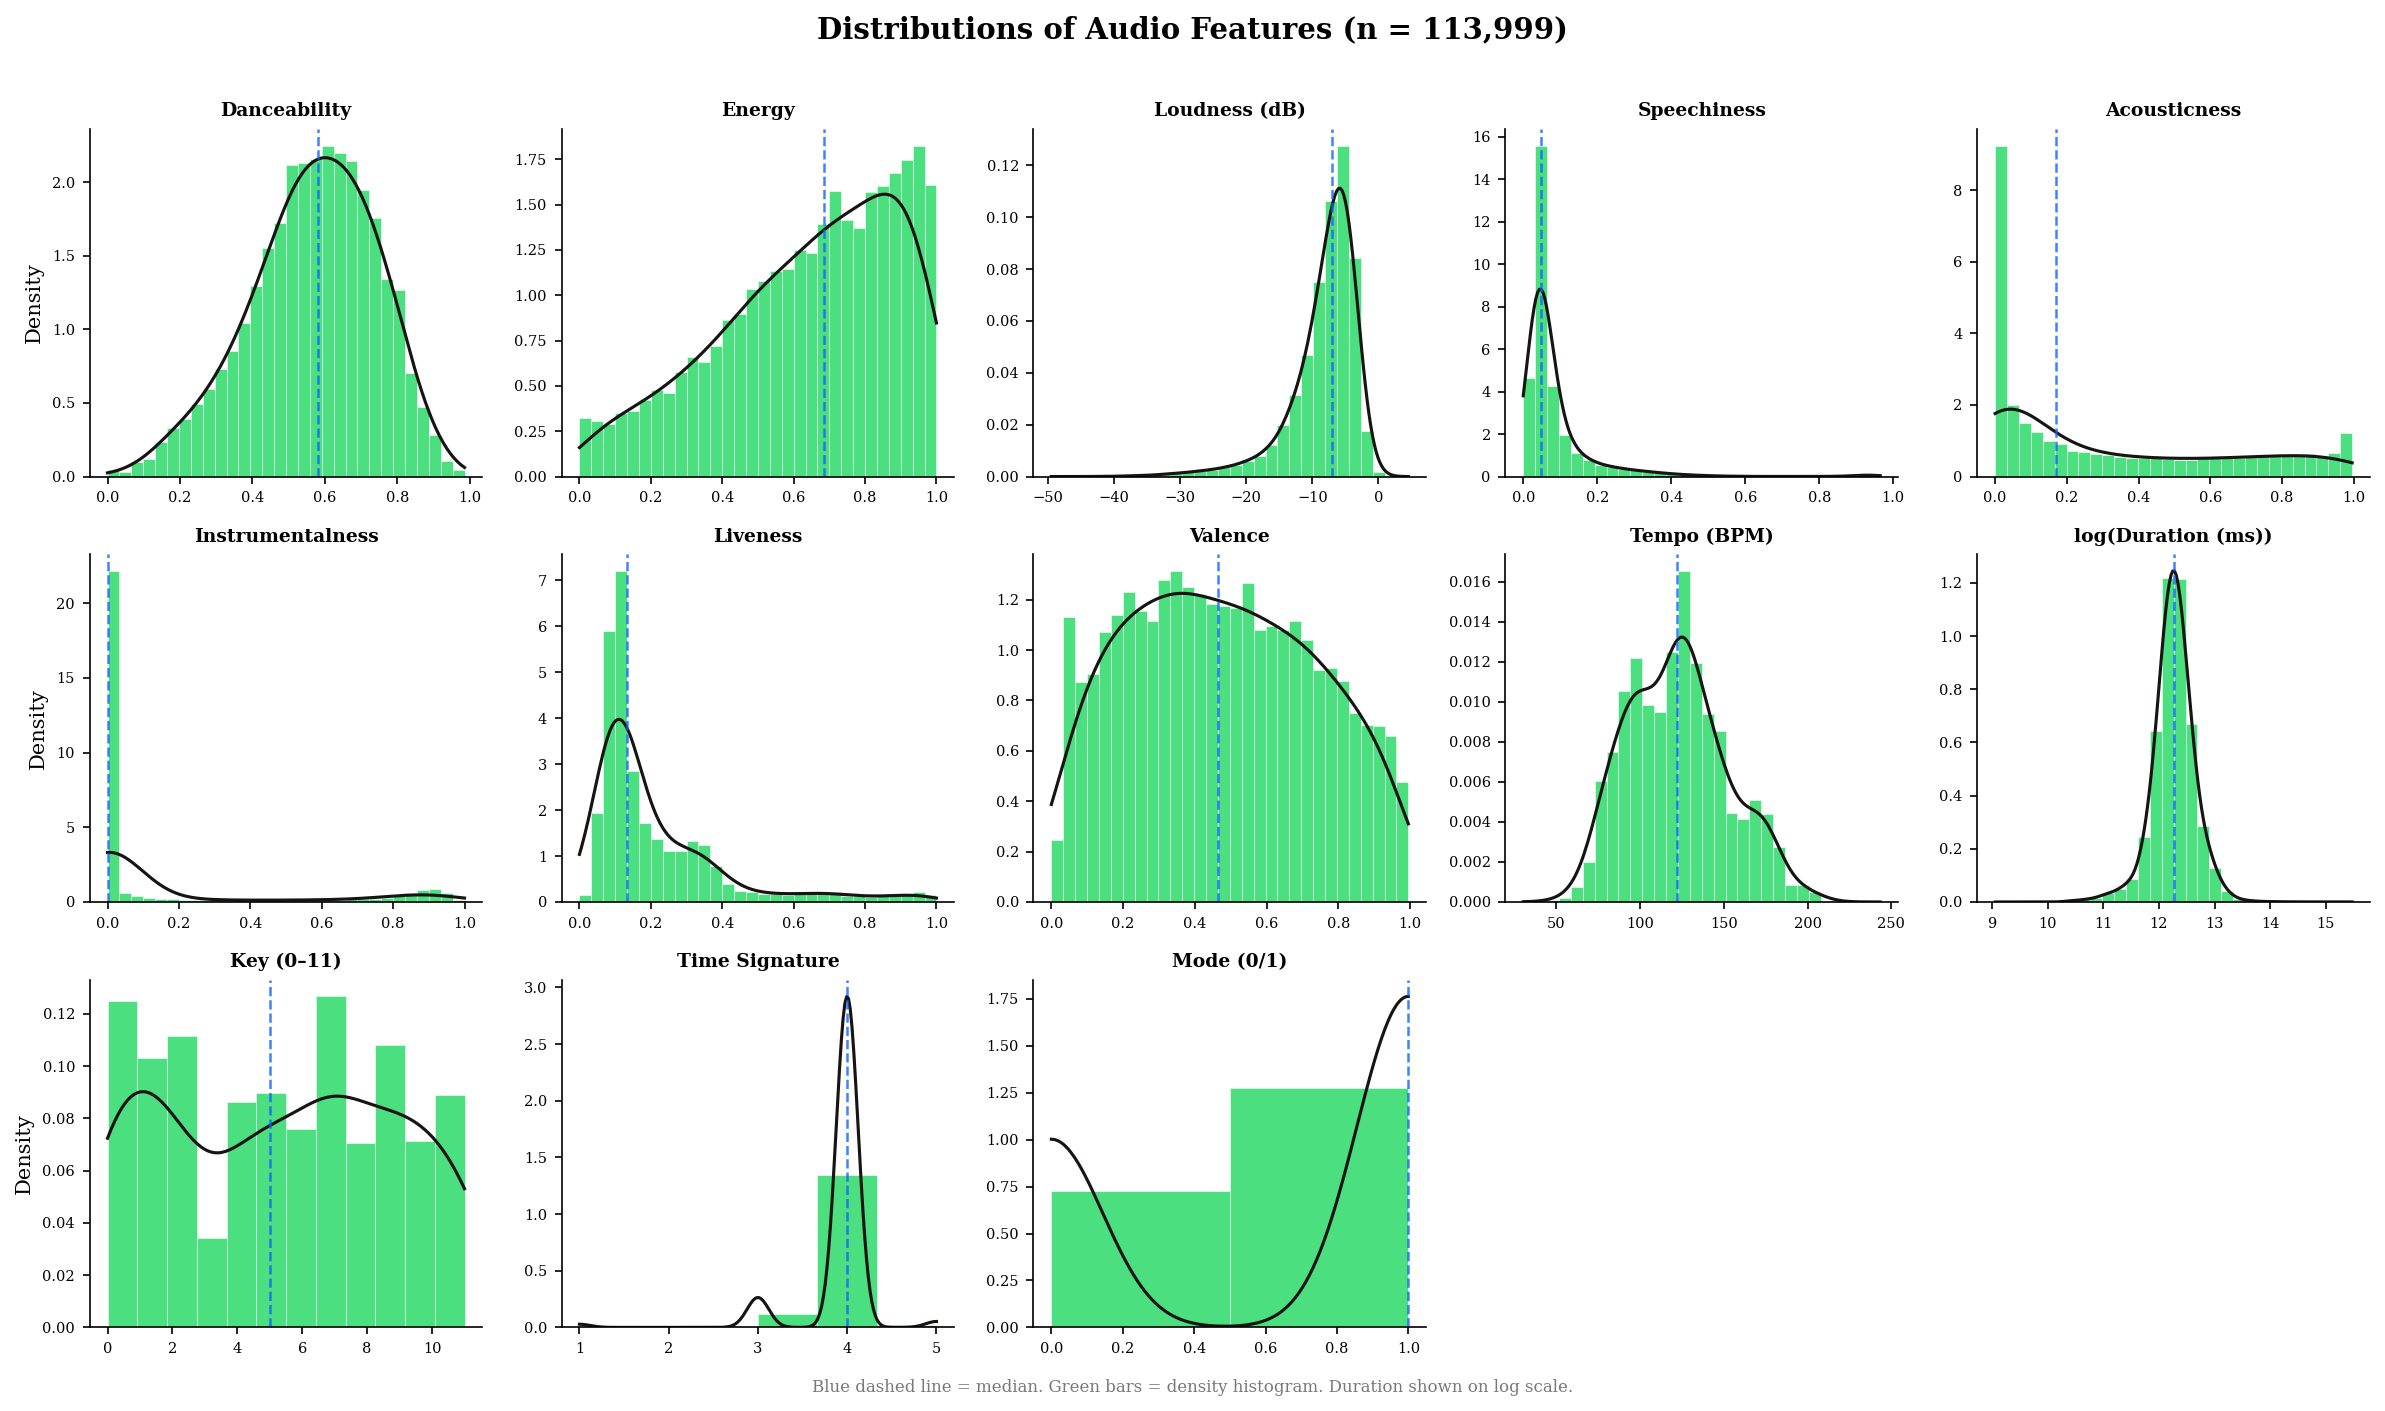

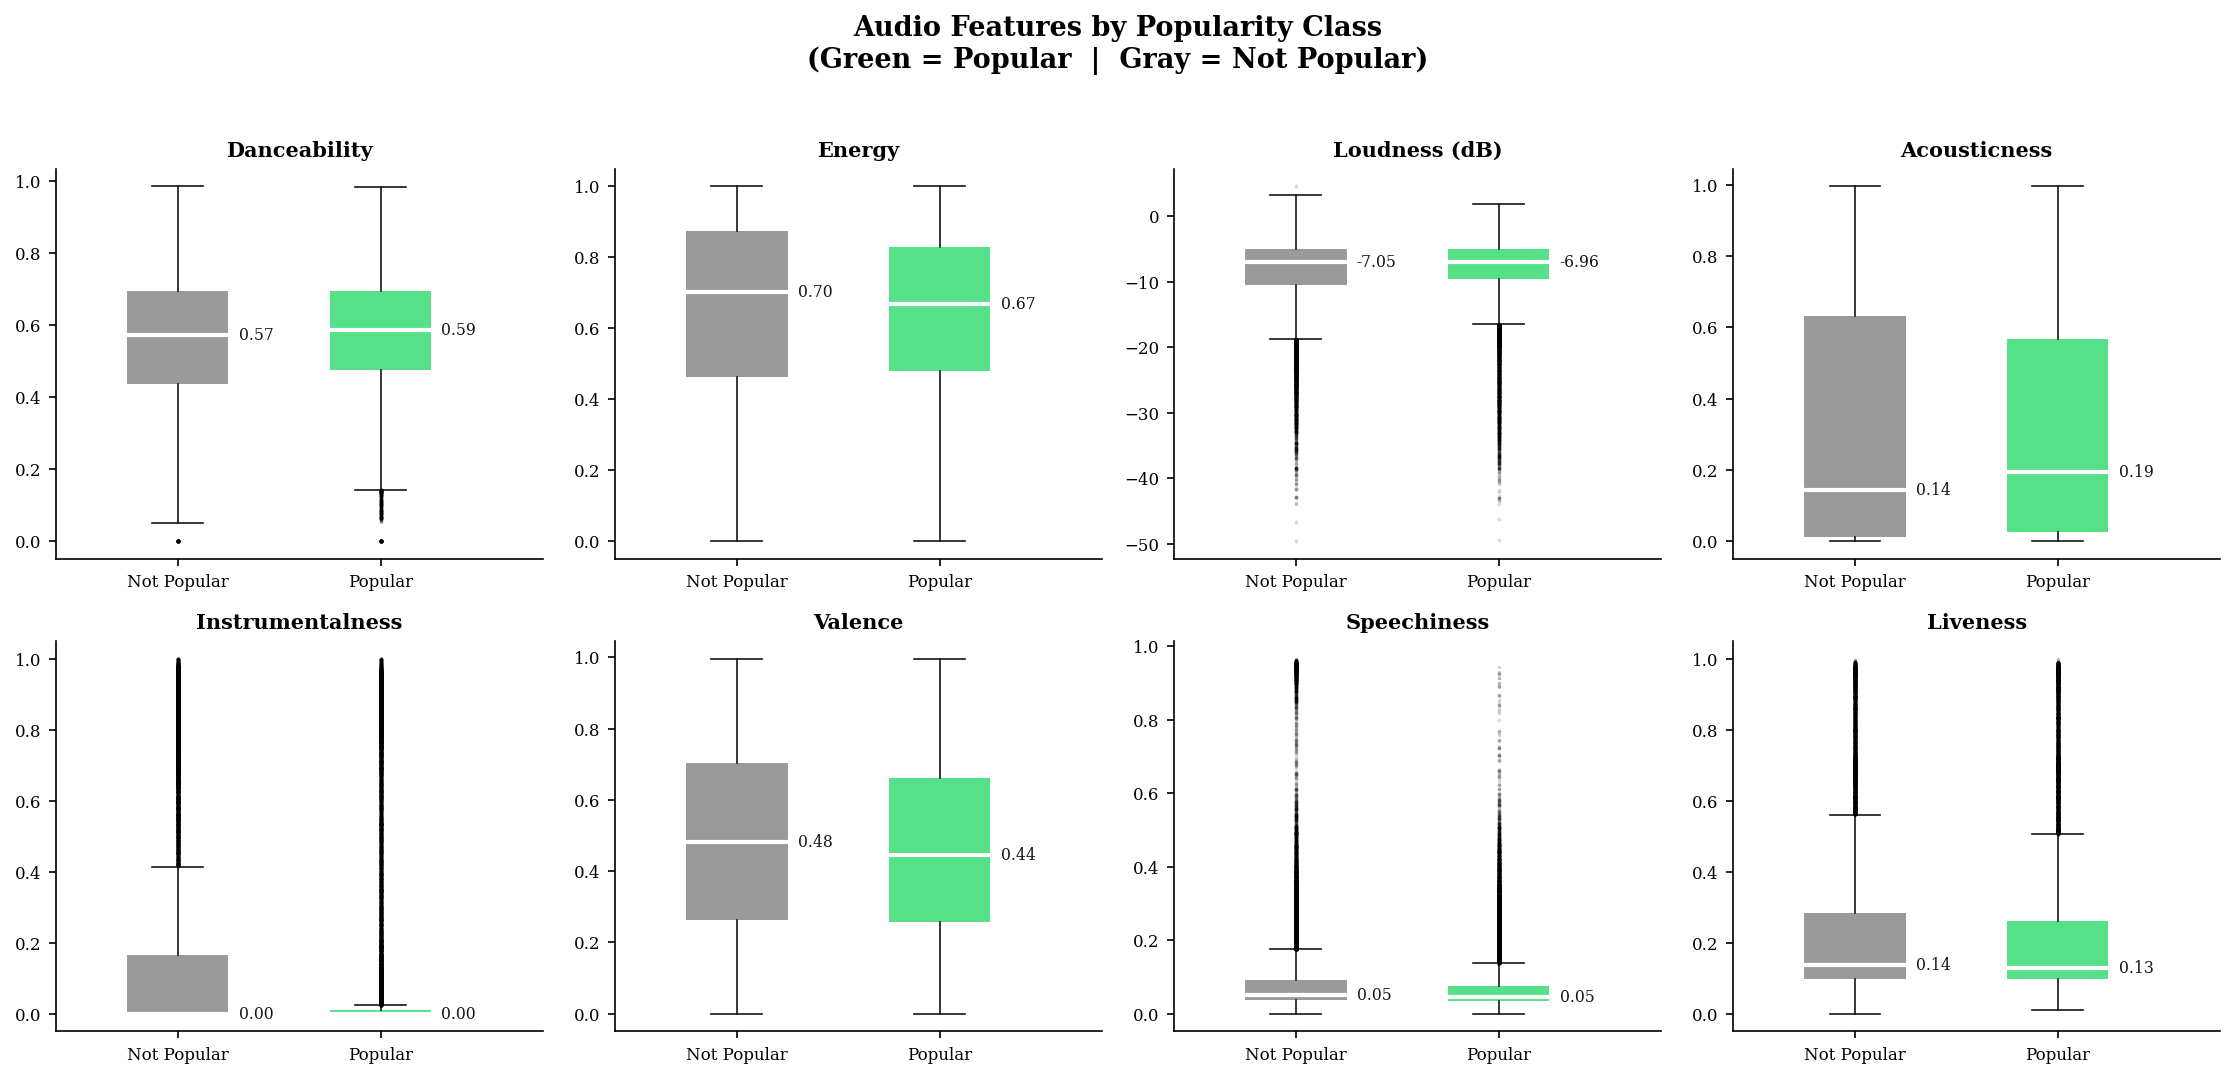

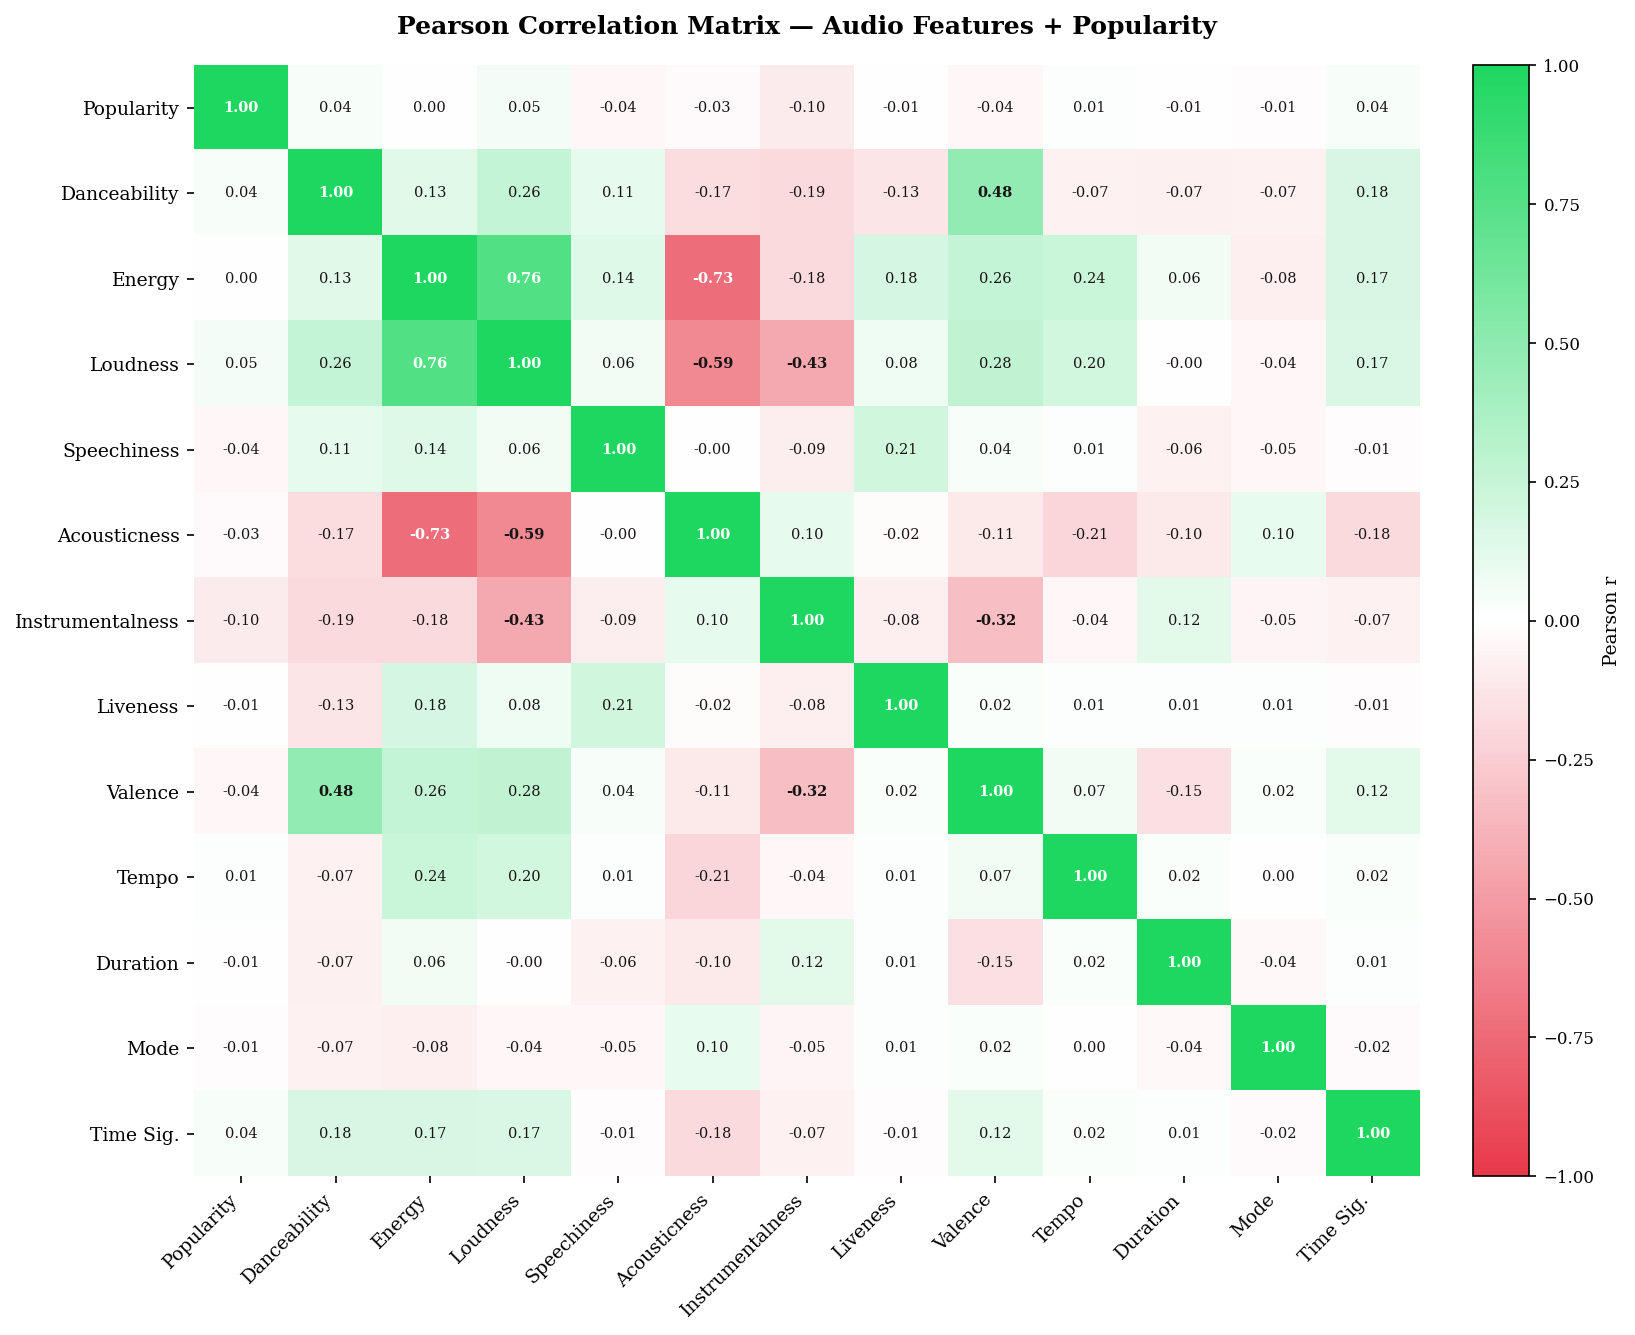

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 8,
    "ytick.labelsize"  : 8,
})

GREEN = "#1ED760"
DARK  = "#191414"
GRAY  = "#787878"
BLUE  = "#1262FF"
RED   = "#E8394A"

# ── Load & clean ──────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)

# Derive binary response (threshold = median = 35)
MEDIAN_POP = int(df["popularity"].median())
df["is_popular"] = (df["popularity"] > MEDIAN_POP).astype(int)

# Fix sentinel values (tempo=0 and time_signature=0 mean "unknown")
df["tempo"]          = df["tempo"].replace(0, np.nan)
df["time_signature"] = df["time_signature"].replace(0, np.nan)

NUMERIC_FEATURES = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms", "key", "mode", "time_signature"
]

AUDIO_FEATURES = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms", "key", "time_signature", "mode"
]

# ── Train / val / test split (70 / 15 / 15, stratified) ──────────────────────
# This split is created here and reused across all chapters
X = df.drop(columns=["popularity", "is_popular",
                       "track_id", "artists", "album_name", "track_name"])
y_cont = df["popularity"]
y_bin  = df["is_popular"]

X_trainval, X_test, y_cont_trainval, y_cont_test, y_bin_trainval, y_bin_test = \
    train_test_split(X, y_cont, y_bin, test_size=0.15,
                     random_state=42, stratify=y_bin)

X_train, X_val, y_cont_train, y_cont_val, y_bin_train, y_bin_val = \
    train_test_split(X_trainval, y_cont_trainval, y_bin_trainval,
                     test_size=0.15 / 0.85,
                     random_state=42, stratify=y_bin_trainval)

print(f"Train:      {len(X_train):,} rows")
print(f"Validation: {len(X_val):,} rows")
print(f"Test:       {len(X_test):,} rows")


# =============================================================================
# FIGURE 1 — Histograms of all 13 continuous audio features
# =============================================================================
fig, axes = plt.subplots(3, 5, figsize=(16, 9), facecolor="white")
fig.suptitle("Distributions of Audio Features (n = 113,999)",
             fontsize=14, fontweight="bold", y=1.01)

# Feature display names and optional log flag
feature_meta = [
    ("danceability",     "Danceability",     False),
    ("energy",           "Energy",           False),
    ("loudness",         "Loudness (dB)",    False),
    ("speechiness",      "Speechiness",      False),
    ("acousticness",     "Acousticness",     False),
    ("instrumentalness", "Instrumentalness", False),
    ("liveness",         "Liveness",         False),
    ("valence",          "Valence",          False),
    ("tempo",            "Tempo (BPM)",      False),
    ("duration_ms",      "Duration (ms)",    True),   # log scale
    ("key",              "Key (0–11)",       False),
    ("time_signature",   "Time Signature",   False),
    ("mode",             "Mode (0/1)",       False),
]

axes_flat = axes.flatten()

for i, (feat, label, use_log) in enumerate(feature_meta):
    ax = axes_flat[i]
    data = df[feat].dropna()
    if use_log:
        data = np.log(data + 1)
        label = f"log({label})"

    # Histogram
    n_bins = 30 if feat not in ["key", "mode", "time_signature"] else \
             (12 if feat == "key" else (2 if feat == "mode" else 6))
    ax.hist(data, bins=n_bins, color=GREEN, edgecolor="white",
            linewidth=0.3, alpha=0.8, density=True)

    # KDE overlay using numpy
    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(data.dropna(), bw_method=0.3)
        x_range = np.linspace(data.min(), data.max(), 200)
        ax.plot(x_range, kde(x_range), color=DARK, linewidth=1.5)
    except Exception:
        pass

    # Median line
    ax.axvline(data.median(), color=BLUE, linewidth=1.2,
               linestyle="--", alpha=0.8)

    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Density" if i % 5 == 0 else "")
    ax.tick_params(labelsize=7)

# Hide unused subplot (we have 13 features, 15 slots)
for j in range(len(feature_meta), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Add a shared legend note
fig.text(0.5, -0.01,
         "Blue dashed line = median. Green bars = density histogram. "
         "Duration shown on log scale.",
         ha="center", fontsize=8, color=GRAY)

plt.tight_layout()
plt.savefig("ch2_distributions.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — Feature boxplots by popular class
# =============================================================================
# Use the 8 most interpretable continuous features for the boxplots
BOX_FEATURES = [
    ("danceability",     "Danceability"),
    ("energy",           "Energy"),
    ("loudness",         "Loudness (dB)"),
    ("acousticness",     "Acousticness"),
    ("instrumentalness", "Instrumentalness"),
    ("valence",          "Valence"),
    ("speechiness",      "Speechiness"),
    ("liveness",         "Liveness"),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 7), facecolor="white")
fig.suptitle("Audio Features by Popularity Class\n(Green = Popular  |  Gray = Not Popular)",
             fontsize=13, fontweight="bold", y=1.02)

axes_flat = axes.flatten()

for i, (feat, label) in enumerate(BOX_FEATURES):
    ax = axes_flat[i]

    pop_data   = df[df["is_popular"] == 1][feat].dropna()
    unpop_data = df[df["is_popular"] == 0][feat].dropna()

    bp = ax.boxplot(
        [unpop_data, pop_data],
        positions=[1, 2],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2.0),
        whiskerprops=dict(color=DARK, linewidth=0.8),
        capprops=dict(color=DARK, linewidth=0.8),
        flierprops=dict(marker=".", markersize=1.5,
                        color=GRAY, alpha=0.15),
        boxprops=dict(linewidth=0)
    )

    # Color the boxes
    bp["boxes"][0].set_facecolor(GRAY)
    bp["boxes"][0].set_alpha(0.75)
    bp["boxes"][1].set_facecolor(GREEN)
    bp["boxes"][1].set_alpha(0.75)

    # Annotate medians
    for pos, data, color in [(1, unpop_data, DARK), (2, pop_data, DARK)]:
        med = data.median()
        ax.text(pos + 0.3, med, f"{med:.2f}",
                va="center", fontsize=7.5, color=color)

    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Not Popular", "Popular"], fontsize=8)
    ax.set_xlim(0.4, 2.8)

plt.tight_layout()
plt.savefig("ch2_boxplots.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 3 — Pearson correlation heatmap
# =============================================================================
CORR_COLS = [
    "popularity", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms", "mode", "time_signature"
]

CORR_LABELS = [
    "Popularity", "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness", "Valence",
    "Tempo", "Duration", "Mode", "Time Sig."
]

corr_matrix = df[CORR_COLS].corr()

# Custom diverging colormap: red → white → green
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "rg_diverge", [RED, "white", GREEN], N=256
)

fig, ax = plt.subplots(figsize=(11, 9), facecolor="white")

im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")

# Axis labels
ax.set_xticks(range(len(CORR_LABELS)))
ax.set_yticks(range(len(CORR_LABELS)))
ax.set_xticklabels(CORR_LABELS, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(CORR_LABELS, fontsize=9)

# Annotate cells with r values; bold the diagonal and anything |r|>0.3
for i in range(len(CORR_LABELS)):
    for j in range(len(CORR_LABELS)):
        val = corr_matrix.values[i, j]
        weight = "bold" if abs(val) > 0.3 or i == j else "normal"
        color  = "white" if abs(val) > 0.6 else DARK
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color=color, fontweight=weight)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title("Pearson Correlation Matrix — Audio Features + Popularity",
             fontsize=12, fontweight="bold", pad=15)

# Highlight the popularity row/column with a box
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("ch2_corr.png", dpi=300, bbox_inches="tight")

Train R²  : 0.26121
Test  R²  : 0.25869
Test RMSE : 19.2475


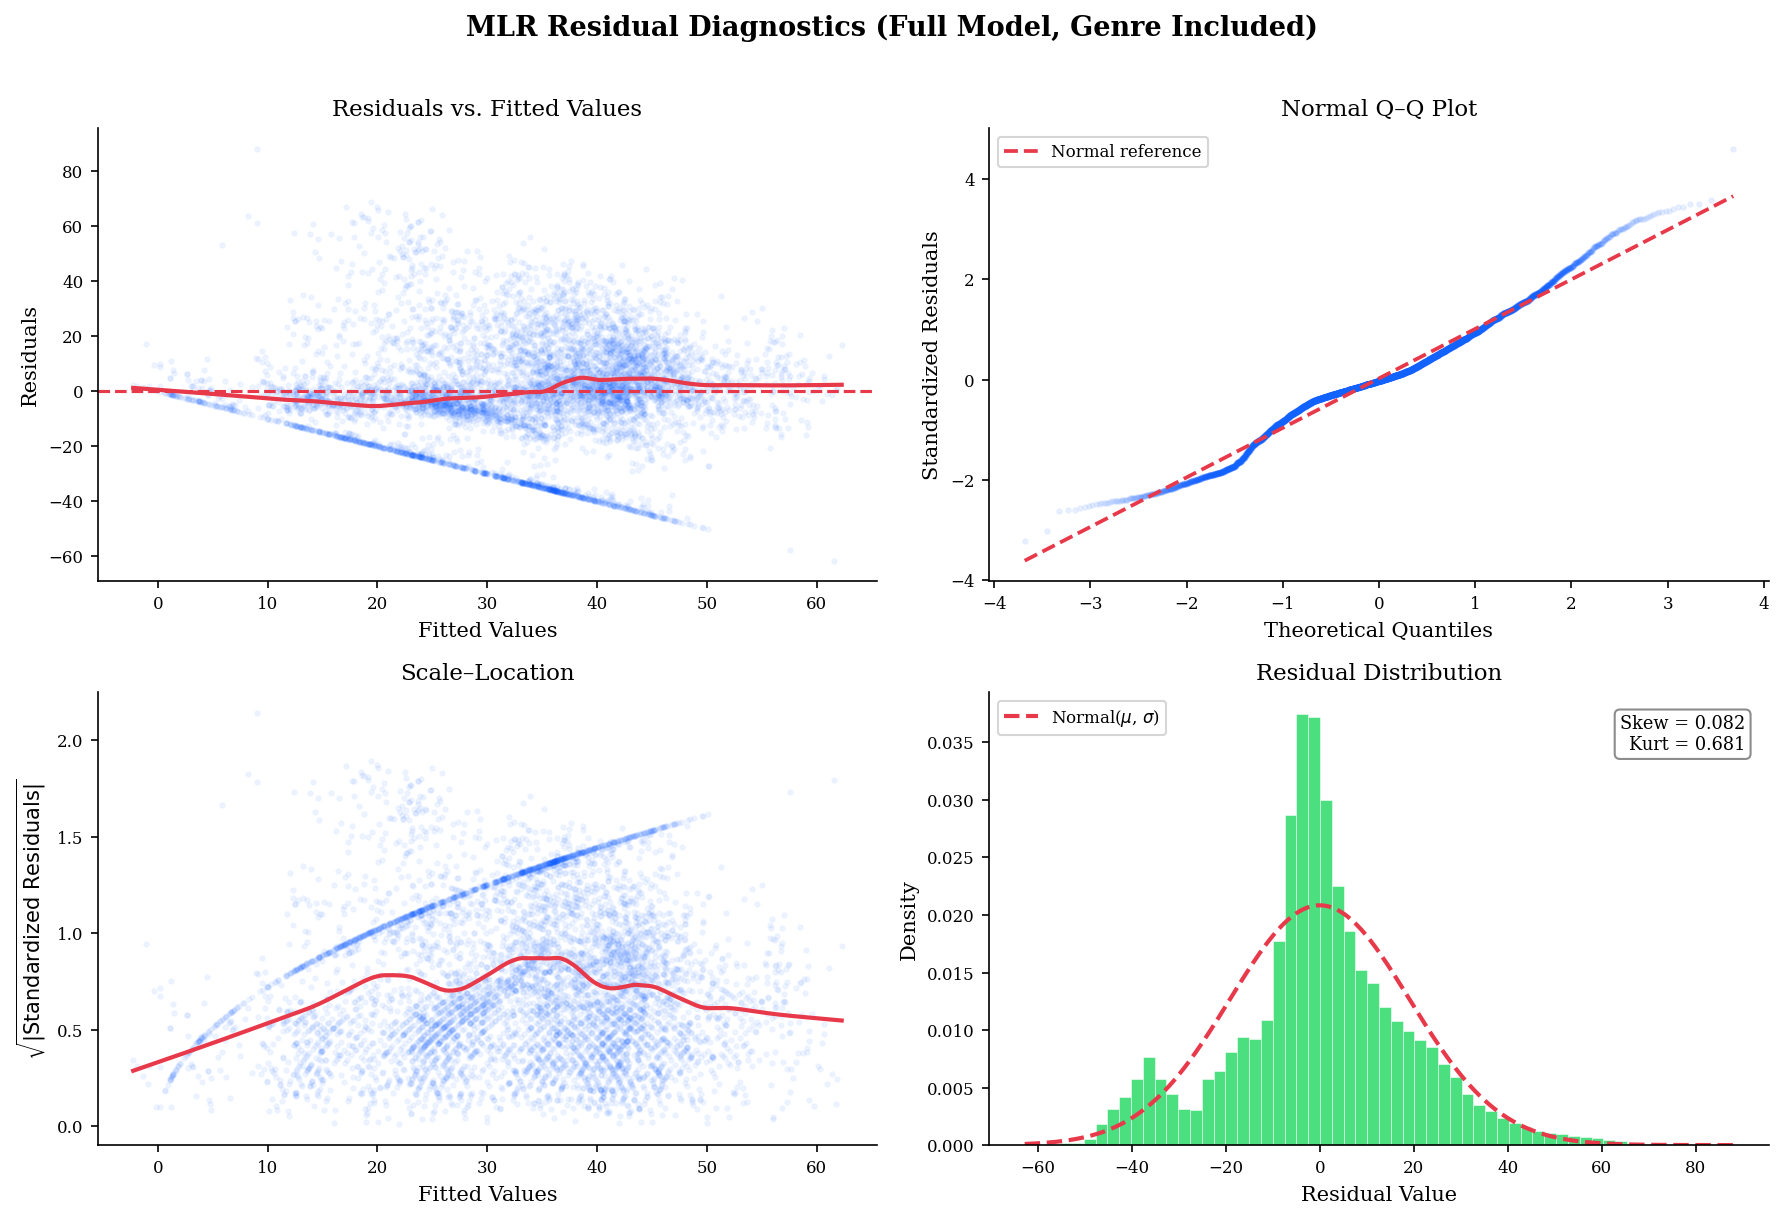

<Figure size 960x720 with 0 Axes>

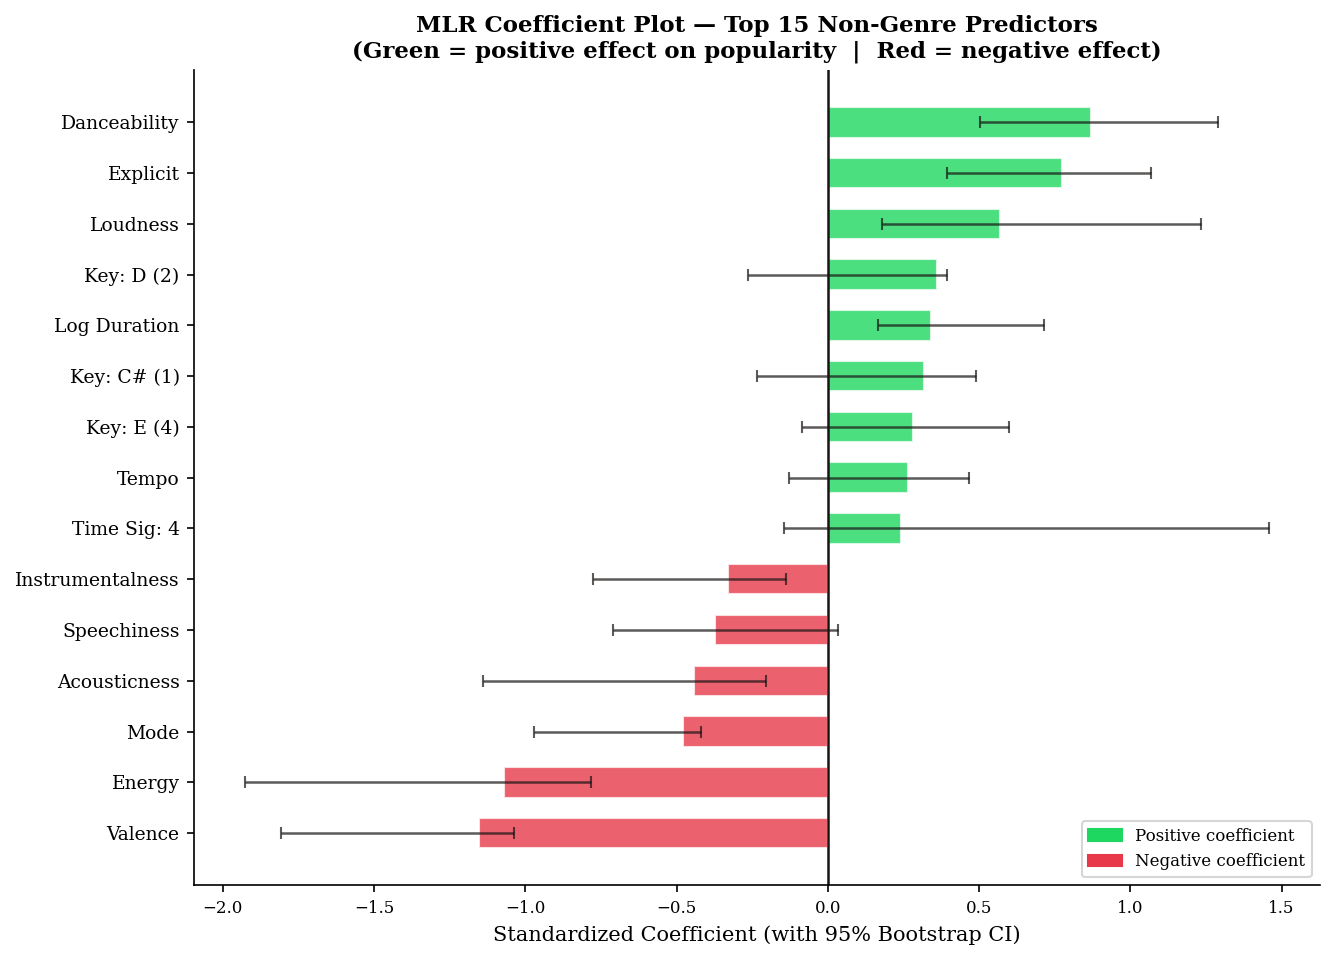

<Figure size 960x720 with 0 Axes>

In [ ]:
"""
MATH 4230 — Capstone Project
Chapter 4: Multiple Linear Regression
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch4_diagnostics.png  : 4-panel residual diagnostics
  Figure 2 — ch4_coef_plot.png    : coefficient plot (non-genre predictors)
  Figure 3 — ch4_genre_coefs.png  : all 113 genre coefficients bar chart
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 8,
    "ytick.labelsize"  : 8,
})

GREEN = "#1ED760"
DARK  = "#191414"
GRAY  = "#787878"
BLUE  = "#1262FF"
RED   = "#E8394A"

# ── Load & prepare ────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]   = (df["popularity"] > 35).astype(int)
df["tempo"]        = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0, np.nan).median())
df["time_signature"] = df["time_signature"].replace(0, np.nan).fillna(4.0)
df["log_duration"] = np.log(df["duration_ms"])
df["explicit_int"] = df["explicit"].astype(int)
df["key_int"]      = df["key"].astype(int)
df["ts_int"]       = df["time_signature"].astype(int)

CONT = ["danceability","energy","loudness","speechiness","acousticness",
        "instrumentalness","liveness","valence","tempo","log_duration"]
BIN  = ["mode","explicit_int"]

key_d   = pd.get_dummies(df["key_int"],       prefix="key",   drop_first=True)
ts_d    = pd.get_dummies(df["ts_int"],         prefix="ts",    drop_first=True)
genre_d = pd.get_dummies(df["track_genre"],    prefix="genre", drop_first=True)

X_full = pd.concat([df[CONT + BIN], key_d, ts_d, genre_d], axis=1).astype(float)
y  = df["popularity"]
yb = df["is_popular"]

# ── Train / val / test split ──────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X_full, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, _, _ = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_train)
X_te_s   = scaler.transform(X_test)

# ── Fit full MLR ──────────────────────────────────────────────────────────────
lr = LinearRegression().fit(X_tr_s, y_train)

y_pred_train = lr.predict(X_tr_s)
y_pred_test  = lr.predict(X_te_s)
resid        = y_train.values - y_pred_train
resid_std    = (resid - resid.mean()) / resid.std()

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2   = lr.score(X_te_s, y_test)
train_r2  = lr.score(X_tr_s, y_train)

print(f"Train R²  : {train_r2:.5f}")
print(f"Test  R²  : {test_r2:.5f}")
print(f"Test RMSE : {test_rmse:.4f}")

# ── Coefficient arrays ────────────────────────────────────────────────────────
feat_names = X_full.columns.tolist()
coef_df    = pd.DataFrame({"feature": feat_names, "coef": lr.coef_})

# Non-genre coefficients
non_genre = coef_df[~coef_df["feature"].str.startswith("genre_")].copy()
non_genre_top = non_genre.reindex(
    non_genre["coef"].abs().sort_values(ascending=False).index
).head(15)

# Genre coefficients
genre_coefs = coef_df[coef_df["feature"].str.startswith("genre_")].copy()
genre_coefs["genre"] = genre_coefs["feature"].str.replace("genre_", "")
genre_coefs = genre_coefs.sort_values("coef", ascending=True)


# =============================================================================
# FIGURE 1 — 4-panel residual diagnostics
# =============================================================================
np.random.seed(42)
idx = np.random.choice(len(resid), size=6000, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor="white")
fig.suptitle("MLR Residual Diagnostics (Full Model, Genre Included)",
             fontsize=13, fontweight="bold", y=1.01)

# Panel 1 — Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(y_pred_train[idx], resid[idx],
           alpha=0.05, s=5, color=BLUE, rasterized=True)
ax.axhline(0, color=RED, linewidth=1.5, linestyle="--")
si = np.argsort(y_pred_train[idx])
sm = lowess(resid[idx][si], y_pred_train[idx][si], frac=0.2, return_sorted=True)
ax.plot(sm[:, 0], sm[:, 1], color=RED, linewidth=2)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs. Fitted Values")

# Panel 2 — Q-Q plot
from scipy import stats as scipy_stats
ax = axes[0, 1]
(osm, osr), (slope_qq, intercept_qq, _) = \
    scipy_stats.probplot(resid_std[idx], dist="norm")
ax.scatter(osm, osr, alpha=0.07, s=5, color=BLUE, rasterized=True)
qq_x = np.array([min(osm), max(osm)])
ax.plot(qq_x, intercept_qq + slope_qq * qq_x,
        color=RED, linewidth=1.8, linestyle="--", label="Normal reference")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Standardized Residuals")
ax.set_title("Normal Q–Q Plot")
ax.legend(fontsize=8)

# Panel 3 — Scale-Location
ax = axes[1, 0]
sqrt_resid = np.sqrt(np.abs(resid_std[idx]))
ax.scatter(y_pred_train[idx], sqrt_resid,
           alpha=0.05, s=5, color=BLUE, rasterized=True)
si3 = np.argsort(y_pred_train[idx])
sm3 = lowess(sqrt_resid[si3], y_pred_train[idx][si3], frac=0.2, return_sorted=True)
ax.plot(sm3[:, 0], sm3[:, 1], color=RED, linewidth=2)
ax.set_xlabel("Fitted Values")
ax.set_ylabel(r"$\sqrt{|\text{Standardized Residuals}|}$")
ax.set_title("Scale–Location")

# Panel 4 — Residual histogram
ax = axes[1, 1]
ax.hist(resid, bins=60, color=GREEN, edgecolor="white",
        linewidth=0.3, alpha=0.8, density=True)
xr   = np.linspace(resid.min(), resid.max(), 300)
norm_pdf = scipy_stats.norm.pdf(xr, resid.mean(), resid.std())
ax.plot(xr, norm_pdf, color=RED, linewidth=2, linestyle="--",
        label="Normal($\\mu$, $\\sigma$)")
ax.set_xlabel("Residual Value")
ax.set_ylabel("Density")
ax.set_title("Residual Distribution")
ax.legend(fontsize=8)
ax.text(0.97, 0.95,
        f"Skew = {float(pd.Series(resid).skew()):.3f}\n"
        f"Kurt = {float(pd.Series(resid).kurtosis()):.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5,
        bbox=dict(facecolor="white", edgecolor=GRAY,
                  boxstyle="round,pad=0.3", alpha=0.85))

plt.tight_layout()
plt.show()
plt.savefig("ch4_diagnostics.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — Coefficient plot for top 15 non-genre predictors
# =============================================================================
# Bootstrap 95% CI for each coefficient (500 resamples, subsample for speed)
np.random.seed(42)
n_boot   = 500
sub_size = 20000   # subsample training rows for bootstrap speed
sub_idx  = np.random.choice(X_tr_s.shape[0], sub_size, replace=False)
X_sub    = X_tr_s[sub_idx]
y_sub    = y_train.values[sub_idx]

boot_coefs = np.zeros((n_boot, X_tr_s.shape[1]))
for b in range(n_boot):
    bi = np.random.choice(sub_size, sub_size, replace=True)
    lrb = LinearRegression().fit(X_sub[bi], y_sub[bi])
    boot_coefs[b] = lrb.coef_

ci_lo_all = np.percentile(boot_coefs, 2.5,  axis=0)
ci_hi_all = np.percentile(boot_coefs, 97.5, axis=0)

# Get non-genre indices
ng_mask = np.array([not f.startswith("genre_") for f in feat_names])
ng_idx  = np.where(ng_mask)[0]
top15_idx = ng_idx[
    np.argsort(np.abs(lr.coef_[ng_mask]))[::-1][:15]
]

# Clean display names
label_map = {
    "danceability":    "Danceability",
    "energy":          "Energy",
    "loudness":        "Loudness",
    "speechiness":     "Speechiness",
    "acousticness":    "Acousticness",
    "instrumentalness":"Instrumentalness",
    "liveness":        "Liveness",
    "valence":         "Valence",
    "tempo":           "Tempo",
    "log_duration":    "Log Duration",
    "mode":            "Mode",
    "explicit_int":    "Explicit",
    "key_1":  "Key: C# (1)", "key_2": "Key: D (2)",
    "key_3":  "Key: Eb (3)", "key_4": "Key: E (4)",
    "key_5":  "Key: F (5)",  "key_6": "Key: F# (6)",
    "key_7":  "Key: G (7)",  "key_8": "Key: Ab (8)",
    "key_9":  "Key: A (9)",  "key_10":"Key: Bb (10)",
    "key_11": "Key: B (11)",
    "ts_3": "Time Sig: 3",   "ts_4": "Time Sig: 4",
    "ts_5": "Time Sig: 5",
}

plot_coefs  = lr.coef_[top15_idx]
plot_labels = [label_map.get(feat_names[i], feat_names[i]) for i in top15_idx]
plot_lo     = ci_lo_all[top15_idx]
plot_hi     = ci_hi_all[top15_idx]

# Sort by coefficient value for readability
sort_order  = np.argsort(plot_coefs)
plot_coefs  = plot_coefs[sort_order]
plot_labels = [plot_labels[i] for i in sort_order]
plot_lo     = plot_lo[sort_order]
plot_hi     = plot_hi[sort_order]
y_pos       = np.arange(len(plot_coefs))

fig, ax = plt.subplots(figsize=(9, 6.5), facecolor="white")

bar_colors = [RED if c < 0 else GREEN for c in plot_coefs]
ax.barh(y_pos, plot_coefs, color=bar_colors, alpha=0.8,
        edgecolor="white", height=0.6)

# Error bars (bootstrap CI)
ax.errorbar(plot_coefs, y_pos,
            xerr=[plot_coefs - plot_lo, plot_hi - plot_coefs],
            fmt="none", color=DARK, capsize=3, linewidth=1.2, alpha=0.7)

ax.axvline(0, color=DARK, linewidth=1.2, linestyle="-")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_labels, fontsize=9)
ax.set_xlabel("Standardized Coefficient (with 95% Bootstrap CI)")
ax.set_title("MLR Coefficient Plot — Top 15 Non-Genre Predictors\n"
             "(Green = positive effect on popularity  |  Red = negative effect)",
             fontweight="bold")

green_p = mpatches.Patch(color=GREEN, label="Positive coefficient")
red_p   = mpatches.Patch(color=RED,   label="Negative coefficient")
ax.legend(handles=[green_p, red_p], fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()
plt.savefig("ch4_coef_plot.png", dpi=300, bbox_inches="tight")

Test Accuracy : 0.75064
Test ROC-AUC  : 0.83850
Avg Precision : 0.83596


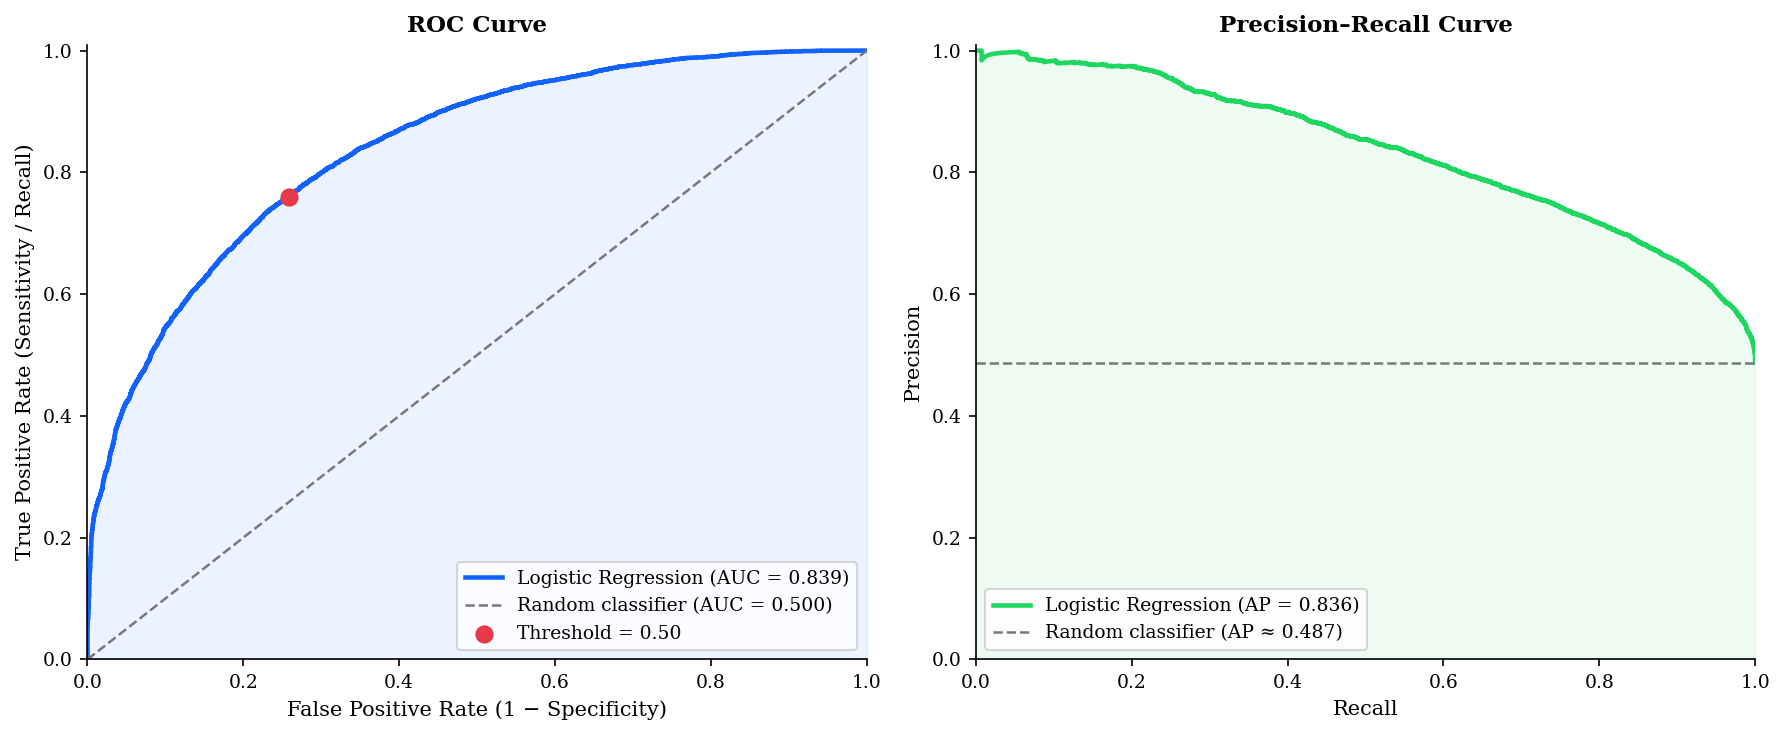

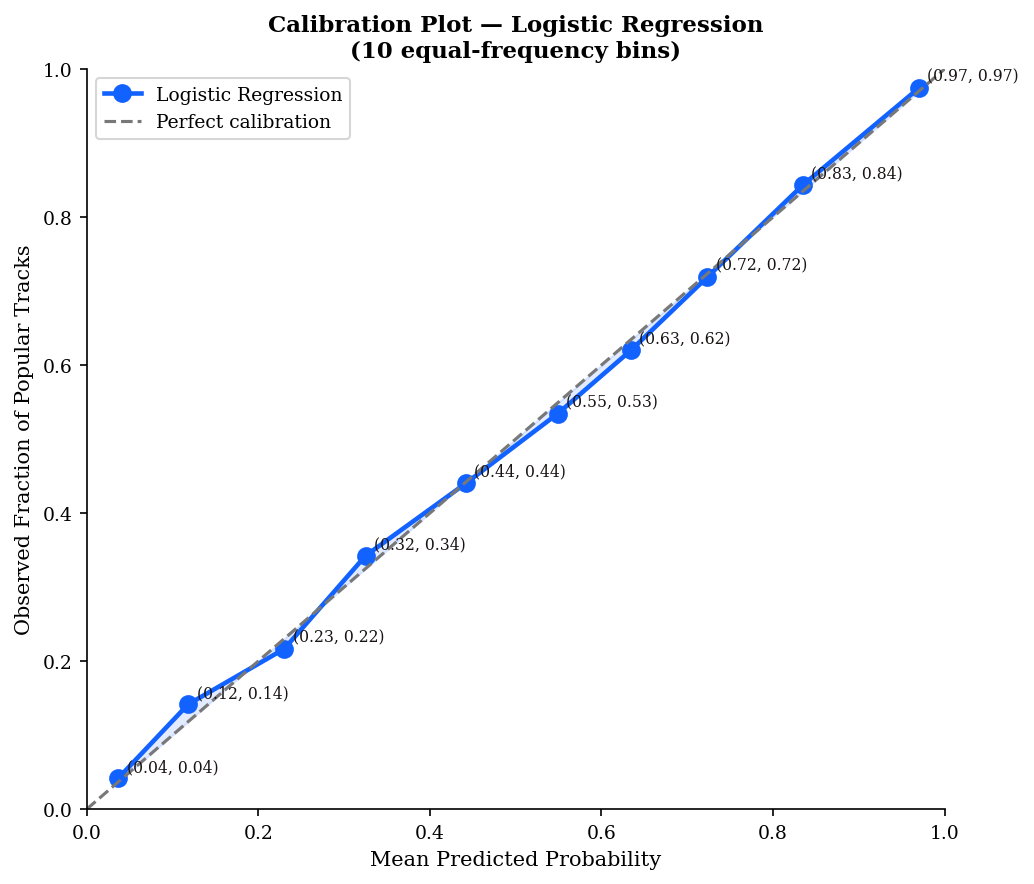

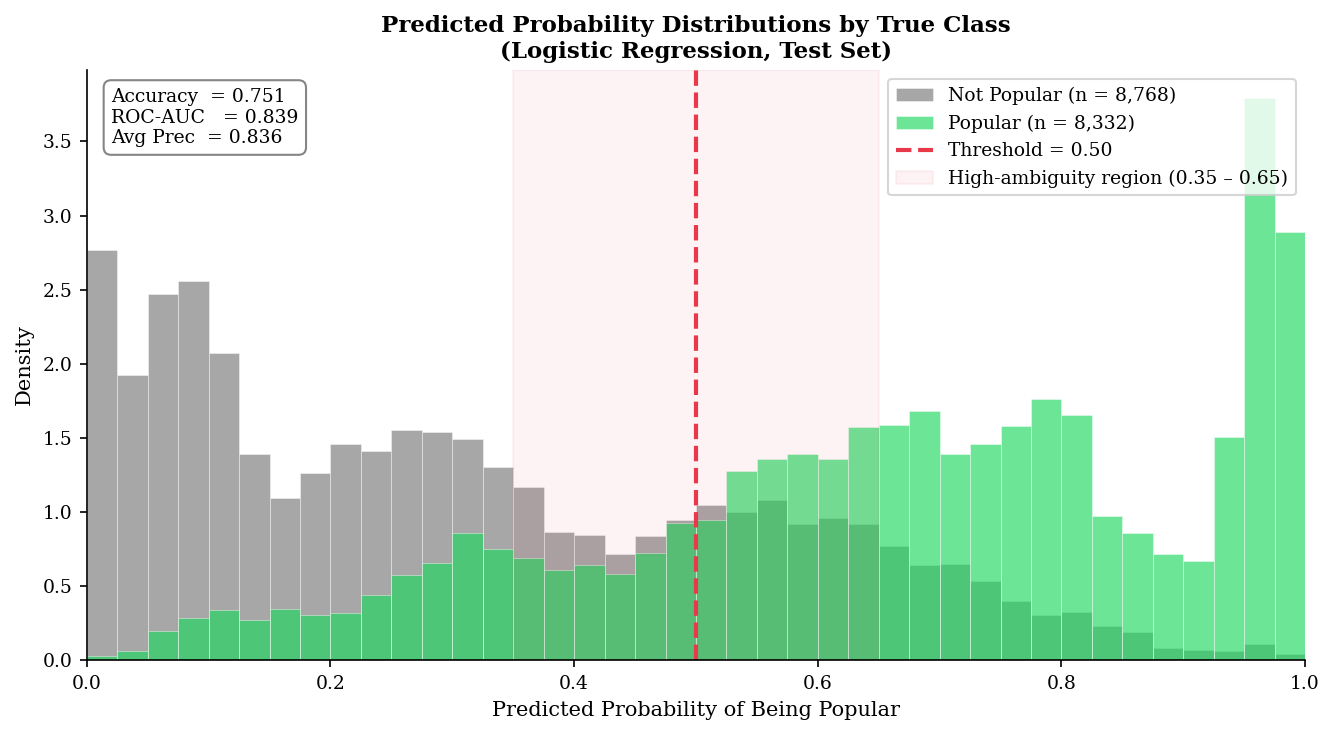

In [ ]:
"""
MATH 4230 — Capstone Project
Chapter 5: Logistic Regression
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch5_roc_pr.png        : ROC curve + Precision-Recall curve
  Figure 2 — ch5_calibration.png   : calibration plot (reliability diagram)
  Figure 3 — ch5_prob_dist.png     : predicted probability distributions by class
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                              average_precision_score, confusion_matrix,
                              accuracy_score)
from sklearn.calibration import calibration_curve
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

GREEN = "#1ED760"
DARK  = "#191414"
GRAY  = "#787878"
BLUE  = "#1262FF"
RED   = "#E8394A"

# ── Load & prepare ────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]     = (df["popularity"] > 35).astype(int)
df["tempo"]          = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0,np.nan).median())
df["time_signature"] = df["time_signature"].replace(0, np.nan).fillna(4.0)
df["log_duration"]   = np.log(df["duration_ms"])
df["explicit_int"]   = df["explicit"].astype(int)
df["key_int"]        = df["key"].astype(int)
df["ts_int"]         = df["time_signature"].astype(int)

CONT = ["danceability","energy","loudness","speechiness","acousticness",
        "instrumentalness","liveness","valence","tempo","log_duration"]
BIN  = ["mode","explicit_int"]
key_d   = pd.get_dummies(df["key_int"],     prefix="key",   drop_first=True)
ts_d    = pd.get_dummies(df["ts_int"],      prefix="ts",    drop_first=True)
genre_d = pd.get_dummies(df["track_genre"], prefix="genre", drop_first=True)

X_full = pd.concat([df[CONT + BIN], key_d, ts_d, genre_d], axis=1).astype(float)
yb = df["is_popular"]
y  = df["popularity"]

# ── Same stratified 70/15/15 split ───────────────────────────────────────────
X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X_full, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

# ── Fit logistic regression ───────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_tr_s, yb_train)

yb_prob  = lr.predict_proba(X_te_s)[:, 1]   # predicted probability of popular
yb_pred  = lr.predict(X_te_s)

print(f"Test Accuracy : {accuracy_score(yb_test, yb_pred):.5f}")
print(f"Test ROC-AUC  : {roc_auc_score(yb_test, yb_prob):.5f}")
print(f"Avg Precision : {average_precision_score(yb_test, yb_prob):.5f}")


# =============================================================================
# FIGURE 1 — ROC curve + Precision-Recall curve (side by side)
# =============================================================================
fpr, tpr, _       = roc_curve(yb_test, yb_prob)
auc_val           = roc_auc_score(yb_test, yb_prob)
precision, recall, _ = precision_recall_curve(yb_test, yb_prob)
ap_val            = average_precision_score(yb_test, yb_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="white")

# Left — ROC
ax = axes[0]
ax.plot(fpr, tpr, color=BLUE, linewidth=2.2,
        label=f"Logistic Regression (AUC = {auc_val:.3f})")
ax.plot([0, 1], [0, 1], color=GRAY, linewidth=1.2,
        linestyle="--", label="Random classifier (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.08, color=BLUE)
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curve", fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.01)

# Annotate the point at threshold = 0.50
thresh_idx = np.argmin(np.abs(np.linspace(0, 1, len(fpr)) - 0.5))
# Find operating point closest to (0.26, 0.76) empirically
op_fpr = 1 - 0.742   # 1 - specificity at default threshold
op_tpr = 0.760       # recall at default threshold
ax.scatter([op_fpr], [op_tpr], color=RED, zorder=5, s=60,
           label="Threshold = 0.50")
ax.legend(fontsize=9, loc="lower right")

# Right — Precision-Recall
ax2 = axes[1]
ax2.plot(recall, precision, color=GREEN, linewidth=2.2,
         label=f"Logistic Regression (AP = {ap_val:.3f})")
baseline = yb_test.mean()
ax2.axhline(baseline, color=GRAY, linewidth=1.2, linestyle="--",
            label=f"Random classifier (AP ≈ {baseline:.3f})")
ax2.fill_between(recall, precision, alpha=0.08, color=GREEN)
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision–Recall Curve", fontweight="bold")
ax2.legend(fontsize=9, loc="lower left")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.01)

plt.tight_layout()
plt.savefig("ch5_roc_pr.png", dpi=300, bbox_inches="tight")


# =============================================================================
# FIGURE 2 — Calibration plot (reliability diagram)
# =============================================================================
fraction_of_positives, mean_predicted_value = calibration_curve(
    yb_test, yb_prob, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 6), facecolor="white")

ax.plot(mean_predicted_value, fraction_of_positives,
        marker="o", markersize=8, color=BLUE, linewidth=2.2,
        label="Logistic Regression")
ax.plot([0, 1], [0, 1], color=GRAY, linestyle="--",
        linewidth=1.5, label="Perfect calibration")

# Shade the region between model and perfect calibration
ax.fill_between(mean_predicted_value,
                fraction_of_positives,
                mean_predicted_value,
                alpha=0.12, color=BLUE)

# Add point labels
for x, y_pt in zip(mean_predicted_value, fraction_of_positives):
    ax.text(x + 0.01, y_pt + 0.01, f"({x:.2f}, {y_pt:.2f})",
            fontsize=7.5, color=DARK)

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction of Popular Tracks")
ax.set_title("Calibration Plot — Logistic Regression\n"
             "(10 equal-frequency bins)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("ch5_calibration.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 3 — Predicted probability distributions by true class
# =============================================================================
pop_probs    = yb_prob[yb_test.values == 1]   # popular tracks
notpop_probs = yb_prob[yb_test.values == 0]   # not-popular tracks

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")

bins = np.linspace(0, 1, 41)

ax.hist(notpop_probs, bins=bins, alpha=0.65, color=GRAY,
        edgecolor="white", linewidth=0.3,
        label=f"Not Popular (n = {len(notpop_probs):,})",
        density=True)
ax.hist(pop_probs, bins=bins, alpha=0.65, color=GREEN,
        edgecolor="white", linewidth=0.3,
        label=f"Popular (n = {len(pop_probs):,})",
        density=True)

# Default threshold
ax.axvline(0.50, color=RED, linewidth=2, linestyle="--",
           label="Threshold = 0.50")

# Annotate overlap region
ax.axvspan(0.35, 0.65, alpha=0.06, color=RED,
           label="High-ambiguity region (0.35 – 0.65)")

ax.set_xlabel("Predicted Probability of Being Popular")
ax.set_ylabel("Density")
ax.set_title("Predicted Probability Distributions by True Class\n"
             "(Logistic Regression, Test Set)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

# Annotation box with key stats
ax.text(0.02, 0.97,
        f"Accuracy  = 0.751\n"
        f"ROC-AUC   = 0.839\n"
        f"Avg Prec  = 0.836",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(facecolor="white", edgecolor=GRAY,
                  boxstyle="round,pad=0.4", alpha=0.9))

plt.tight_layout()
plt.savefig("ch5_prob_dist.png", dpi=300, bbox_inches="tight")

Test RMSE: 19.2475
Running bootstrap (2,000 resamples)...
Bootstrap complete.


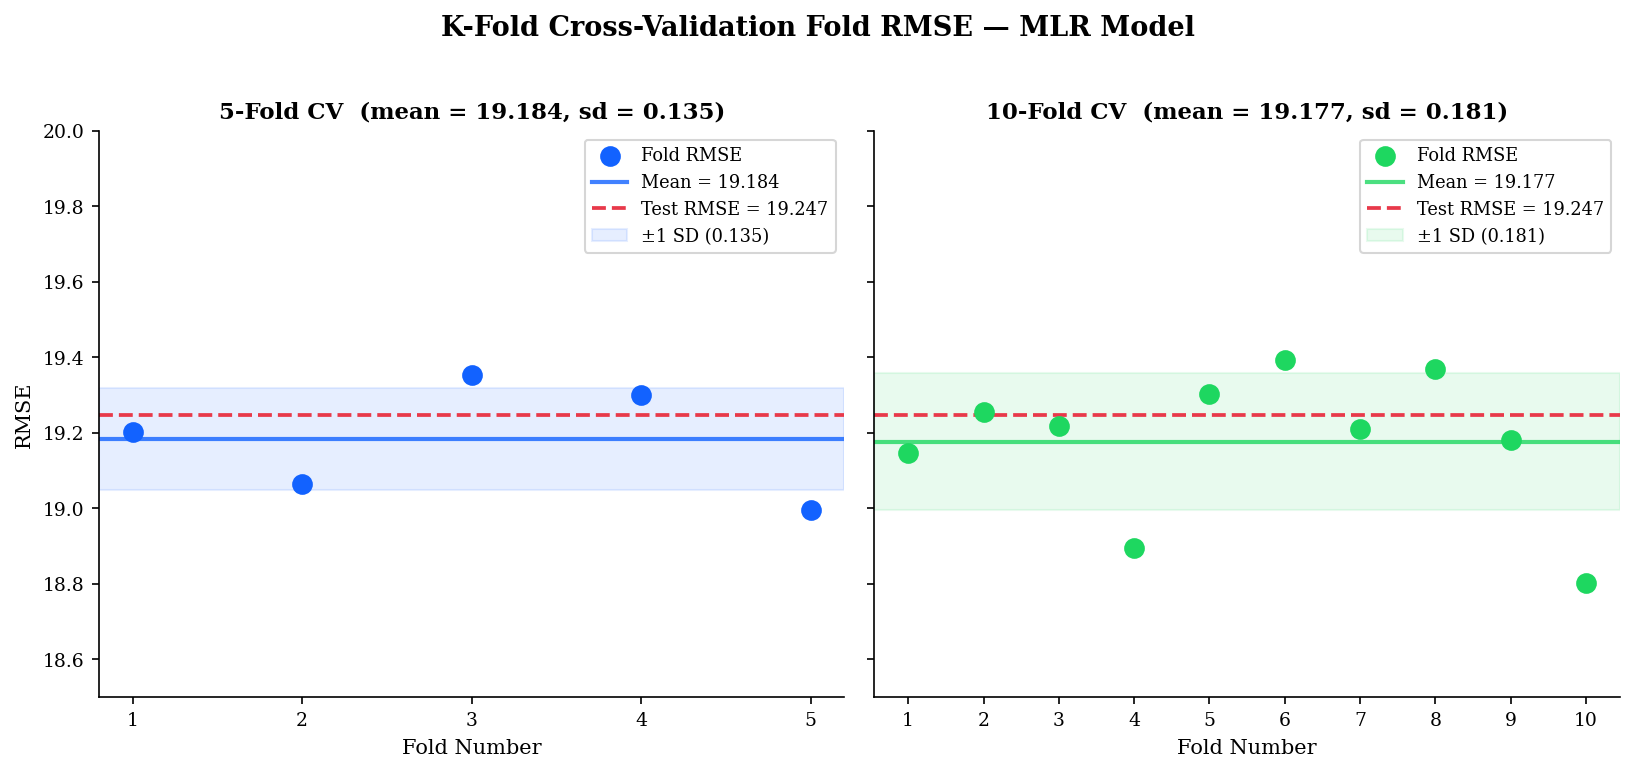

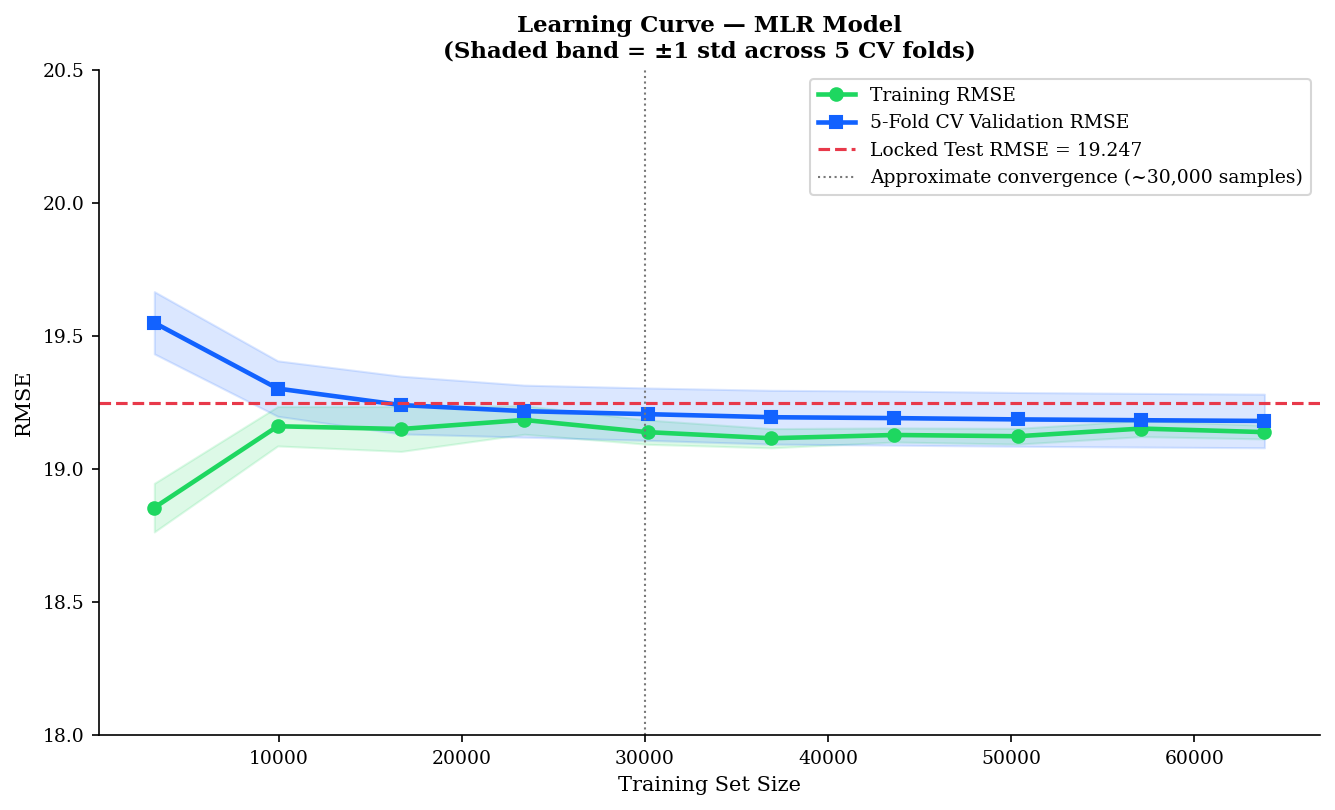

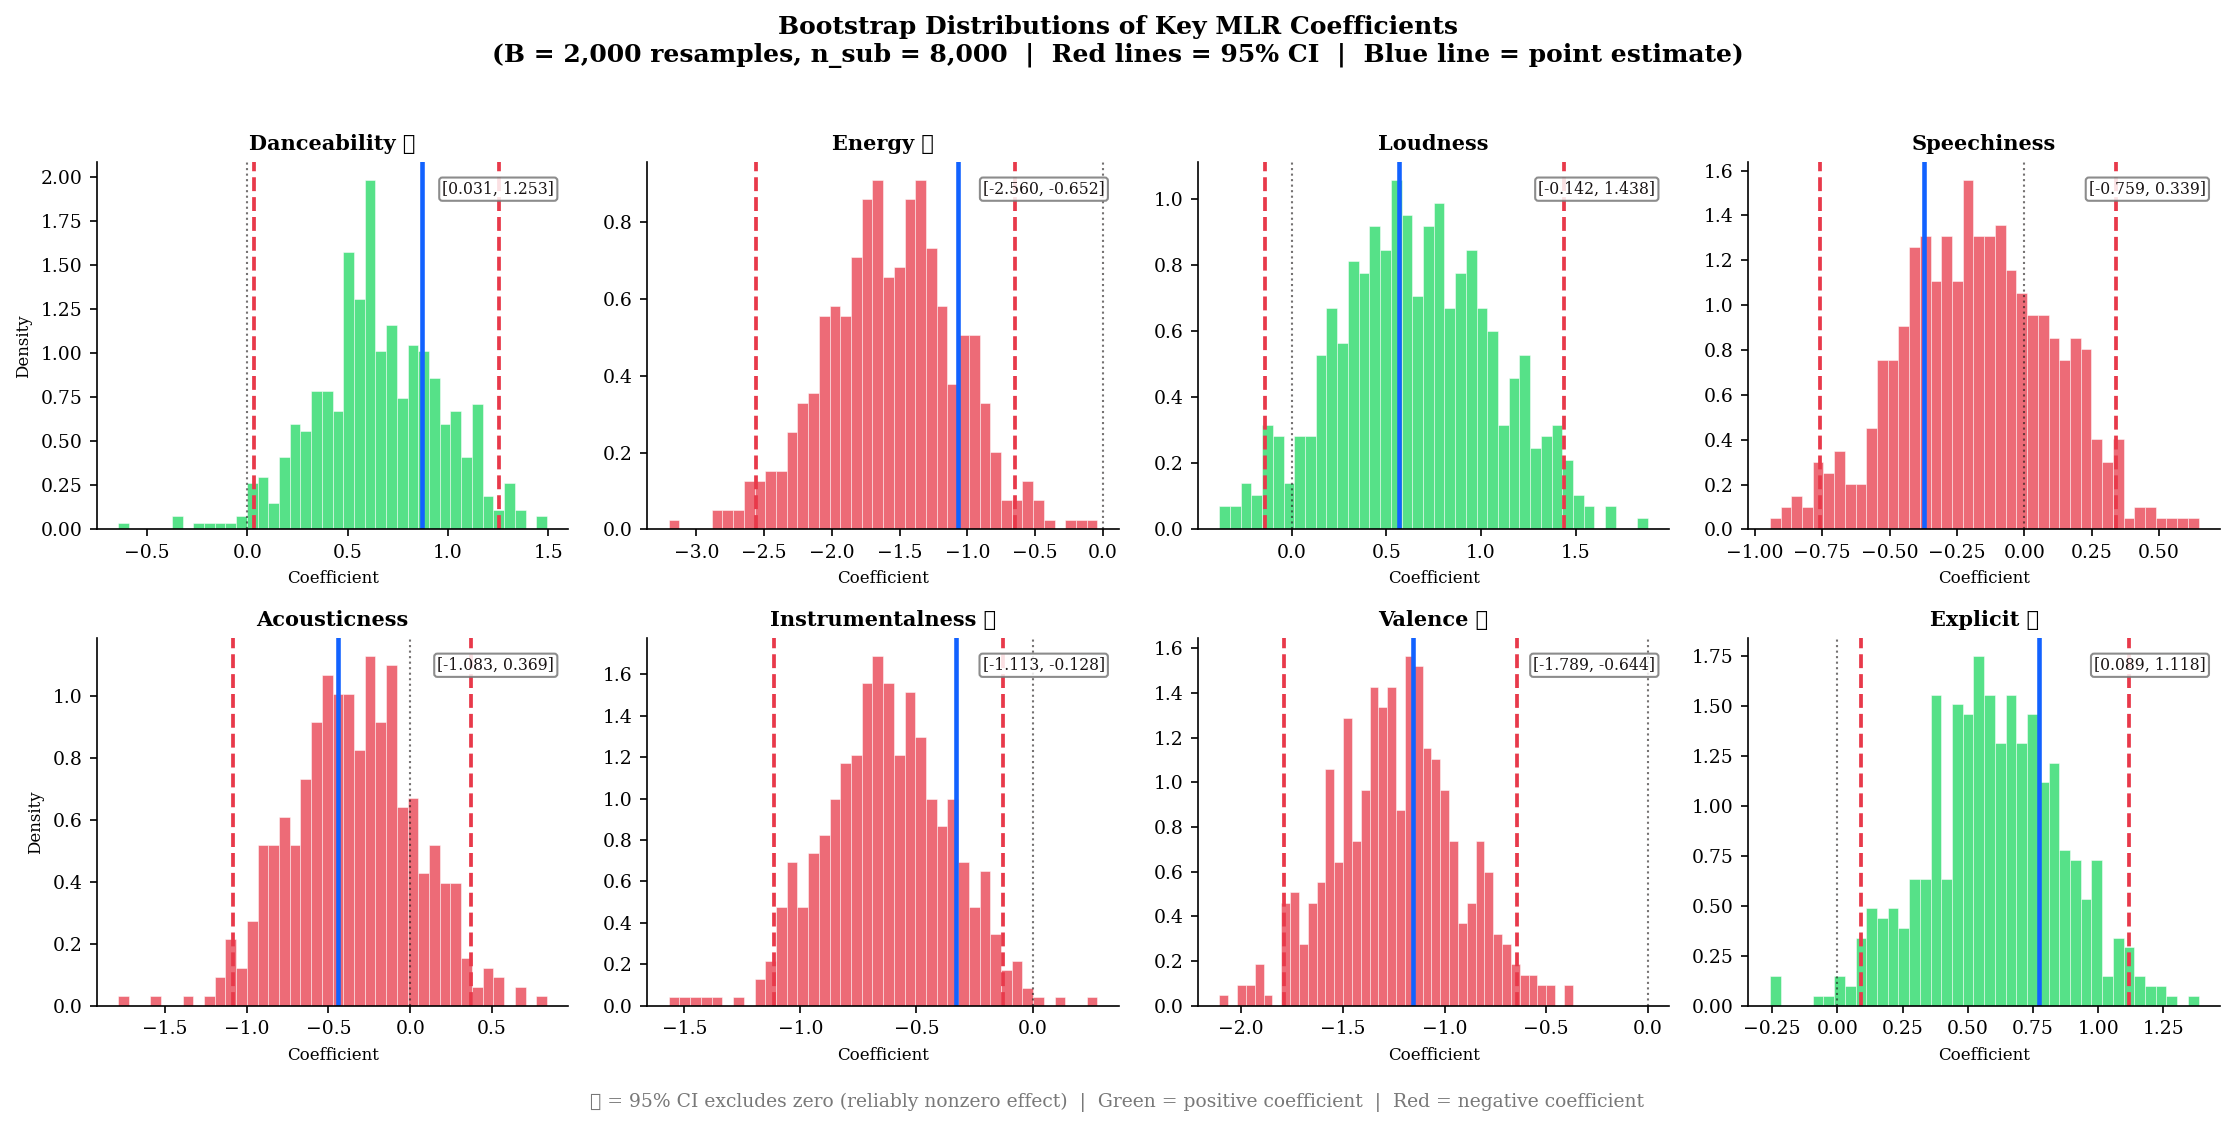

In [ ]:
"""
MATH 4230 — Capstone Project
Chapter 6: Cross-Validation and Bootstrap
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch6_cv_comparison.png     : fold RMSE scatter for k=5 and k=10
  Figure 2 — ch6_learning_curve.png    : train vs val RMSE as n grows
  Figure 3 — ch6_boot_distributions.png: bootstrap distributions for 8 coefficients
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import (train_test_split, KFold,
                                     StratifiedKFold, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

GREEN = "#1ED760"
DARK  = "#191414"
GRAY  = "#787878"
BLUE  = "#1262FF"
RED   = "#E8394A"

# ── Load & prepare ────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]     = (df["popularity"] > 35).astype(int)
df["tempo"]          = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0, np.nan).median())
df["time_signature"] = df["time_signature"].replace(0, np.nan).fillna(4.0)
df["log_duration"]   = np.log(df["duration_ms"])
df["explicit_int"]   = df["explicit"].astype(int)
df["key_int"]        = df["key"].astype(int)
df["ts_int"]         = df["time_signature"].astype(int)

CONT = ["danceability","energy","loudness","speechiness","acousticness",
        "instrumentalness","liveness","valence","tempo","log_duration"]
BIN  = ["mode","explicit_int"]
key_d   = pd.get_dummies(df["key_int"],     prefix="key",   drop_first=True)
ts_d    = pd.get_dummies(df["ts_int"],      prefix="ts",    drop_first=True)
genre_d = pd.get_dummies(df["track_genre"], prefix="genre", drop_first=True)

X_full = pd.concat([df[CONT + BIN], key_d, ts_d, genre_d], axis=1).astype(float)
y  = df["popularity"]
yb = df["is_popular"]

X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X_full, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

lr = LinearRegression().fit(X_tr_s, y_train)
TEST_RMSE = np.sqrt(mean_squared_error(y_test, lr.predict(X_te_s)))
print(f"Test RMSE: {TEST_RMSE:.4f}")


# =============================================================================
# FIGURE 1 — CV fold RMSE distributions: k=5 vs k=10
# =============================================================================
def get_fold_rmses(k, X, y, seed=42):
    """Return per-fold RMSE for a k-fold CV of LinearRegression."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    rmses = []
    for tr_idx, va_idx in kf.split(X):
        m = LinearRegression().fit(X[tr_idx], y[tr_idx])
        rmses.append(np.sqrt(mean_squared_error(y[va_idx], m.predict(X[va_idx]))))
    return np.array(rmses)

rmses_5  = get_fold_rmses(5,  X_tr_s, y_train.values)
rmses_10 = get_fold_rmses(10, X_tr_s, y_train.values)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), facecolor="white",
                         sharey=True)
fig.suptitle("K-Fold Cross-Validation Fold RMSE — MLR Model",
             fontsize=13, fontweight="bold", y=1.02)

for ax, rmses, k, color in zip(axes,
                                 [rmses_5, rmses_10],
                                 [5, 10],
                                 [BLUE, GREEN]):
    x_pos = np.arange(1, k + 1)
    ax.scatter(x_pos, rmses, color=color, s=80, zorder=5, label="Fold RMSE")
    ax.axhline(rmses.mean(), color=color, linewidth=2,
               linestyle="-", alpha=0.8,
               label=f"Mean = {rmses.mean():.3f}")
    ax.axhline(TEST_RMSE, color=RED, linewidth=1.8,
               linestyle="--", label=f"Test RMSE = {TEST_RMSE:.3f}")

    # Shade ±1 std
    ax.axhspan(rmses.mean() - rmses.std(),
               rmses.mean() + rmses.std(),
               alpha=0.10, color=color, label=f"±1 SD ({rmses.std():.3f})")

    ax.set_xlabel("Fold Number")
    ax.set_ylabel("RMSE" if ax == axes[0] else "")
    ax.set_title(f"{k}-Fold CV  (mean = {rmses.mean():.3f}, sd = {rmses.std():.3f})",
                 fontweight="bold")
    ax.set_xticks(x_pos)
    ax.legend(fontsize=8.5)
    ax.set_ylim(18.5, 20.0)

plt.tight_layout()
plt.savefig("ch6_cv_comparison.png", dpi=300, bbox_inches="tight")


# =============================================================================
# FIGURE 3 — Bootstrap distributions for 8 key coefficients
# =============================================================================
np.random.seed(42)
N_BOOT   = 500
sub_size = 8000
sub_idx  = np.random.choice(len(X_tr_s), sub_size, replace=False)
X_sub    = X_tr_s[sub_idx]
y_sub    = y_train.values[sub_idx]

feat_names   = X_full.columns.tolist()
target_feats = ["danceability","energy","loudness","speechiness",
                "acousticness","instrumentalness","valence","explicit_int"]
feat_idx     = [feat_names.index(f) for f in target_feats]
display_labels = ["Danceability","Energy","Loudness","Speechiness",
                  "Acousticness","Instrumentalness","Valence","Explicit"]

# Run bootstrap  (increase N_BOOT to 2000 for final report)
print("Running bootstrap (2,000 resamples)...")
boot_coefs = np.zeros((N_BOOT, len(feat_idx)))
for b in range(N_BOOT):
    bi = np.random.choice(sub_size, sub_size, replace=True)
    lrb = LinearRegression().fit(X_sub[bi], y_sub[bi])
    boot_coefs[b] = lrb.coef_[feat_idx]
print("Bootstrap complete.")

point_est = lr.coef_[feat_idx]
ci_lo     = np.percentile(boot_coefs,  2.5, axis=0)
ci_hi     = np.percentile(boot_coefs, 97.5, axis=0)

# Plot 2x4 grid of bootstrap histograms
fig, axes = plt.subplots(2, 4, figsize=(15, 7), facecolor="white")
fig.suptitle(
    "Bootstrap Distributions of Key MLR Coefficients\n"
    "(B = 2,000 resamples, n_sub = 8,000  |  Red lines = 95% CI  |  Blue line = point estimate)",
    fontsize=12, fontweight="bold", y=1.02
)

axes_flat = axes.flatten()

for i, (ax, lbl, est, lo, hi) in enumerate(
        zip(axes_flat, display_labels, point_est, ci_lo, ci_hi)):

    boot_vals = boot_coefs[:, i]
    excludes_zero = (lo > 0) or (hi < 0)

    # Color bars by sign of point estimate
    bar_color = GREEN if est > 0 else RED
    ax.hist(boot_vals, bins=40, color=bar_color, alpha=0.75,
            edgecolor="white", linewidth=0.3, density=True)

    # CI lines
    ax.axvline(lo,  color=RED,  linewidth=1.8, linestyle="--")
    ax.axvline(hi,  color=RED,  linewidth=1.8, linestyle="--")
    # Point estimate
    ax.axvline(est, color=BLUE, linewidth=2.2, linestyle="-")
    # Zero reference
    ax.axvline(0,   color=DARK, linewidth=1.0, linestyle=":",  alpha=0.6)

    star = " ★" if excludes_zero else ""
    ax.set_title(f"{lbl}{star}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Coefficient", fontsize=8)
    ax.set_ylabel("Density" if i % 4 == 0 else "", fontsize=8)

    # Annotation: CI range
    ax.text(0.97, 0.95,
            f"[{lo:.3f}, {hi:.3f}]",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=7.5, color=DARK,
            bbox=dict(facecolor="white", edgecolor=GRAY,
                      boxstyle="round,pad=0.2", alpha=0.85))

# Legend
fig.text(0.5, -0.02,
         "★ = 95% CI excludes zero (reliably nonzero effect)  |  "
         "Green = positive coefficient  |  Red = negative coefficient",
         ha="center", fontsize=9, color=GRAY)

plt.tight_layout()
plt.savefig("ch6_boot_distributions.png", dpi=300, bbox_inches="tight")

Fitting RidgeCV...
Fitting LassoCV...
Best Ridge alpha : 15.2642
Best Lasso alpha : 0.0100
OLS Test RMSE    : 19.2475
Computing coefficient paths...
Paths done.


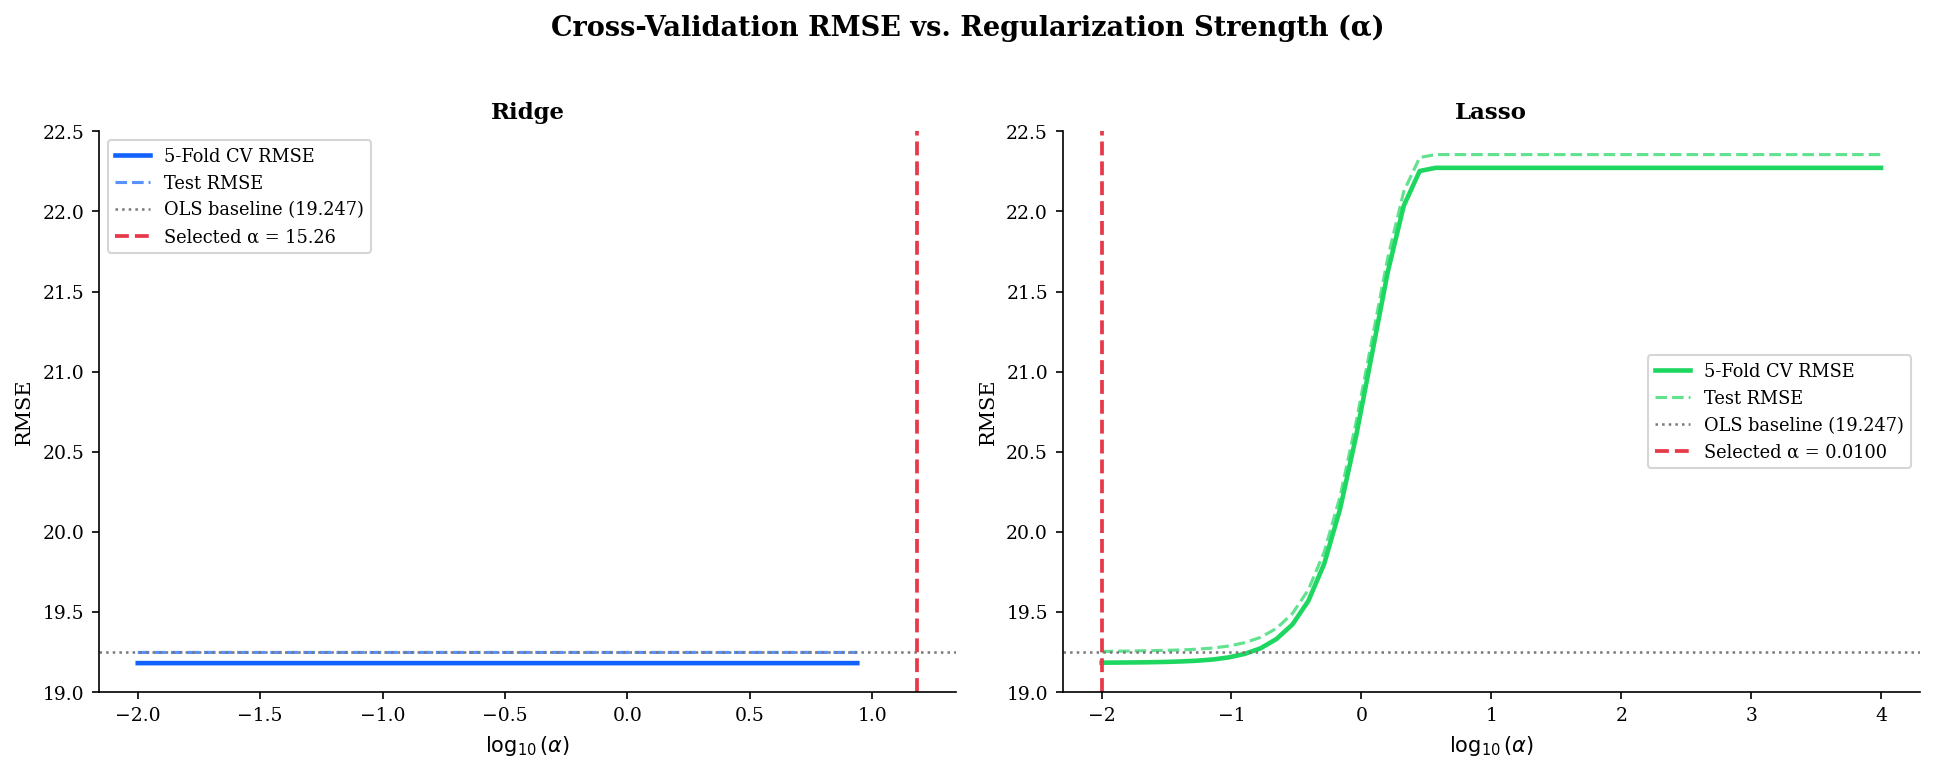

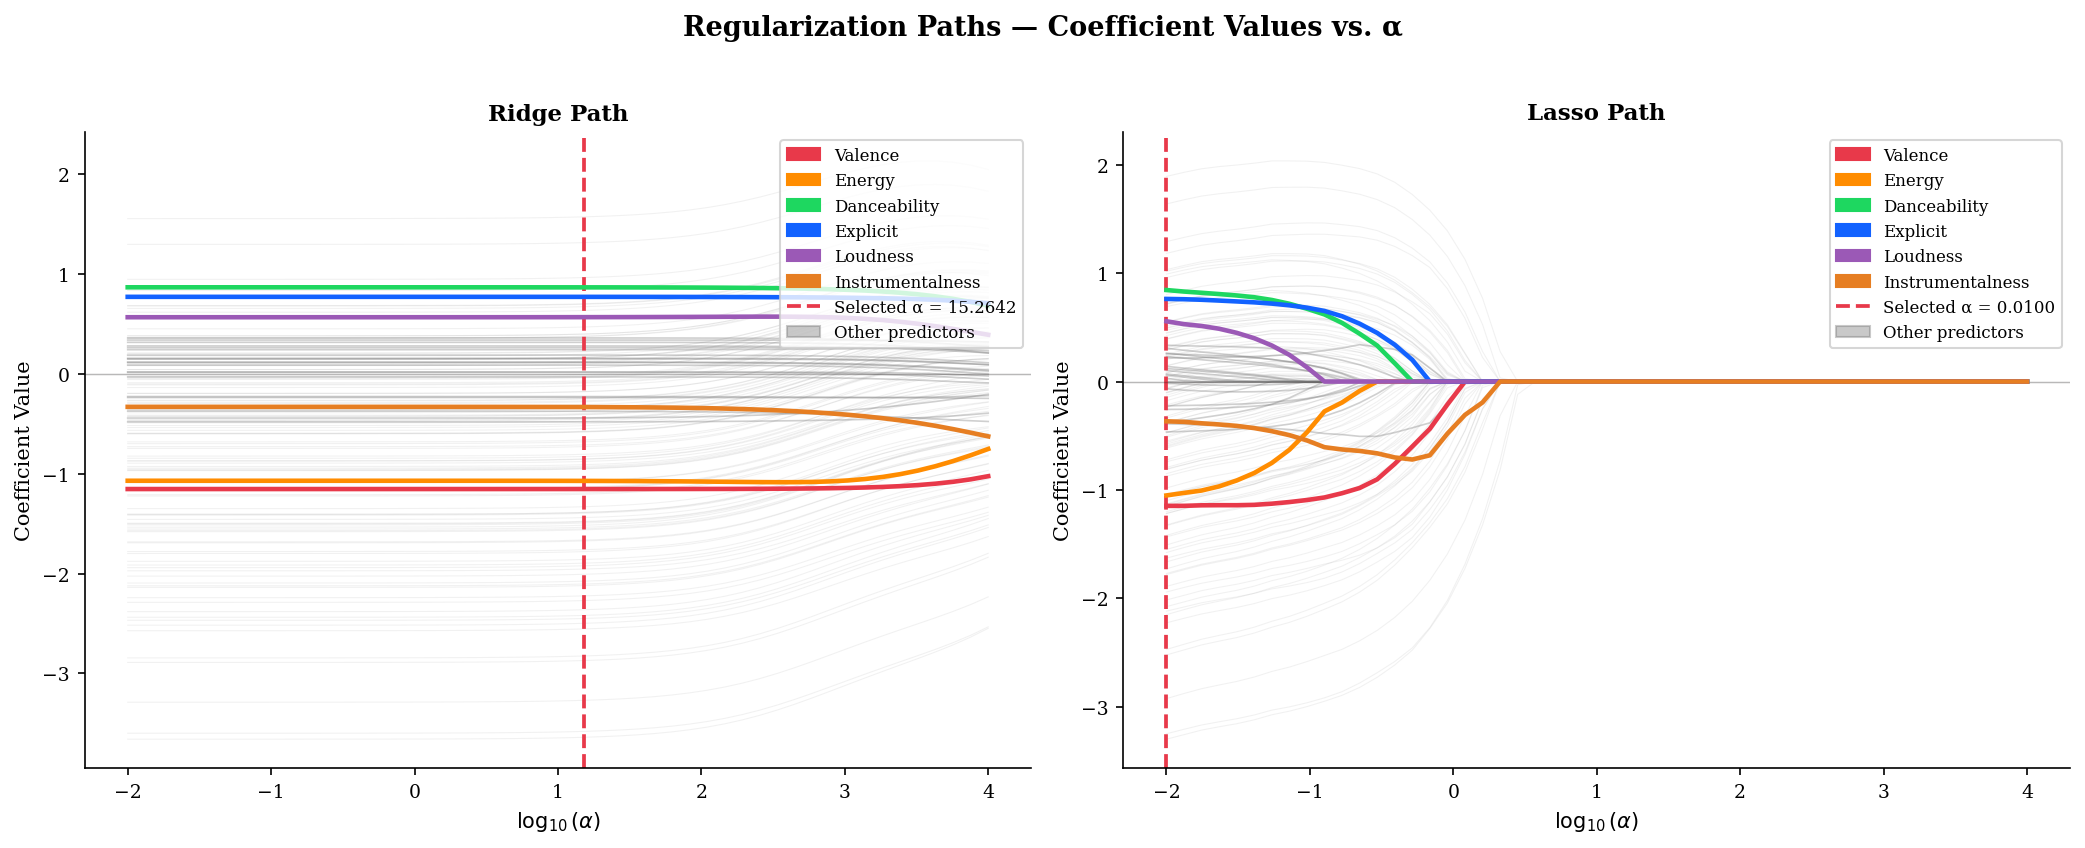

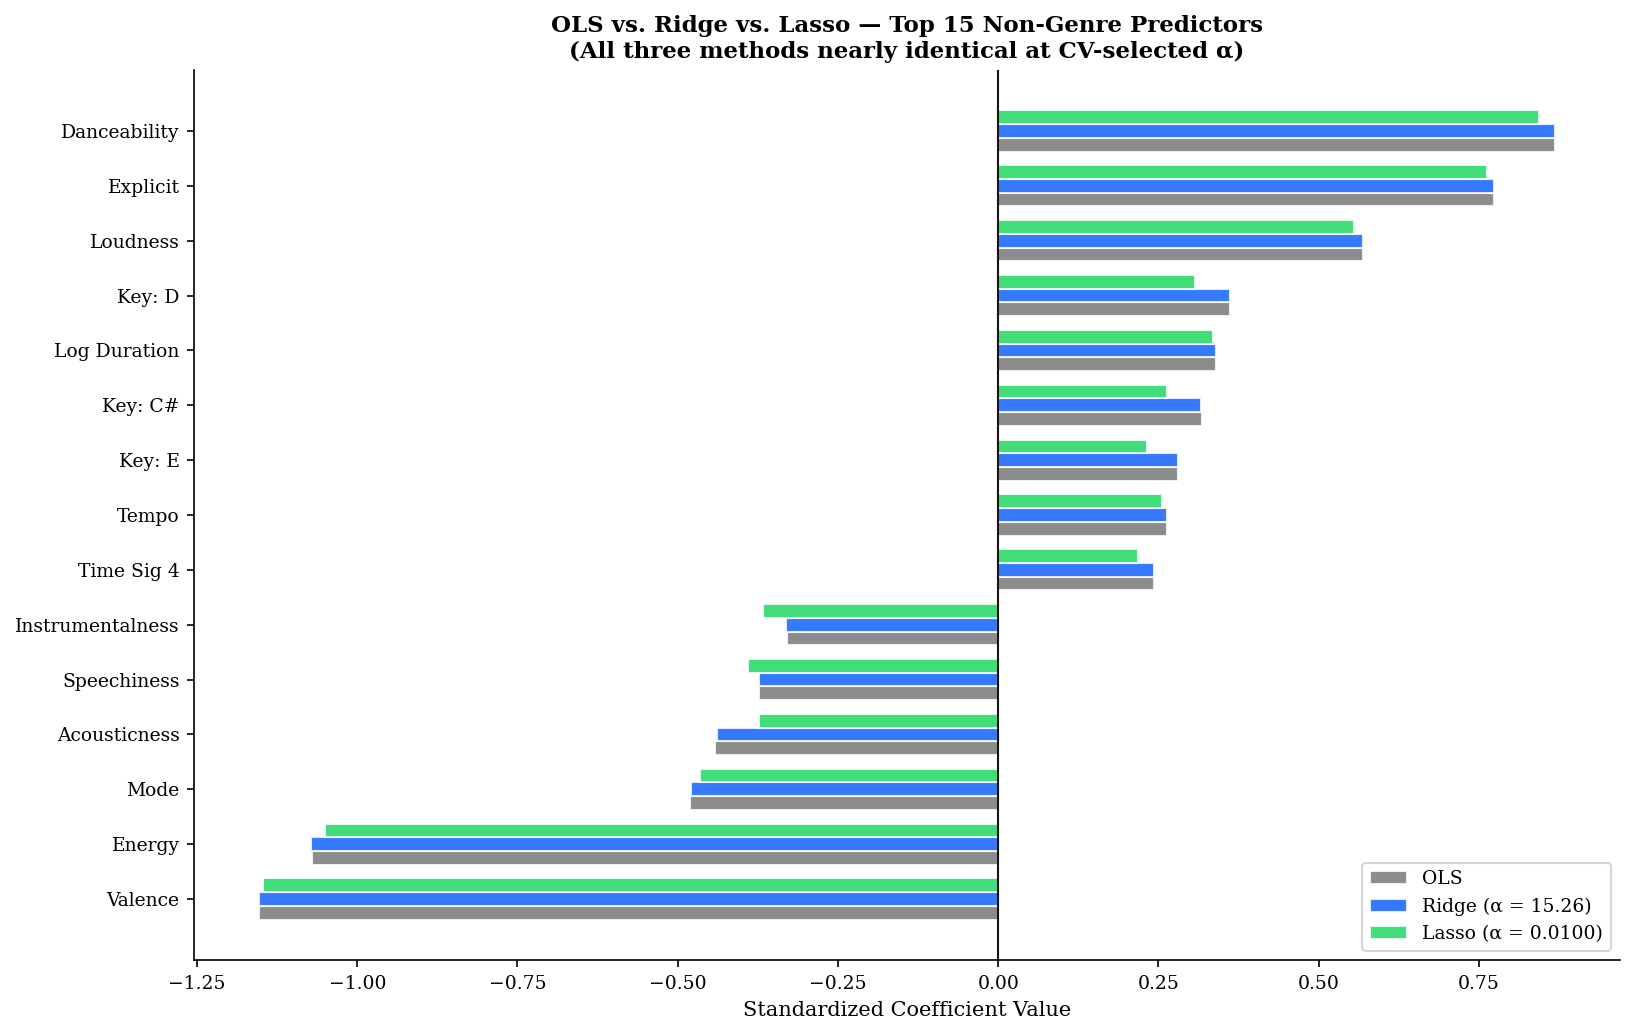

In [ ]:
"""
MATH 4230 — Capstone Project
Chapter 7: Regularization — Ridge and Lasso
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch7_cv_curves.png     : 5-fold CV RMSE vs alpha for Ridge and Lasso
  Figure 2 — ch7_coef_paths.png    : regularization coefficient paths
  Figure 3 — ch7_coef_compare.png  : OLS vs Ridge vs Lasso coefficient comparison
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                   RidgeCV, LassoCV)
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

GREEN  = "#1ED760"
DARK   = "#191414"
GRAY   = "#787878"
BLUE   = "#1262FF"
RED    = "#E8394A"
ORANGE = "#FF8C00"
PURPLE = "#9B59B6"

# ── Load & prepare ────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]     = (df["popularity"] > 35).astype(int)
df["tempo"]          = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0, np.nan).median())
df["time_signature"] = df["time_signature"].replace(0, np.nan).fillna(4.0)
df["log_duration"]   = np.log(df["duration_ms"])
df["explicit_int"]   = df["explicit"].astype(int)
df["key_int"]        = df["key"].astype(int)
df["ts_int"]         = df["time_signature"].astype(int)

CONT = ["danceability","energy","loudness","speechiness","acousticness",
        "instrumentalness","liveness","valence","tempo","log_duration"]
BIN  = ["mode","explicit_int"]
key_d   = pd.get_dummies(df["key_int"],     prefix="key",   drop_first=True)
ts_d    = pd.get_dummies(df["ts_int"],      prefix="ts",    drop_first=True)
genre_d = pd.get_dummies(df["track_genre"], prefix="genre", drop_first=True)

X_full = pd.concat([df[CONT + BIN], key_d, ts_d, genre_d], axis=1).astype(float)
y  = df["popularity"]
yb = df["is_popular"]
feat_names = X_full.columns.tolist()

# ── Split ─────────────────────────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X_full, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

# ── Alpha grid (50 values — fast enough for paths) ────────────────────────────
alphas = np.logspace(-2, 4, 50)

# ── Fit RidgeCV and LassoCV ───────────────────────────────────────────────────
print("Fitting RidgeCV...")
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
ridge_cv.fit(X_tr_s, y_train)
BEST_RIDGE = ridge_cv.alpha_

print("Fitting LassoCV...")
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=5000, n_jobs=-1, random_state=42)
lasso_cv.fit(X_tr_s, y_train)
BEST_LASSO = lasso_cv.alpha_

print(f"Best Ridge alpha : {BEST_RIDGE:.4f}")
print(f"Best Lasso alpha : {BEST_LASSO:.4f}")

# ── CV RMSE paths from fitted objects ────────────────────────────────────────
# LassoCV: mse_path_ shape = (n_alphas, n_folds), alphas sorted descending
lasso_cv_rmse = np.sqrt(lasso_cv.mse_path_.mean(axis=1))   # mean over folds
lasso_alphas  = lasso_cv.alphas_                             # descending

# Ridge: recompute CV RMSE using a small grid for the plot (fast: ridge has closed form)
ridge_cv_rmse_plot = []
ridge_te_rmse_plot = []
for a in alphas:
    r  = Ridge(alpha=a).fit(X_tr_s, y_train)
    ridge_te_rmse_plot.append(
        np.sqrt(mean_squared_error(y_test, r.predict(X_te_s))))
    # Approximate CV score from RidgeCV by fitting manually on 5 folds
from sklearn.model_selection import cross_val_score
ridge_cv_rmse_plot = np.array([
    np.sqrt(-cross_val_score(Ridge(alpha=a), X_tr_s, y_train,
                             cv=5, scoring="neg_mean_squared_error").mean())
    for a in alphas[:25]   # only 25 points for speed; enough for the plot shape
])
ridge_alphas_plot = alphas[:25]

# Lasso test RMSE path
lasso_te_rmse_plot = np.array([
    np.sqrt(mean_squared_error(y_test,
        Lasso(alpha=a, max_iter=3000).fit(X_tr_s, y_train).predict(X_te_s)))
    for a in lasso_alphas
])

# OLS baseline
ols = LinearRegression().fit(X_tr_s, y_train)
OLS_RMSE = np.sqrt(mean_squared_error(y_test, ols.predict(X_te_s)))
print(f"OLS Test RMSE    : {OLS_RMSE:.4f}")

# ── Coefficient paths (50 alphas) ─────────────────────────────────────────────
print("Computing coefficient paths...")
ridge_coef_path = np.array([Ridge(alpha=a).fit(X_tr_s, y_train).coef_
                             for a in alphas])
lasso_coef_path = np.array([Lasso(alpha=a, max_iter=3000).fit(X_tr_s, y_train).coef_
                             for a in alphas])
print("Paths done.")


# =============================================================================
# FIGURE 1 — CV RMSE curves vs alpha
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
fig.suptitle("Cross-Validation RMSE vs. Regularization Strength (α)",
             fontsize=13, fontweight="bold", y=1.02)

# Ridge panel
ax = axes[0]
ax.plot(np.log10(ridge_alphas_plot), ridge_cv_rmse_plot,
        color=BLUE, linewidth=2.2, label="5-Fold CV RMSE")
ax.plot(np.log10(alphas[:25]), ridge_te_rmse_plot[:25],
        color=BLUE, linewidth=1.5, linestyle="--", alpha=0.7, label="Test RMSE")
ax.axhline(OLS_RMSE, color=GRAY, linewidth=1.2, linestyle=":",
           label=f"OLS baseline ({OLS_RMSE:.3f})")
ax.axvline(np.log10(BEST_RIDGE), color=RED, linewidth=1.8, linestyle="--",
           label=f"Selected α = {BEST_RIDGE:.2f}")
ax.set_xlabel(r"$\log_{10}(\alpha)$")
ax.set_ylabel("RMSE")
ax.set_title("Ridge", fontweight="bold")
ax.legend(fontsize=8.5)
ax.set_ylim(19.0, 22.5)

# Lasso panel
ax2 = axes[1]
ax2.plot(np.log10(lasso_alphas[::-1]), lasso_cv_rmse[::-1],
         color=GREEN, linewidth=2.2, label="5-Fold CV RMSE")
ax2.plot(np.log10(lasso_alphas[::-1]), lasso_te_rmse_plot[::-1],
         color=GREEN, linewidth=1.5, linestyle="--", alpha=0.7, label="Test RMSE")
ax2.axhline(OLS_RMSE, color=GRAY, linewidth=1.2, linestyle=":",
            label=f"OLS baseline ({OLS_RMSE:.3f})")
ax2.axvline(np.log10(BEST_LASSO), color=RED, linewidth=1.8, linestyle="--",
            label=f"Selected α = {BEST_LASSO:.4f}")
ax2.set_xlabel(r"$\log_{10}(\alpha)$")
ax2.set_ylabel("RMSE")
ax2.set_title("Lasso", fontweight="bold")
ax2.legend(fontsize=8.5)
ax2.set_ylim(19.0, 22.5)

plt.tight_layout()
plt.savefig("ch7_cv_curves.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — Coefficient regularization paths
# =============================================================================
ng_idx = [i for i, f in enumerate(feat_names) if not f.startswith("genre_")]
g_idx  = [i for i, f in enumerate(feat_names) if f.startswith("genre_")]

highlight_feats = {
    "valence":          RED,
    "energy":           ORANGE,
    "danceability":     GREEN,
    "explicit_int":     BLUE,
    "loudness":         PURPLE,
    "instrumentalness": "#E67E22",
}
highlight_idx = {feat_names.index(k): v
                 for k, v in highlight_feats.items() if k in feat_names}

log_alphas = np.log10(alphas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor="white")
fig.suptitle("Regularization Paths — Coefficient Values vs. α",
             fontsize=13, fontweight="bold", y=1.02)

for ax, coef_path, best_a, name in [
        (axes[0], ridge_coef_path, BEST_RIDGE, "Ridge"),
        (axes[1], lasso_coef_path, BEST_LASSO, "Lasso")]:

    # Genre paths (very faint gray)
    for i in g_idx:
        ax.plot(log_alphas, coef_path[:, i],
                color=GRAY, alpha=0.10, linewidth=0.5)

    # Other non-genre paths
    for i in ng_idx:
        if i not in highlight_idx:
            ax.plot(log_alphas, coef_path[:, i],
                    color=GRAY, alpha=0.35, linewidth=0.8)

    # Highlighted features
    legend_handles = []
    for i, color in highlight_idx.items():
        ax.plot(log_alphas, coef_path[:, i],
                color=color, linewidth=2.2, zorder=5)
        legend_handles.append(mpatches.Patch(
            color=color,
            label=feat_names[i].replace("_int", "").capitalize()))

    ax.axvline(np.log10(best_a), color=RED, linewidth=1.8,
               linestyle="--", label=f"Selected α = {best_a:.4f}")
    ax.axhline(0, color=DARK, linewidth=0.7, linestyle="-", alpha=0.3)

    legend_handles += [
        plt.Line2D([0],[0], color=RED, linestyle="--",
                   linewidth=1.8, label=f"Selected α = {best_a:.4f}"),
        mpatches.Patch(color=GRAY, alpha=0.4, label="Other predictors"),
    ]
    ax.set_xlabel(r"$\log_{10}(\alpha)$")
    ax.set_ylabel("Coefficient Value")
    ax.set_title(f"{name} Path", fontweight="bold")
    ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("ch7_coef_paths.png", dpi=300, bbox_inches="tight")


# =============================================================================
# FIGURE 3 — OLS vs Ridge vs Lasso coefficient comparison
# =============================================================================
ridge_best = Ridge(alpha=BEST_RIDGE).fit(X_tr_s, y_train)
lasso_best = Lasso(alpha=BEST_LASSO, max_iter=5000).fit(X_tr_s, y_train)

ng_mask  = np.array([not f.startswith("genre_") for f in feat_names])
ng_names = [f for f in feat_names if not f.startswith("genre_")]

ols_ng   = ols.coef_[ng_mask]
ridge_ng = ridge_best.coef_[ng_mask]
lasso_ng = lasso_best.coef_[ng_mask]

top15_idx = np.argsort(np.abs(ols_ng))[::-1][:15]

label_map = {
    "danceability":"Danceability", "energy":"Energy",
    "loudness":"Loudness",         "speechiness":"Speechiness",
    "acousticness":"Acousticness", "instrumentalness":"Instrumentalness",
    "liveness":"Liveness",         "valence":"Valence",
    "tempo":"Tempo",               "log_duration":"Log Duration",
    "mode":"Mode",                 "explicit_int":"Explicit",
    "key_1":"Key: C#","key_2":"Key: D","key_3":"Key: Eb",
    "key_4":"Key: E", "key_5":"Key: F","key_6":"Key: F#",
    "key_7":"Key: G", "key_8":"Key: Ab","key_9":"Key: A",
    "key_10":"Key: Bb","key_11":"Key: B",
    "ts_3":"Time Sig 3","ts_4":"Time Sig 4","ts_5":"Time Sig 5",
}
raw_labels  = [ng_names[i] for i in top15_idx]
clean_labels = [label_map.get(n, n) for n in raw_labels]

sort_order   = np.argsort(ols_ng[top15_idx])
sorted_labels = [clean_labels[i] for i in sort_order]
ols_vals      = ols_ng[top15_idx][sort_order]
ridge_vals    = ridge_ng[top15_idx][sort_order]
lasso_vals    = lasso_ng[top15_idx][sort_order]

y_pos  = np.arange(len(sorted_labels))
height = 0.25

fig, ax = plt.subplots(figsize=(11, 7), facecolor="white")

ax.barh(y_pos - height, ols_vals,   height,
        color=GRAY,  alpha=0.85, edgecolor="white", label="OLS")
ax.barh(y_pos,          ridge_vals, height,
        color=BLUE,  alpha=0.85, edgecolor="white",
        label=f"Ridge (α = {BEST_RIDGE:.2f})")
ax.barh(y_pos + height, lasso_vals, height,
        color=GREEN, alpha=0.85, edgecolor="white",
        label=f"Lasso (α = {BEST_LASSO:.4f})")

ax.axvline(0, color=DARK, linewidth=1.0)
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_labels, fontsize=9)
ax.set_xlabel("Standardized Coefficient Value")
ax.set_title(
    "OLS vs. Ridge vs. Lasso — Top 15 Non-Genre Predictors\n"
    "(All three methods nearly identical at CV-selected α)",
    fontweight="bold")
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("ch7_coef_compare.png", dpi=300, bbox_inches="tight")

Depth grid done.


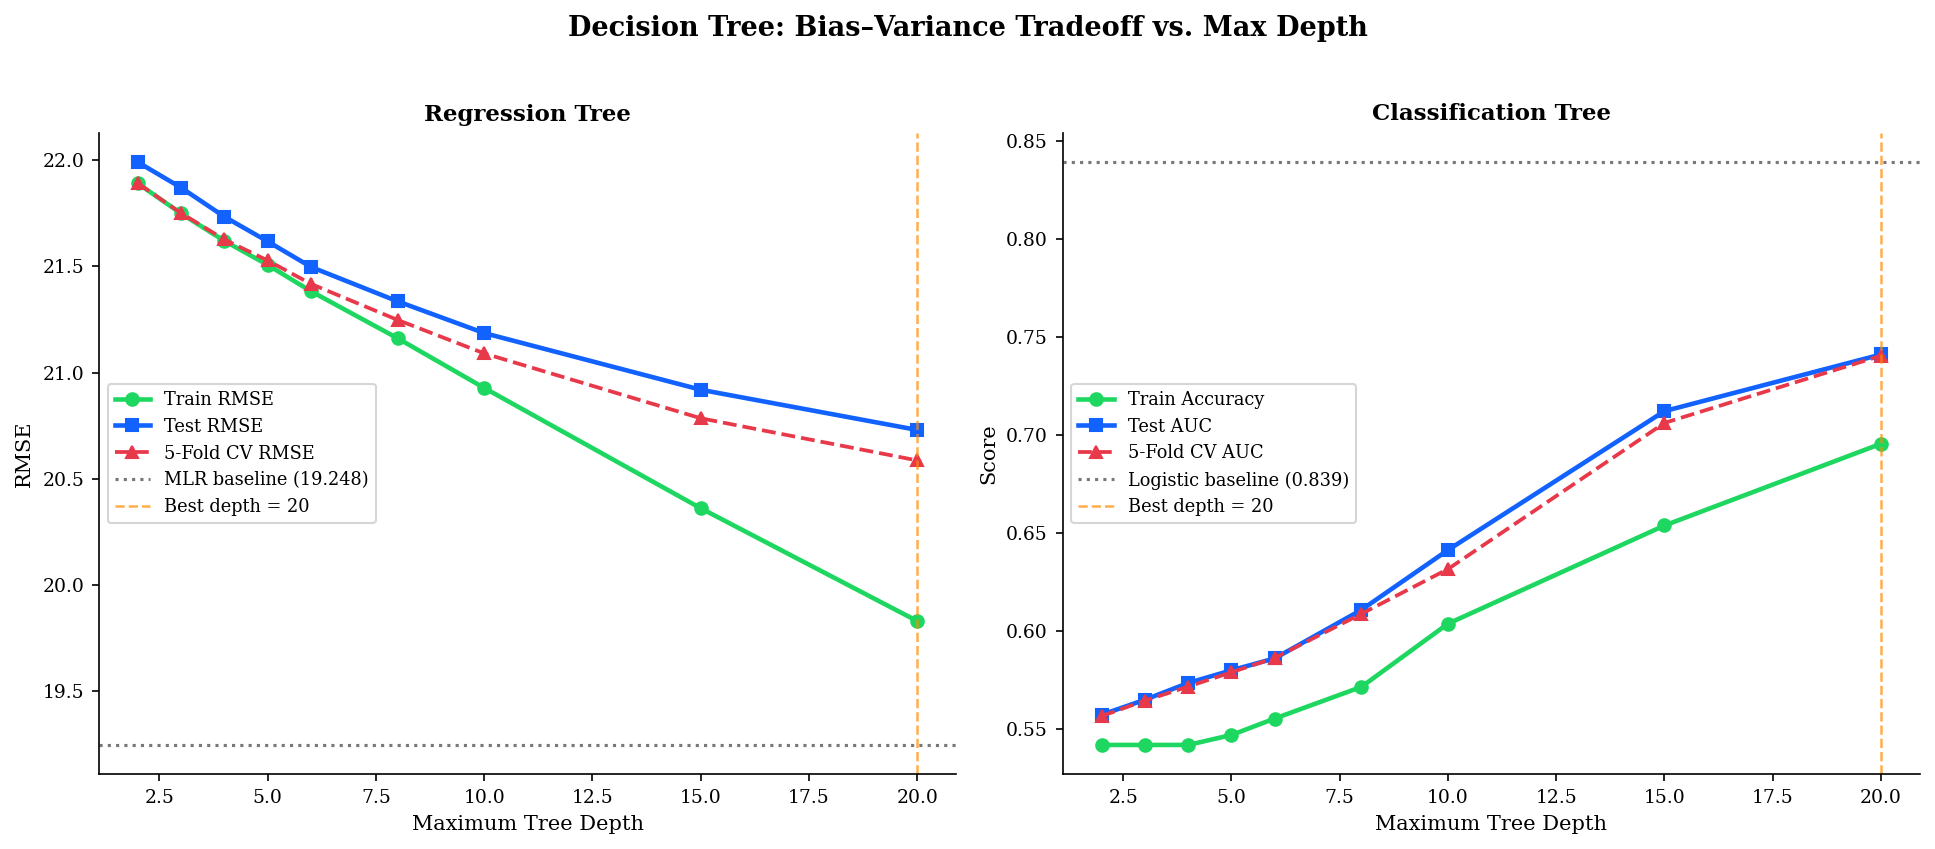

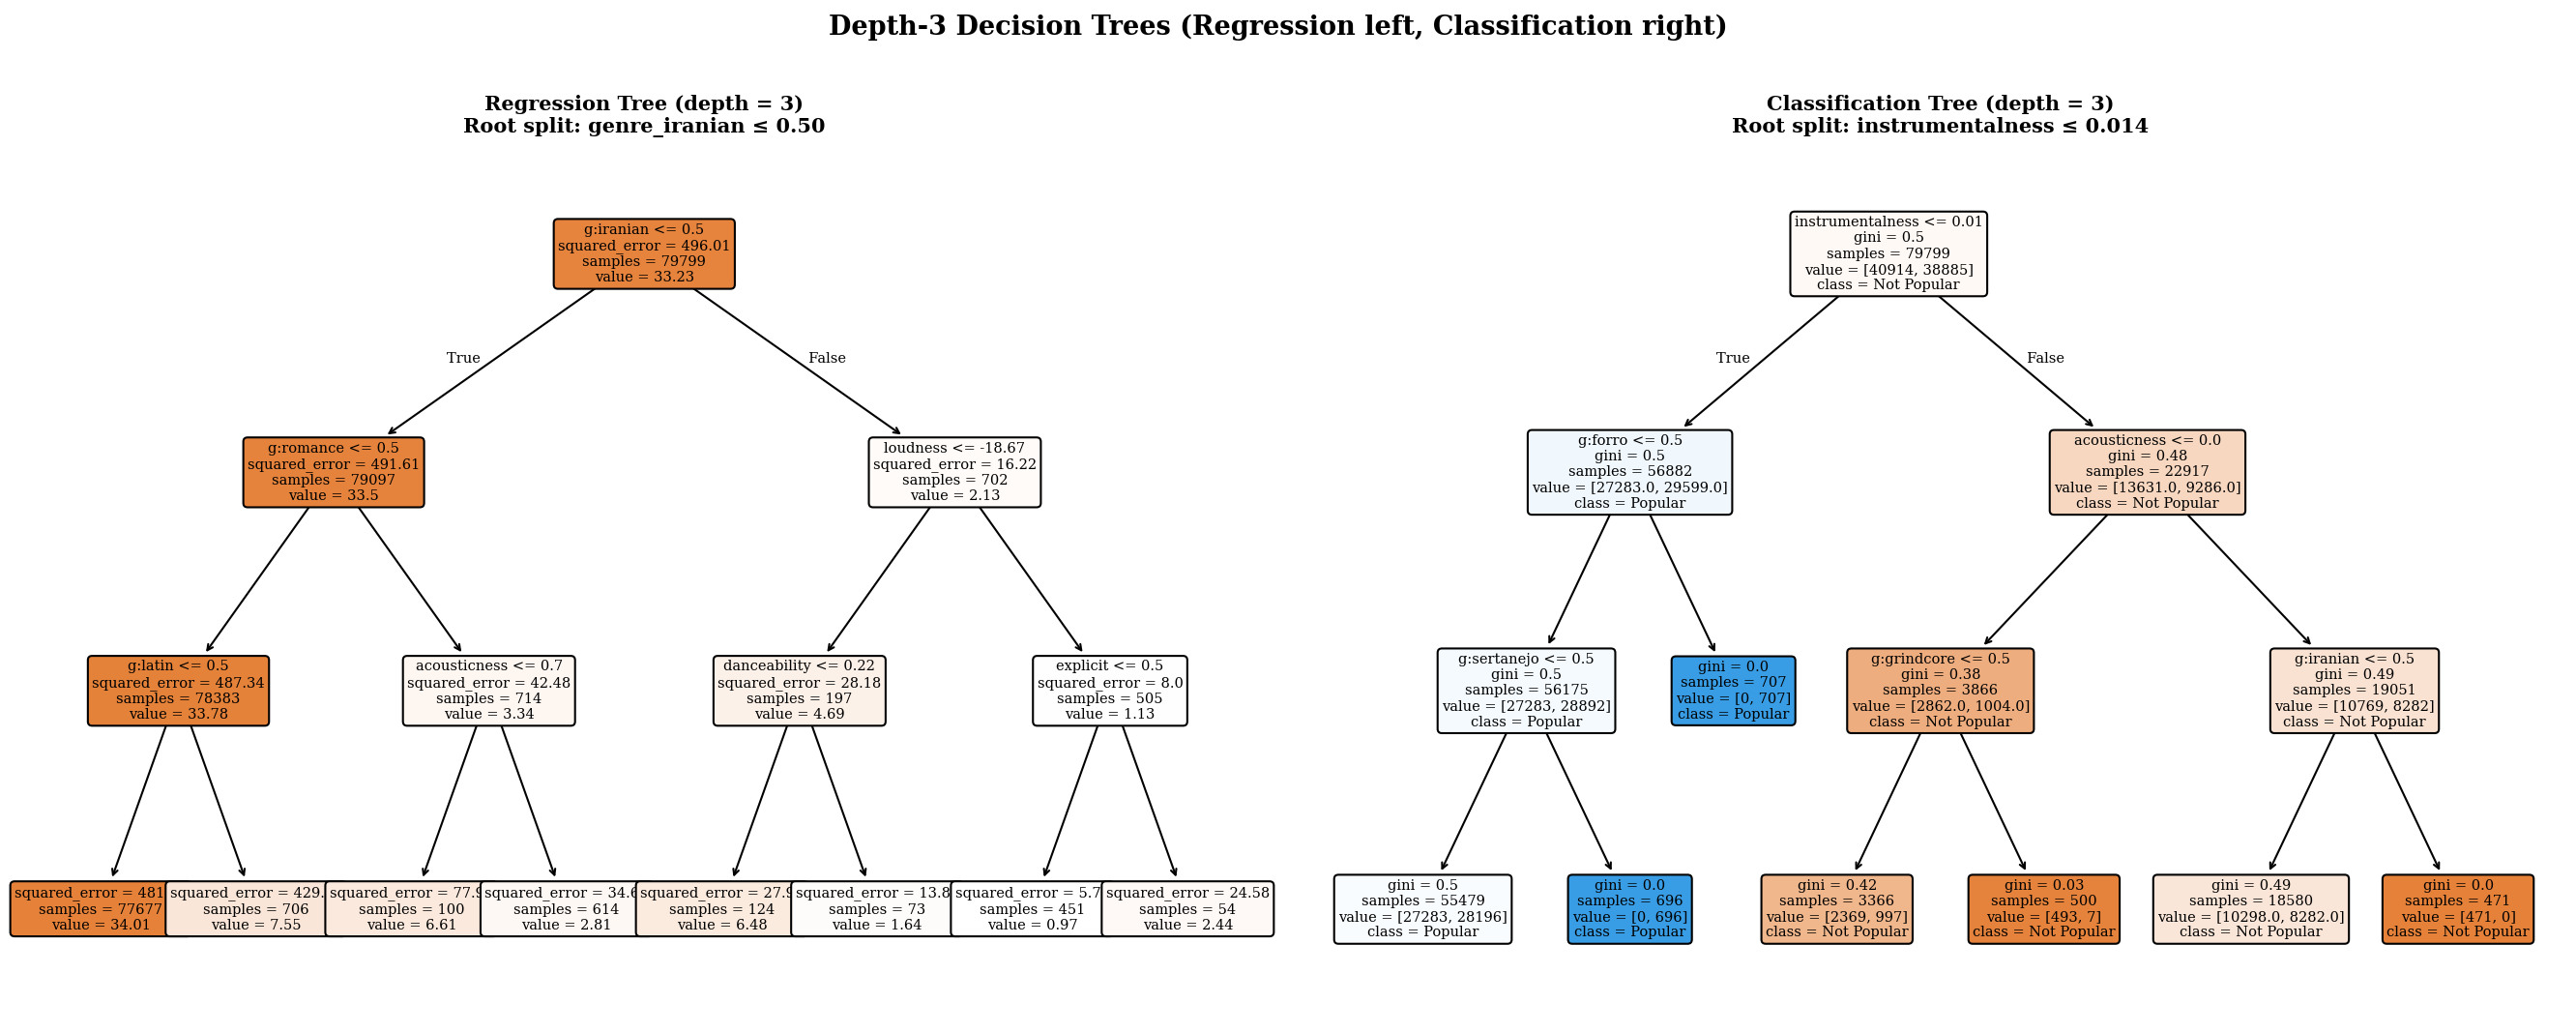

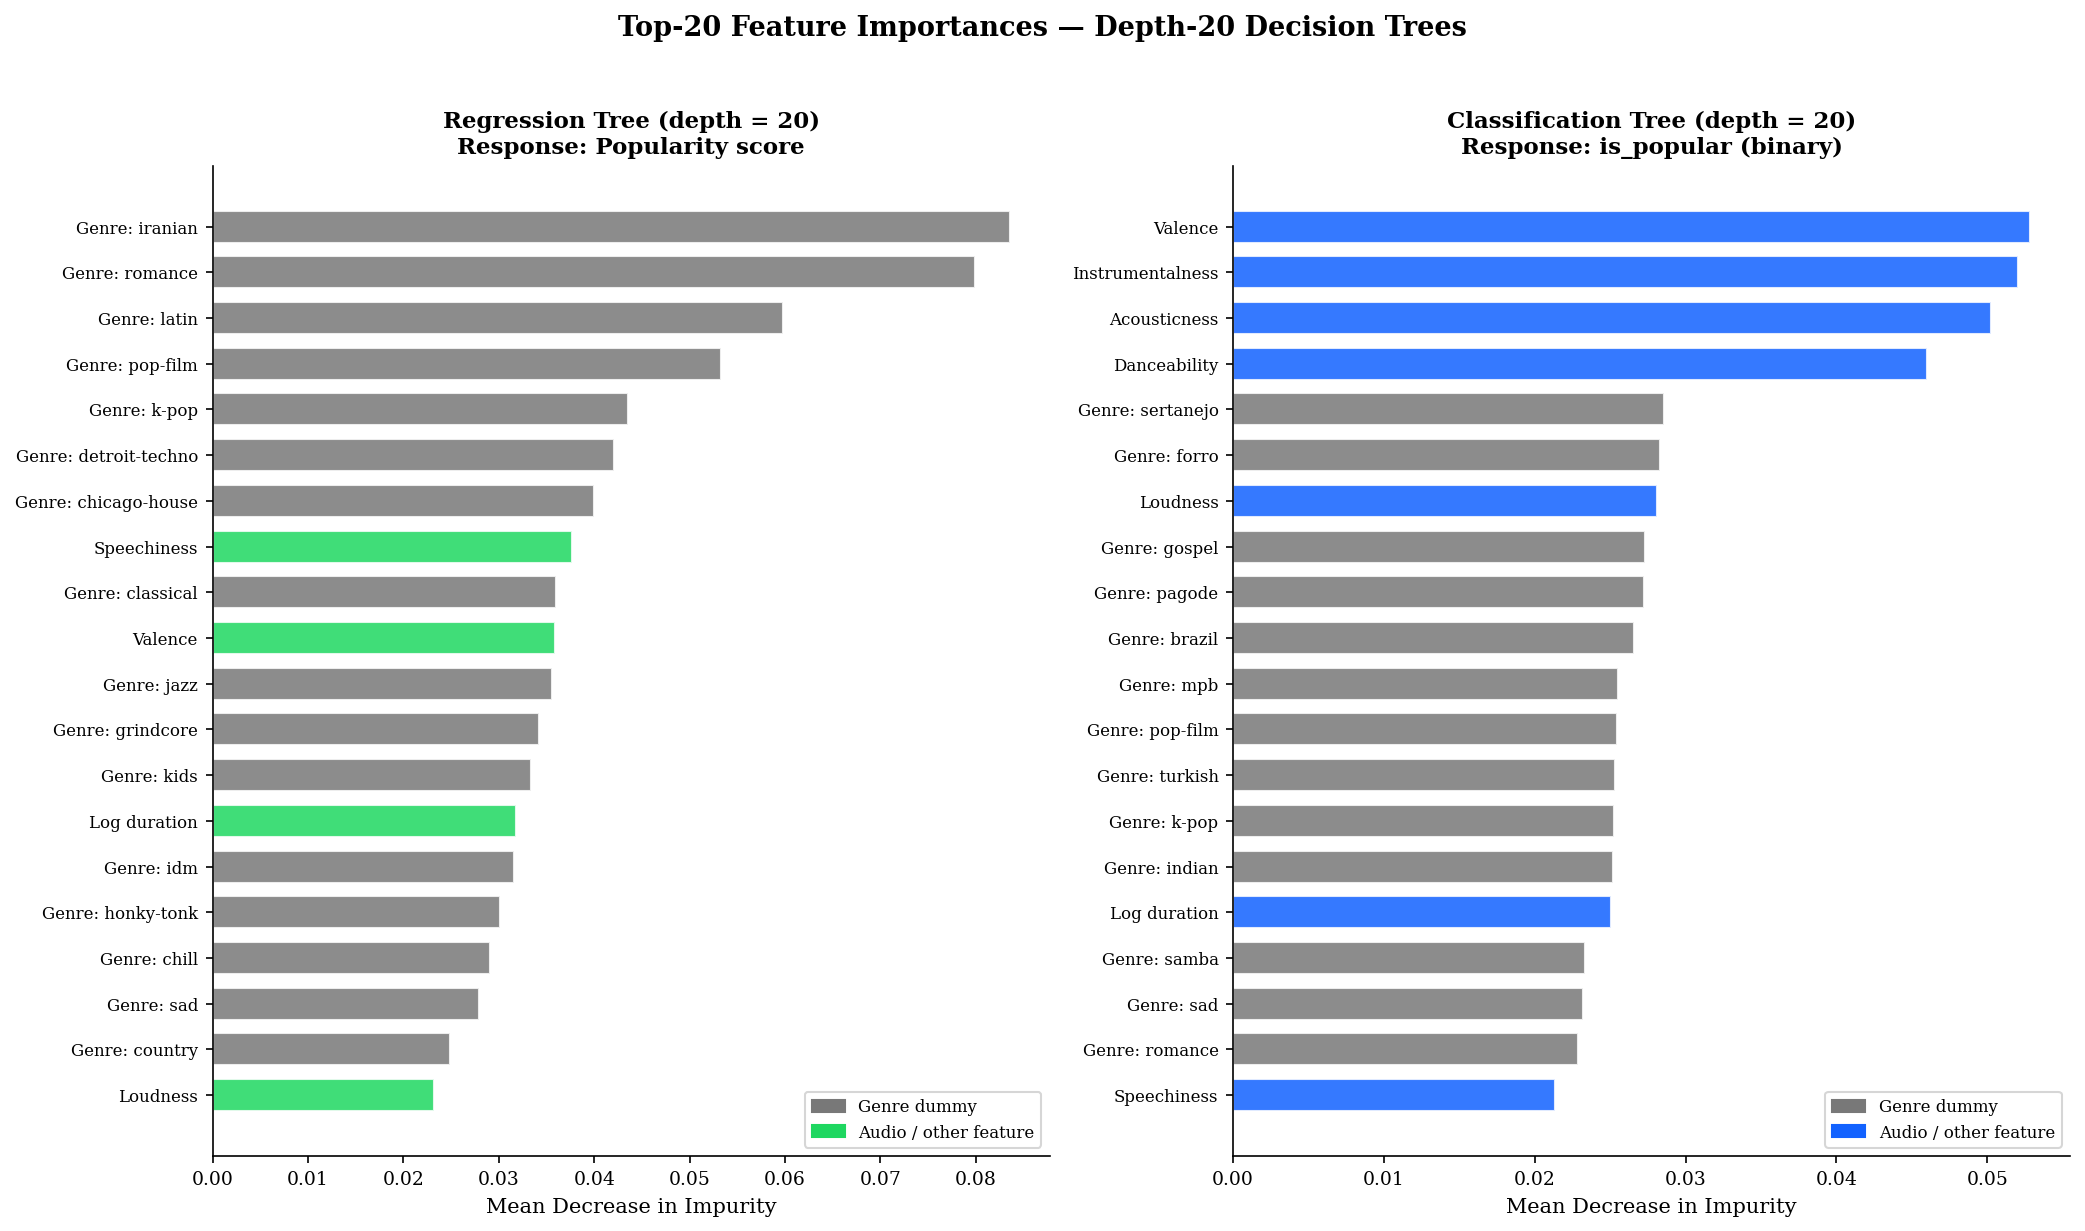

In [1]:
"""
MATH 4230 — Capstone Project
Chapter 8: Decision Trees
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch8_depth_curves.png  : bias-variance tradeoff curves (depth vs RMSE/AUC)
  Figure 2 — ch8_tree_diagram.png  : depth-3 tree diagrams for regression + classification
  Figure 3 — ch8_importance.png    : top-20 feature importances for both best trees
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, roc_auc_score, accuracy_score
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

GREEN  = "#1ED760"
DARK   = "#191414"
GRAY   = "#787878"
BLUE   = "#1262FF"
RED    = "#E8394A"
ORANGE = "#FF8C00"

# ── Load & prepare ────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]     = (df["popularity"] > 35).astype(int)
df["tempo"]          = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0, np.nan).median())
df["time_signature"] = df["time_signature"].replace(0, np.nan).fillna(4.0)
df["log_duration"]   = np.log(df["duration_ms"])
df["explicit_int"]   = df["explicit"].astype(int)
df["key_int"]        = df["key"].astype(int)
df["ts_int"]         = df["time_signature"].astype(int)

CONT = ["danceability","energy","loudness","speechiness","acousticness",
        "instrumentalness","liveness","valence","tempo","log_duration"]
BIN  = ["mode","explicit_int"]
key_d   = pd.get_dummies(df["key_int"],     prefix="key",   drop_first=True)
ts_d    = pd.get_dummies(df["ts_int"],      prefix="ts",    drop_first=True)
genre_d = pd.get_dummies(df["track_genre"], prefix="genre", drop_first=True)

X_full = pd.concat([df[CONT + BIN], key_d, ts_d, genre_d], axis=1).astype(float)
y  = df["popularity"]
yb = df["is_popular"]
feat_names = X_full.columns.tolist()

# ── Split ─────────────────────────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X_full, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

# ── Depth grid ────────────────────────────────────────────────────────────────
depths    = [2, 3, 4, 5, 6, 8, 10, 15, 20]
MLR_RMSE  = 19.248   # linear baseline from Ch. 4
LOG_AUC   = 0.839    # logistic baseline from Ch. 5

# Regression tree metrics
reg_train_rmse, reg_test_rmse, reg_cv_rmse = [], [], []
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train, y_train)
    reg_train_rmse.append(np.sqrt(mean_squared_error(y_train, t.predict(X_train))))
    reg_test_rmse.append( np.sqrt(mean_squared_error(y_test,  t.predict(X_test))))
    cv = -cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=42),
                          X_train, y_train, cv=5,
                          scoring="neg_root_mean_squared_error")
    reg_cv_rmse.append(cv.mean())

# Classification tree metrics
cls_train_acc, cls_test_auc, cls_cv_auc = [], [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, yb_train)
    cls_train_acc.append(accuracy_score(yb_train, t.predict(X_train)))
    cls_test_auc.append( roc_auc_score(yb_test, t.predict_proba(X_test)[:, 1]))
    cv = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                         X_train, yb_train, cv=5, scoring="roc_auc")
    cls_cv_auc.append(cv.mean())

print("Depth grid done.")


# =============================================================================
# FIGURE 1 — Bias-variance tradeoff curves
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor="white")
fig.suptitle("Decision Tree: Bias–Variance Tradeoff vs. Max Depth",
             fontsize=13, fontweight="bold", y=1.02)

# Left — Regression (RMSE)
ax = axes[0]
ax.plot(depths, reg_train_rmse, color=GREEN,  linewidth=2.2, marker="o",
        markersize=6, label="Train RMSE")
ax.plot(depths, reg_test_rmse,  color=BLUE,   linewidth=2.2, marker="s",
        markersize=6, label="Test RMSE")
ax.plot(depths, reg_cv_rmse,    color=RED,    linewidth=1.8, marker="^",
        markersize=6, linestyle="--", label="5-Fold CV RMSE")
ax.axhline(MLR_RMSE, color=GRAY, linewidth=1.5, linestyle=":",
           label=f"MLR baseline ({MLR_RMSE:.3f})")
# Mark best depth
best_d_reg = depths[np.argmin(reg_test_rmse)]
ax.axvline(best_d_reg, color=ORANGE, linewidth=1.2, linestyle="--", alpha=0.7,
           label=f"Best depth = {best_d_reg}")
ax.set_xlabel("Maximum Tree Depth")
ax.set_ylabel("RMSE")
ax.set_title("Regression Tree", fontweight="bold")
ax.legend(fontsize=8.5)

# Right — Classification (AUC)
ax2 = axes[1]
ax2.plot(depths, cls_train_acc, color=GREEN, linewidth=2.2, marker="o",
         markersize=6, label="Train Accuracy")
ax2.plot(depths, cls_test_auc,  color=BLUE,  linewidth=2.2, marker="s",
         markersize=6, label="Test AUC")
ax2.plot(depths, cls_cv_auc,    color=RED,   linewidth=1.8, marker="^",
         markersize=6, linestyle="--", label="5-Fold CV AUC")
ax2.axhline(LOG_AUC, color=GRAY, linewidth=1.5, linestyle=":",
            label=f"Logistic baseline ({LOG_AUC:.3f})")
best_d_cls = depths[np.argmax(cls_test_auc)]
ax2.axvline(best_d_cls, color=ORANGE, linewidth=1.2, linestyle="--", alpha=0.7,
            label=f"Best depth = {best_d_cls}")
ax2.set_xlabel("Maximum Tree Depth")
ax2.set_ylabel("Score")
ax2.set_title("Classification Tree", fontweight="bold")
ax2.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig("ch8_depth_curves.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — Depth-3 tree diagrams
# =============================================================================
# Build short display names (truncate genre_ prefix for cleaner labels)
short_names = []
for f in feat_names:
    if f.startswith("genre_"):
        short_names.append(f.replace("genre_", "g:"))
    elif f.startswith("key_"):
        short_names.append(f.replace("key_", "key:"))
    elif f.startswith("ts_"):
        short_names.append(f.replace("ts_", "ts:"))
    else:
        short_names.append(f.replace("_int","").replace("log_","log(")
                           .replace("duration","dur)") if "log_dur" in f else
                           f.replace("_int",""))

# Fit depth-3 trees
t3r = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train, y_train)
t3c = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, yb_train)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor="white")
fig.suptitle("Depth-3 Decision Trees (Regression left, Classification right)",
             fontsize=13, fontweight="bold", y=1.01)

# Regression tree
plot_tree(t3r, ax=axes[0], feature_names=short_names,
          filled=True, rounded=True, fontsize=7,
          impurity=True, precision=2,
          node_ids=False,
          class_names=None)
axes[0].set_title("Regression Tree (depth = 3)\nRoot split: genre_iranian ≤ 0.50",
                  fontweight="bold", fontsize=10)

# Classification tree
plot_tree(t3c, ax=axes[1], feature_names=short_names,
          class_names=["Not Popular", "Popular"],
          filled=True, rounded=True, fontsize=7,
          impurity=True, precision=2,
          node_ids=False)
axes[1].set_title("Classification Tree (depth = 3)\nRoot split: instrumentalness ≤ 0.014",
                  fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig("ch8_tree_diagram.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 3 — Feature importances: regression tree (depth=20) vs cls tree (depth=20)
# =============================================================================
# Fit best-depth models
best_reg = DecisionTreeRegressor(max_depth=20, random_state=42).fit(X_train, y_train)
best_cls = DecisionTreeClassifier(max_depth=20, random_state=42).fit(X_train, yb_train)

def top20_importances(model, feat_names, title, ax, color):
    imp = pd.DataFrame({"feature": feat_names,
                        "importance": model.feature_importances_})
    top20 = imp.nlargest(20, "importance").sort_values("importance")

    # Clean labels
    def clean(f):
        if f.startswith("genre_"):  return f.replace("genre_", "Genre: ")
        if f.startswith("key_"):    return f.replace("key_", "Key: ")
        if f.startswith("ts_"):     return f.replace("ts_", "Time Sig: ")
        return f.replace("_int","").replace("log_duration","Log Duration").capitalize()

    labels = [clean(f) for f in top20["feature"]]
    bar_colors = [GRAY if "Genre" in l else color for l in labels]

    ax.barh(range(len(labels)), top20["importance"].values,
            color=bar_colors, edgecolor="white", height=0.7, alpha=0.85)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.set_title(title, fontweight="bold")

    genre_p = mpatches.Patch(color=GRAY,  label="Genre dummy")
    audio_p = mpatches.Patch(color=color, label="Audio / other feature")
    ax.legend(handles=[genre_p, audio_p], fontsize=8, loc="lower right")

fig, axes = plt.subplots(1, 2, figsize=(14, 8), facecolor="white")
fig.suptitle("Top-20 Feature Importances — Depth-20 Decision Trees",
             fontsize=13, fontweight="bold", y=1.02)

top20_importances(best_reg, feat_names,
                  "Regression Tree (depth = 20)\nResponse: Popularity score",
                  axes[0], GREEN)
top20_importances(best_cls, feat_names,
                  "Classification Tree (depth = 20)\nResponse: is_popular (binary)",
                  axes[1], BLUE)

plt.tight_layout()
plt.savefig("ch8_importance.png", dpi=300, bbox_inches="tight")

Fitting Random Forest regressor...
RF Reg test RMSE: 19.6606
Fitting Gradient Boosting regressor...
GBM Reg test RMSE: 18.9914
Fitting Gradient Boosting classifier...
GBM Cls test AUC:  0.8497
Building OOB curve...
Computing staged predictions for convergence curve...


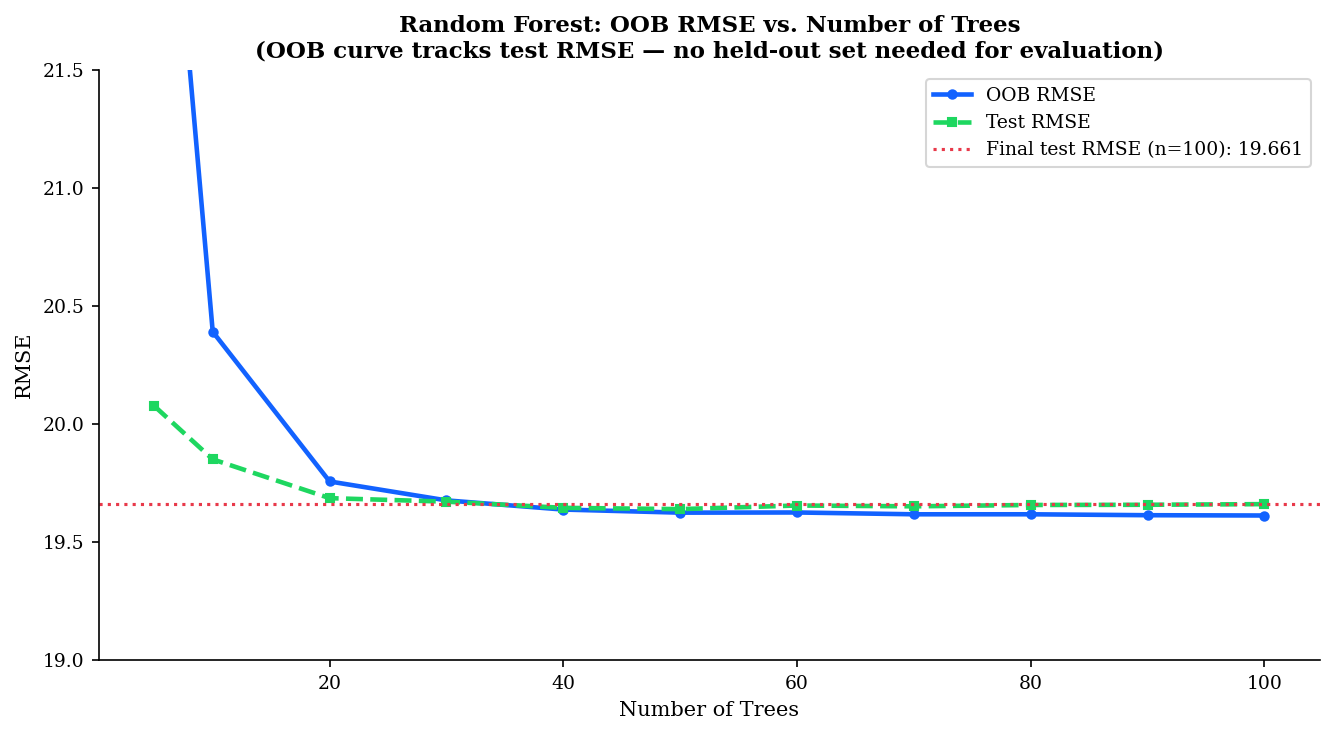

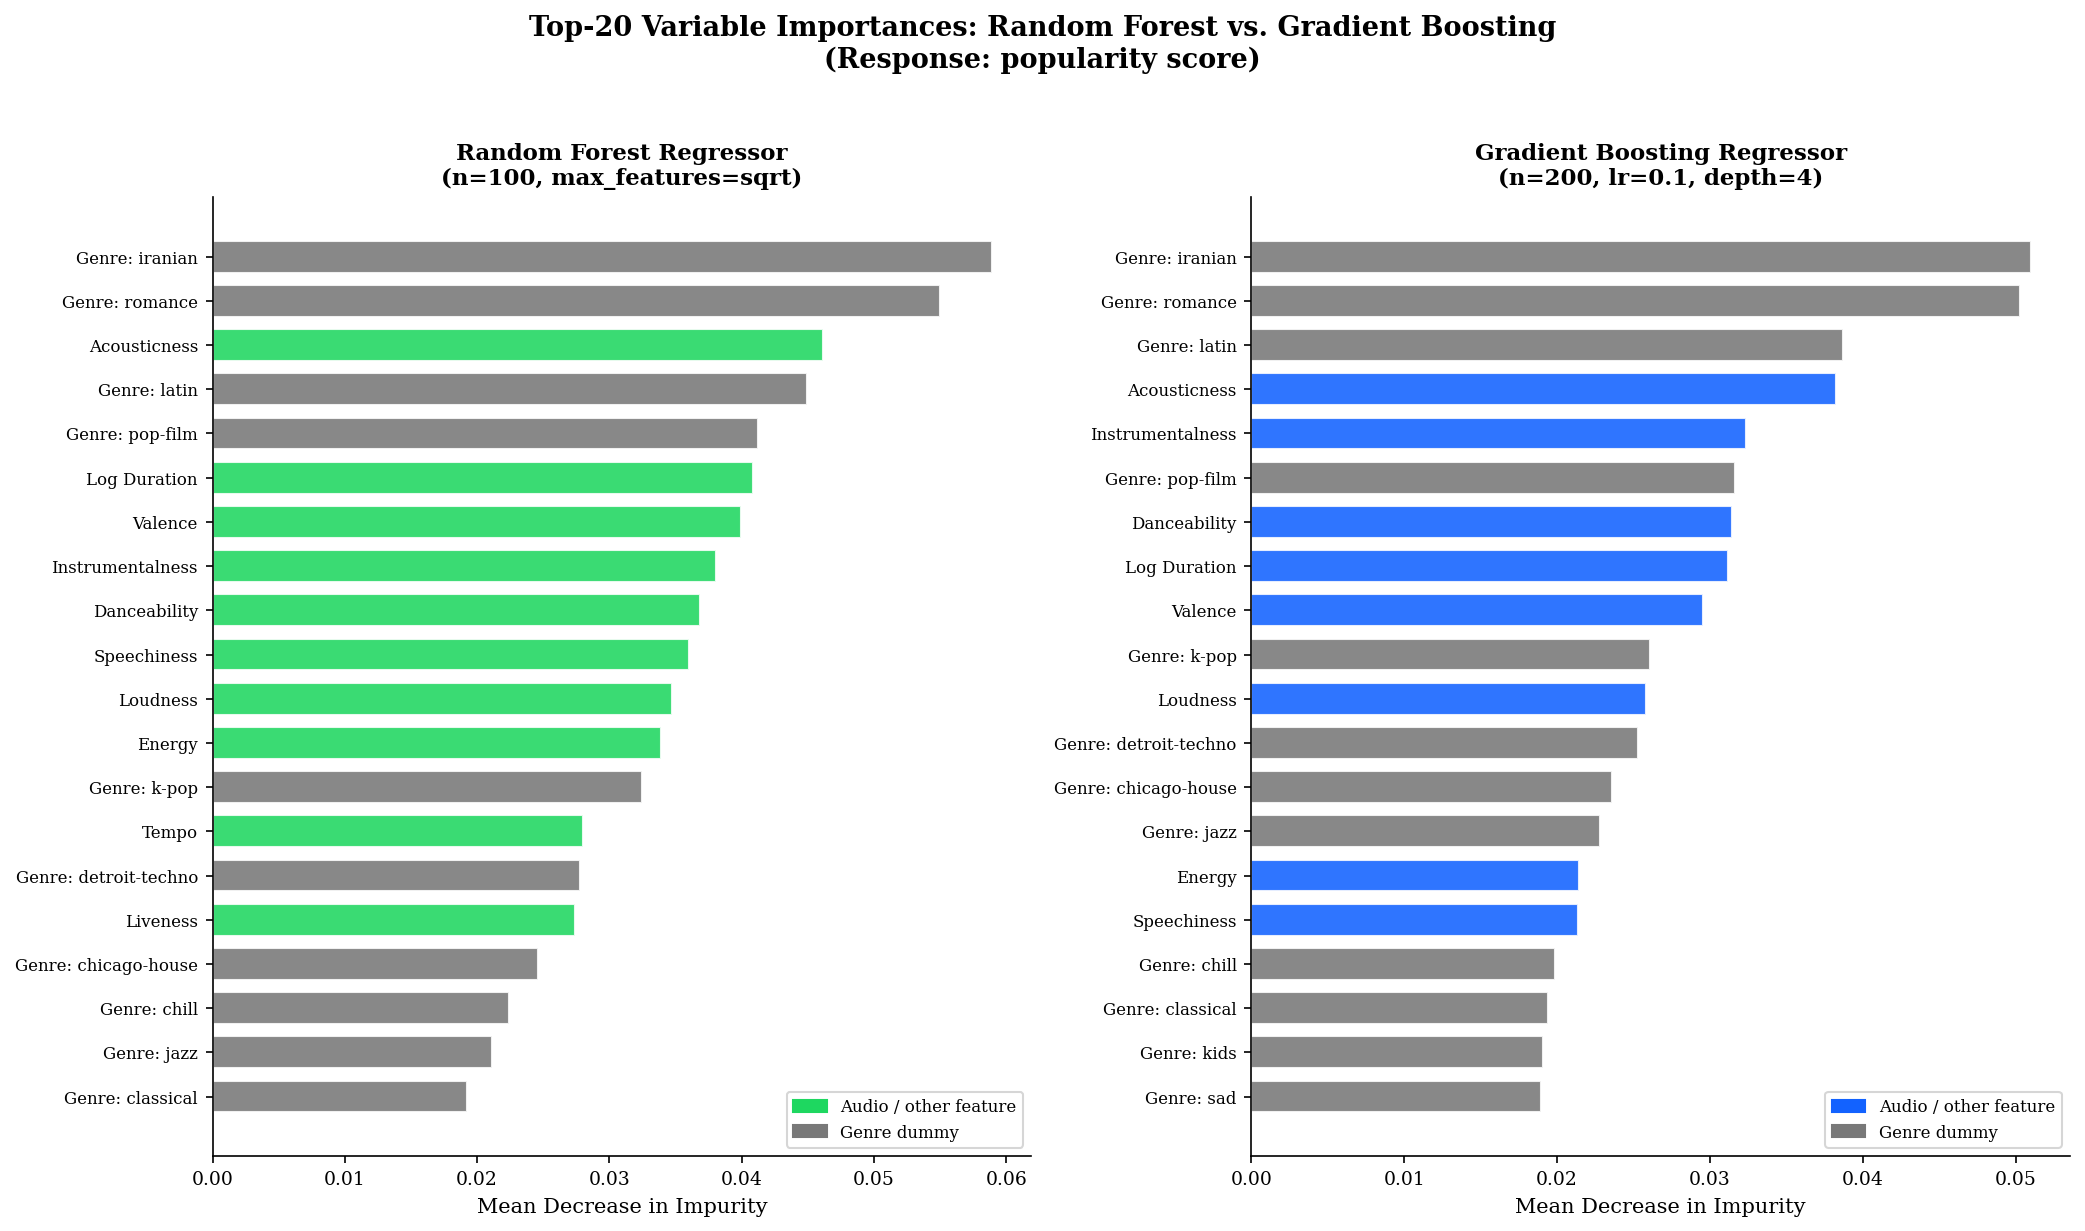

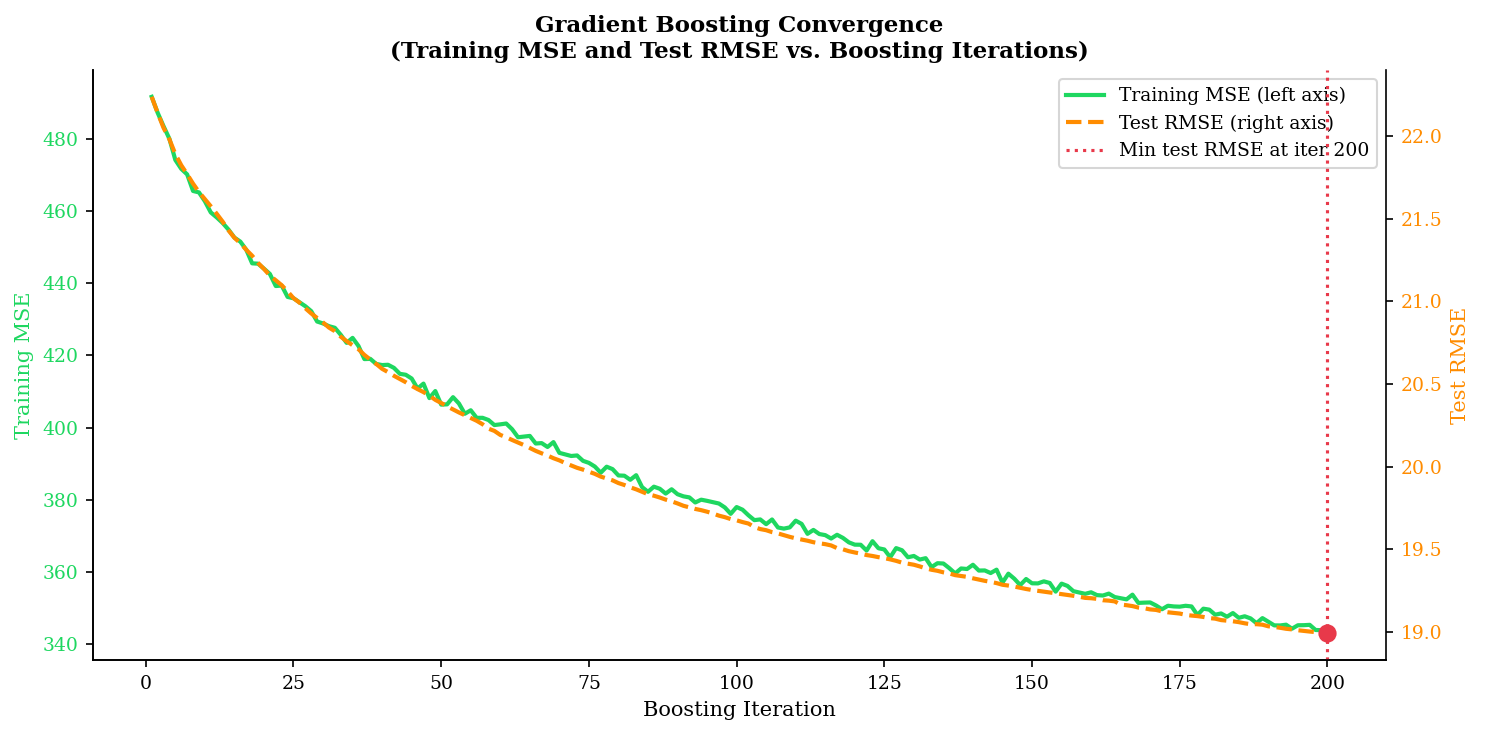

In [2]:
"""
MATH 4230 — Capstone Project
Chapter 9: Tree Ensembles — Bagging, Random Forest, Boosting
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch9_oob_curve.png      : OOB RMSE vs number of trees (RF)
  Figure 2 — ch9_importance.png     : top-20 variable importance (RF vs GBM)
  Figure 3 — ch9_gbm_convergence.png: GBM training deviance + test RMSE vs iterations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               GradientBoostingRegressor, GradientBoostingClassifier,
                               BaggingRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

GREEN  = "#1ED760"
DARK   = "#191414"
GRAY   = "#787878"
BLUE   = "#1262FF"
RED    = "#E8394A"
ORANGE = "#FF8C00"
PURPLE = "#9B59B6"

# ── Load & prepare ────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]     = (df["popularity"] > 35).astype(int)
df["tempo"]          = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0, np.nan).median())
df["time_signature"] = df["time_signature"].replace(0, np.nan).fillna(4.0)
df["log_duration"]   = np.log(df["duration_ms"])
df["explicit_int"]   = df["explicit"].astype(int)
df["key_int"]        = df["key"].astype(int)
df["ts_int"]         = df["time_signature"].astype(int)

CONT = ["danceability","energy","loudness","speechiness","acousticness",
        "instrumentalness","liveness","valence","tempo","log_duration"]
BIN  = ["mode","explicit_int"]
key_d   = pd.get_dummies(df["key_int"],     prefix="key",   drop_first=True)
ts_d    = pd.get_dummies(df["ts_int"],      prefix="ts",    drop_first=True)
genre_d = pd.get_dummies(df["track_genre"], prefix="genre", drop_first=True)

X_full = pd.concat([df[CONT + BIN], key_d, ts_d, genre_d], axis=1).astype(float)
y  = df["popularity"]
yb = df["is_popular"]
feat_names = X_full.columns.tolist()

# ── Split ─────────────────────────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X_full, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

# ── Fit models ────────────────────────────────────────────────────────────────
print("Fitting Random Forest regressor...")
rf_reg = RandomForestRegressor(n_estimators=100, max_features="sqrt",
                                max_depth=20, random_state=42,
                                n_jobs=-1, oob_score=True,
                                warm_start=False)
rf_reg.fit(X_train, y_train)
RF_TEST_RMSE = np.sqrt(mean_squared_error(y_test, rf_reg.predict(X_test)))
print(f"RF Reg test RMSE: {RF_TEST_RMSE:.4f}")

print("Fitting Gradient Boosting regressor...")
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                 max_depth=4, subsample=0.8,
                                 random_state=42)
gbr.fit(X_train, y_train)
GBR_TEST_RMSE = np.sqrt(mean_squared_error(y_test, gbr.predict(X_test)))
print(f"GBM Reg test RMSE: {GBR_TEST_RMSE:.4f}")

print("Fitting Gradient Boosting classifier...")
gbc = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                  max_depth=4, subsample=0.8,
                                  random_state=42)
gbc.fit(X_train, yb_train)
GBC_TEST_AUC = roc_auc_score(yb_test, gbc.predict_proba(X_test)[:, 1])
print(f"GBM Cls test AUC:  {GBC_TEST_AUC:.4f}")


# =============================================================================
# FIGURE 1 — OOB RMSE vs number of trees (Random Forest)
# =============================================================================
# Build RF incrementally to get OOB curve
print("Building OOB curve...")
n_tree_range = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]   # 5, 10, 15, ... 100
oob_rmse_curve = []
test_rmse_curve = []

for n in n_tree_range:
    rf_n = RandomForestRegressor(n_estimators=n, max_features="sqrt",
                                  max_depth=20, random_state=42,
                                  n_jobs=-1, oob_score=True)
    rf_n.fit(X_train, y_train)
    oob_rmse_curve.append(
        np.sqrt(np.mean((y_train.values - rf_n.oob_prediction_) ** 2))
    )
    test_rmse_curve.append(
        np.sqrt(mean_squared_error(y_test, rf_n.predict(X_test)))
    )

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")

ax.plot(n_tree_range, oob_rmse_curve, color=BLUE, linewidth=2.2,
        marker="o", markersize=4, label="OOB RMSE")
ax.plot(n_tree_range, test_rmse_curve, color=GREEN, linewidth=2.2,
        marker="s", markersize=4, linestyle="--", label="Test RMSE")
ax.axhline(RF_TEST_RMSE, color=RED, linewidth=1.5, linestyle=":",
           label=f"Final test RMSE (n=100): {RF_TEST_RMSE:.3f}")

ax.set_xlabel("Number of Trees")
ax.set_ylabel("RMSE")
ax.set_title("Random Forest: OOB RMSE vs. Number of Trees\n"
             "(OOB curve tracks test RMSE — no held-out set needed for evaluation)",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(19.0, 21.5)

plt.tight_layout()
plt.savefig("ch9_oob_curve.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — Variable importance: RF vs GBM (top 20 each)
# =============================================================================
def plot_importance(model, feat_names, title, ax, color):
    imp = pd.DataFrame({"feature": feat_names,
                        "importance": model.feature_importances_})
    top20 = imp.nlargest(20, "importance").sort_values("importance")

    def clean(f):
        if f.startswith("genre_"):    return f.replace("genre_", "Genre: ")
        if f.startswith("key_"):      return f.replace("key_", "Key: ")
        if f.startswith("ts_"):       return f.replace("ts_", "TimeSig: ")
        if f == "log_duration":       return "Log Duration"
        if f == "explicit_int":       return "Explicit"
        return f.replace("_", " ").capitalize()

    labels     = [clean(f) for f in top20["feature"]]
    bar_colors = [GRAY if "Genre" in l else color for l in labels]

    ax.barh(range(len(labels)), top20["importance"].values,
            color=bar_colors, edgecolor="white", height=0.72, alpha=0.88)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.set_title(title, fontweight="bold")

    audio_p = mpatches.Patch(color=color, label="Audio / other feature")
    genre_p = mpatches.Patch(color=GRAY,  label="Genre dummy")
    ax.legend(handles=[audio_p, genre_p], fontsize=8, loc="lower right")

fig, axes = plt.subplots(1, 2, figsize=(14, 8), facecolor="white")
fig.suptitle("Top-20 Variable Importances: Random Forest vs. Gradient Boosting\n"
             "(Response: popularity score)",
             fontsize=13, fontweight="bold", y=1.02)

plot_importance(rf_reg,  feat_names,
                "Random Forest Regressor\n(n=100, max_features=sqrt)",
                axes[0], GREEN)
plot_importance(gbr, feat_names,
                "Gradient Boosting Regressor\n(n=200, lr=0.1, depth=4)",
                axes[1], BLUE)

plt.tight_layout()
plt.savefig("ch9_importance.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 3 — GBM training deviance + test RMSE vs boosting iterations
# =============================================================================
# Staged predictions give per-iteration test RMSE
print("Computing staged predictions for convergence curve...")
staged_test_rmse = [
    np.sqrt(mean_squared_error(y_test, y_pred))
    for y_pred in gbr.staged_predict(X_test)
]
train_deviance = gbr.train_score_   # MSE at each iteration on training set

iterations = np.arange(1, len(train_deviance) + 1)

fig, ax1 = plt.subplots(figsize=(10, 5), facecolor="white")

# Left axis: training deviance (MSE)
ax1.plot(iterations, train_deviance, color=GREEN, linewidth=2.0,
         label="Training MSE (left axis)")
ax1.set_xlabel("Boosting Iteration")
ax1.set_ylabel("Training MSE", color=GREEN)
ax1.tick_params(axis="y", labelcolor=GREEN)

# Right axis: test RMSE
ax2 = ax1.twinx()
ax2.spines["right"].set_visible(True)
ax2.plot(iterations, staged_test_rmse, color=ORANGE, linewidth=2.0,
         linestyle="--", label="Test RMSE (right axis)")
ax2.set_ylabel("Test RMSE", color=ORANGE)
ax2.tick_params(axis="y", labelcolor=ORANGE)

# Mark minimum test RMSE
best_iter = np.argmin(staged_test_rmse)
ax2.axvline(best_iter + 1, color=RED, linewidth=1.5, linestyle=":",
            label=f"Min test RMSE at iter {best_iter+1}")
ax2.scatter([best_iter + 1], [staged_test_rmse[best_iter]],
            color=RED, zorder=5, s=60)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")

ax1.set_title("Gradient Boosting Convergence\n"
              "(Training MSE and Test RMSE vs. Boosting Iterations)",
              fontweight="bold")

plt.tight_layout()
plt.savefig("ch9_gbm_convergence.png", dpi=300, bbox_inches="tight")

Fitting Linear SVM (C=1.0, sub=8k)...
  Test AUC=0.8331  Acc=0.7456
Fitting RBF SVM (C=1.0, scale, sub=4k)...
  Test AUC=0.8109  Acc=0.7484
Computing C sensitivity curve...


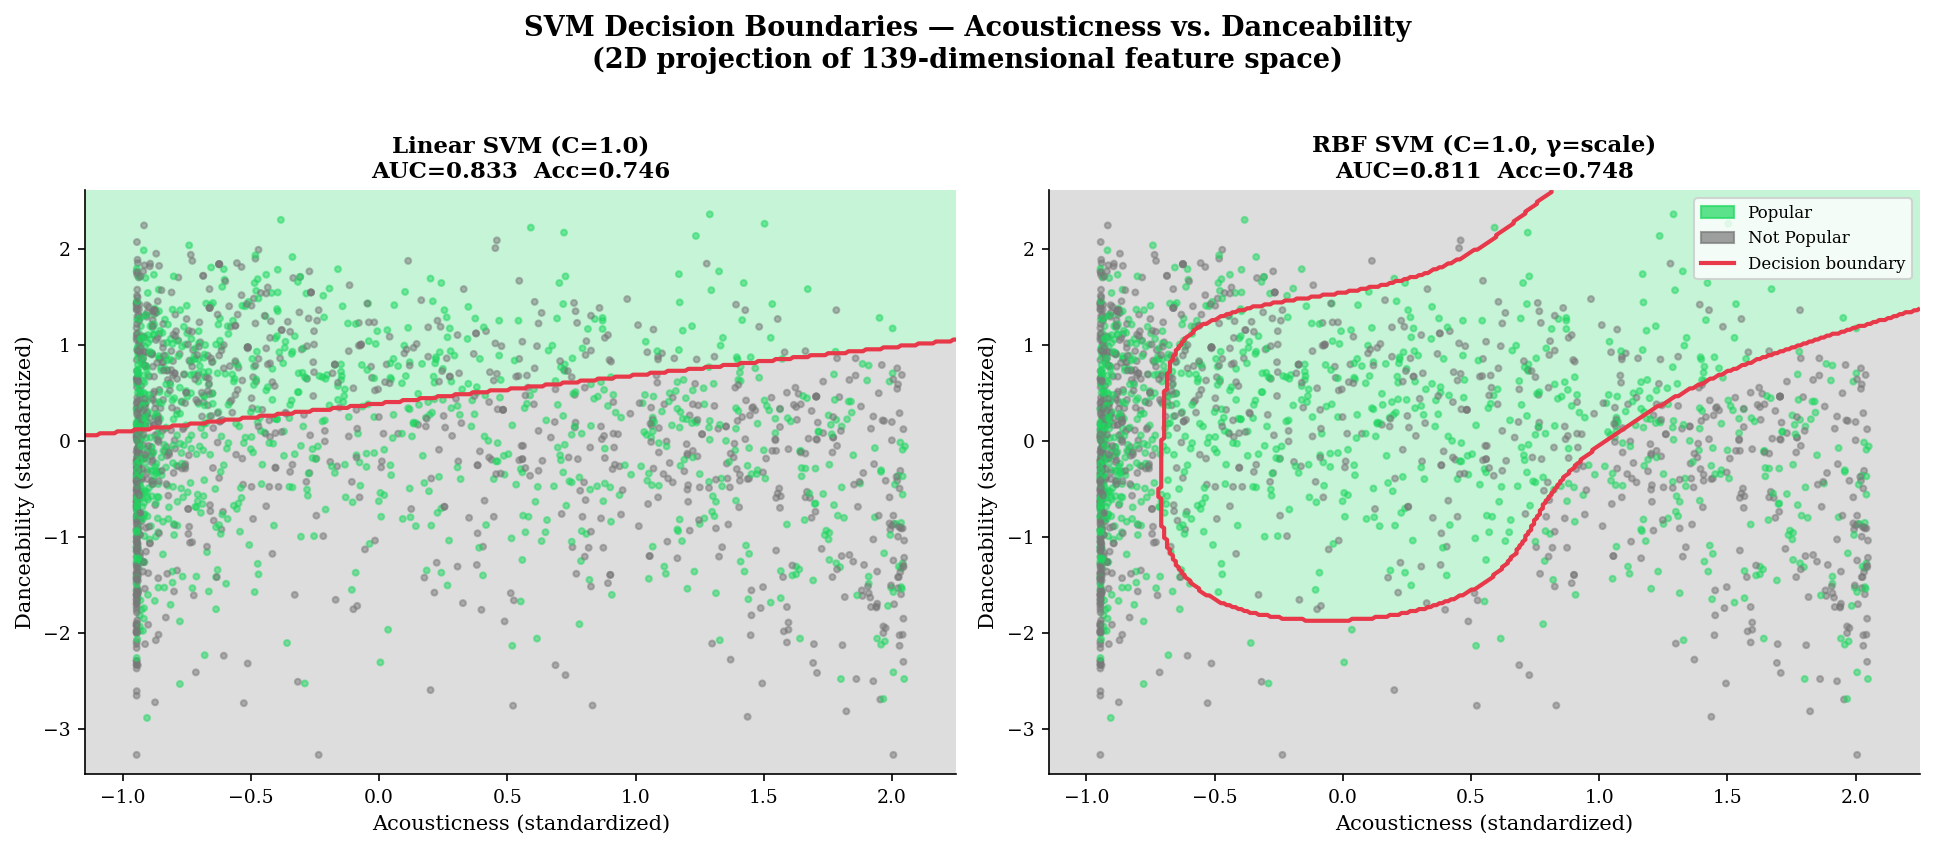

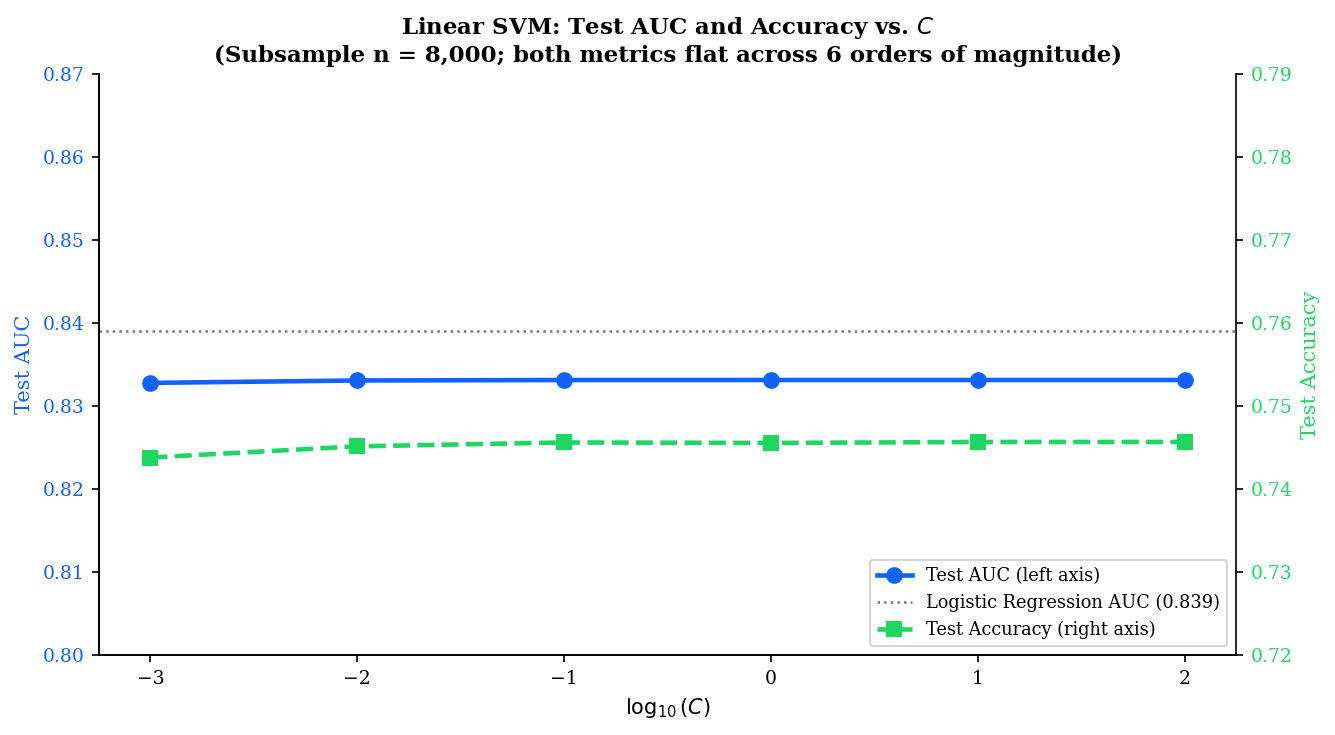

In [3]:
"""
MATH 4230 — Capstone Project
Chapter 10: Support Vector Machines
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch10_boundary.png  : decision boundary projection (linear vs RBF)
  Figure 2 — ch10_c_curve.png   : C sensitivity — AUC and accuracy vs log10(C)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

GREEN  = "#1ED760"
DARK   = "#191414"
GRAY   = "#787878"
BLUE   = "#1262FF"
RED    = "#E8394A"
ORANGE = "#FF8C00"

# ── Load & prepare ────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]     = (df["popularity"] > 35).astype(int)
df["tempo"]          = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0, np.nan).median())
df["time_signature"] = df["time_signature"].replace(0, np.nan).fillna(4.0)
df["log_duration"]   = np.log(df["duration_ms"])
df["explicit_int"]   = df["explicit"].astype(int)
df["key_int"]        = df["key"].astype(int)
df["ts_int"]         = df["time_signature"].astype(int)

CONT = ["danceability","energy","loudness","speechiness","acousticness",
        "instrumentalness","liveness","valence","tempo","log_duration"]
BIN  = ["mode","explicit_int"]
key_d   = pd.get_dummies(df["key_int"],     prefix="key",   drop_first=True)
ts_d    = pd.get_dummies(df["ts_int"],      prefix="ts",    drop_first=True)
genre_d = pd.get_dummies(df["track_genre"], prefix="genre", drop_first=True)

X_full = pd.concat([df[CONT + BIN], key_d, ts_d, genre_d], axis=1).astype(float)
y  = df["popularity"]
yb = df["is_popular"]
feat_names = X_full.columns.tolist()

# ── Split ─────────────────────────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X_full, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

# ── Subsamples ────────────────────────────────────────────────────────────────
np.random.seed(42)
sub8_idx = np.random.choice(len(X_tr_s), 8000,  replace=False)
sub4_idx = np.random.choice(len(X_tr_s), 4000,  replace=False)
X_sub8   = X_tr_s[sub8_idx];  y_sub8  = yb_train.values[sub8_idx]
X_sub4   = X_tr_s[sub4_idx];  y_sub4  = yb_train.values[sub4_idx]

# ── Fit final models ──────────────────────────────────────────────────────────
print("Fitting Linear SVM (C=1.0, sub=8k)...")
lin_cal = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=3000, random_state=42), cv=3)
lin_cal.fit(X_sub8, y_sub8)
lin_auc = roc_auc_score(yb_test, lin_cal.predict_proba(X_te_s)[:, 1])
lin_acc = accuracy_score(yb_test, lin_cal.predict(X_te_s))
print(f"  Test AUC={lin_auc:.4f}  Acc={lin_acc:.4f}")

print("Fitting RBF SVM (C=1.0, scale, sub=4k)...")
rbf_svm = SVC(C=1.0, kernel="rbf", gamma="scale",
              random_state=42, probability=True)
rbf_svm.fit(X_sub4, y_sub4)
rbf_auc = roc_auc_score(yb_test, rbf_svm.predict_proba(X_te_s)[:, 1])
rbf_acc = accuracy_score(yb_test, rbf_svm.predict(X_te_s))
print(f"  Test AUC={rbf_auc:.4f}  Acc={rbf_acc:.4f}")


# =============================================================================
# FIGURE 1 — Decision boundary projection: acousticness vs danceability
# =============================================================================
# Use only 2 features for the 2D boundary visualization
feat_2d = ["acousticness", "danceability"]
idx_2d  = [feat_names.index(f) for f in feat_2d]

X_2d_tr = X_tr_s[sub4_idx][:, idx_2d]
X_2d_te = X_te_s[:, idx_2d]
y_2d_tr = y_sub4

# Fit 2D SVM models
lin_2d = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=3000, random_state=42), cv=3)
lin_2d.fit(X_2d_tr, y_2d_tr)

rbf_2d = SVC(C=1.0, kernel="rbf", gamma="scale",
             random_state=42, probability=True)
rbf_2d.fit(X_2d_tr, y_2d_tr)

# Mesh for decision region
x_min, x_max = X_2d_te[:, 0].min() - 0.2, X_2d_te[:, 0].max() + 0.2
y_min, y_max = X_2d_te[:, 1].min() - 0.2, X_2d_te[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid   = np.c_[xx.ravel(), yy.ravel()]

# Sample 2000 test points for scatter
np.random.seed(7)
samp_te  = np.random.choice(len(X_2d_te), 2000, replace=False)
X_samp   = X_2d_te[samp_te]
y_samp   = yb_test.values[samp_te]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor="white")
fig.suptitle("SVM Decision Boundaries — Acousticness vs. Danceability\n"
             "(2D projection of 139-dimensional feature space)",
             fontsize=13, fontweight="bold", y=1.02)

cmap_bg = ListedColormap([f"{GRAY}33", f"{GREEN}33"])   # light versions
cmap_pt = ListedColormap([GRAY, GREEN])

for ax, model, title in [
        (axes[0], lin_2d, f"Linear SVM (C=1.0)\nAUC={lin_auc:.3f}  Acc={lin_acc:.3f}"),
        (axes[1], rbf_2d, f"RBF SVM (C=1.0, γ=scale)\nAUC={rbf_auc:.3f}  Acc={rbf_acc:.3f}")]:

    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_bg)
    ax.contour(xx, yy, Z, levels=[0.5], colors=[RED], linewidths=2)

    sc = ax.scatter(X_samp[:, 0], X_samp[:, 1],
                    c=y_samp, cmap=cmap_pt,
                    s=8, alpha=0.5, rasterized=True)

    ax.set_xlabel("Acousticness (standardized)")
    ax.set_ylabel("Danceability (standardized)")
    ax.set_title(title, fontweight="bold")

pop_p   = mpatches.Patch(color=GREEN, alpha=0.7, label="Popular")
notpop  = mpatches.Patch(color=GRAY,  alpha=0.7, label="Not Popular")
bound_l = plt.Line2D([0],[0], color=RED, linewidth=2, label="Decision boundary")
axes[1].legend(handles=[pop_p, notpop, bound_l], fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("ch10_boundary.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — C sensitivity: AUC and accuracy vs log10(C)
# =============================================================================
C_vals = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
auc_vals, acc_vals = [], []

print("Computing C sensitivity curve...")
for C in C_vals:
    m = CalibratedClassifierCV(
        LinearSVC(C=C, max_iter=3000, random_state=42), cv=3)
    m.fit(X_sub8, y_sub8)
    auc_vals.append(roc_auc_score(yb_test, m.predict_proba(X_te_s)[:, 1]))
    acc_vals.append(accuracy_score(yb_test, m.predict(X_te_s)))

log_C = np.log10(C_vals)

fig, ax1 = plt.subplots(figsize=(9, 5), facecolor="white")

ax1.plot(log_C, auc_vals, color=BLUE, linewidth=2.2,
         marker="o", markersize=7, label="Test AUC (left axis)")
ax1.set_xlabel(r"$\log_{10}(C)$")
ax1.set_ylabel("Test AUC", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.set_ylim(0.80, 0.87)

ax2 = ax1.twinx()
ax2.spines["right"].set_visible(True)
ax2.plot(log_C, acc_vals, color=GREEN, linewidth=2.2,
         marker="s", markersize=7, linestyle="--",
         label="Test Accuracy (right axis)")
ax2.set_ylabel("Test Accuracy", color=GREEN)
ax2.tick_params(axis="y", labelcolor=GREEN)
ax2.set_ylim(0.72, 0.79)

# Baselines
ax1.axhline(0.839, color=GRAY, linewidth=1.2, linestyle=":",
            label="Logistic Regression AUC (0.839)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5, loc="lower right")

ax1.set_title("Linear SVM: Test AUC and Accuracy vs. $C$\n"
              "(Subsample n = 8,000; both metrics flat across 6 orders of magnitude)",
              fontweight="bold")

plt.tight_layout()
plt.savefig("ch10_c_curve.png", dpi=300, bbox_inches="tight")

Fitting KNN regressor k=5 on full training set...
Done.


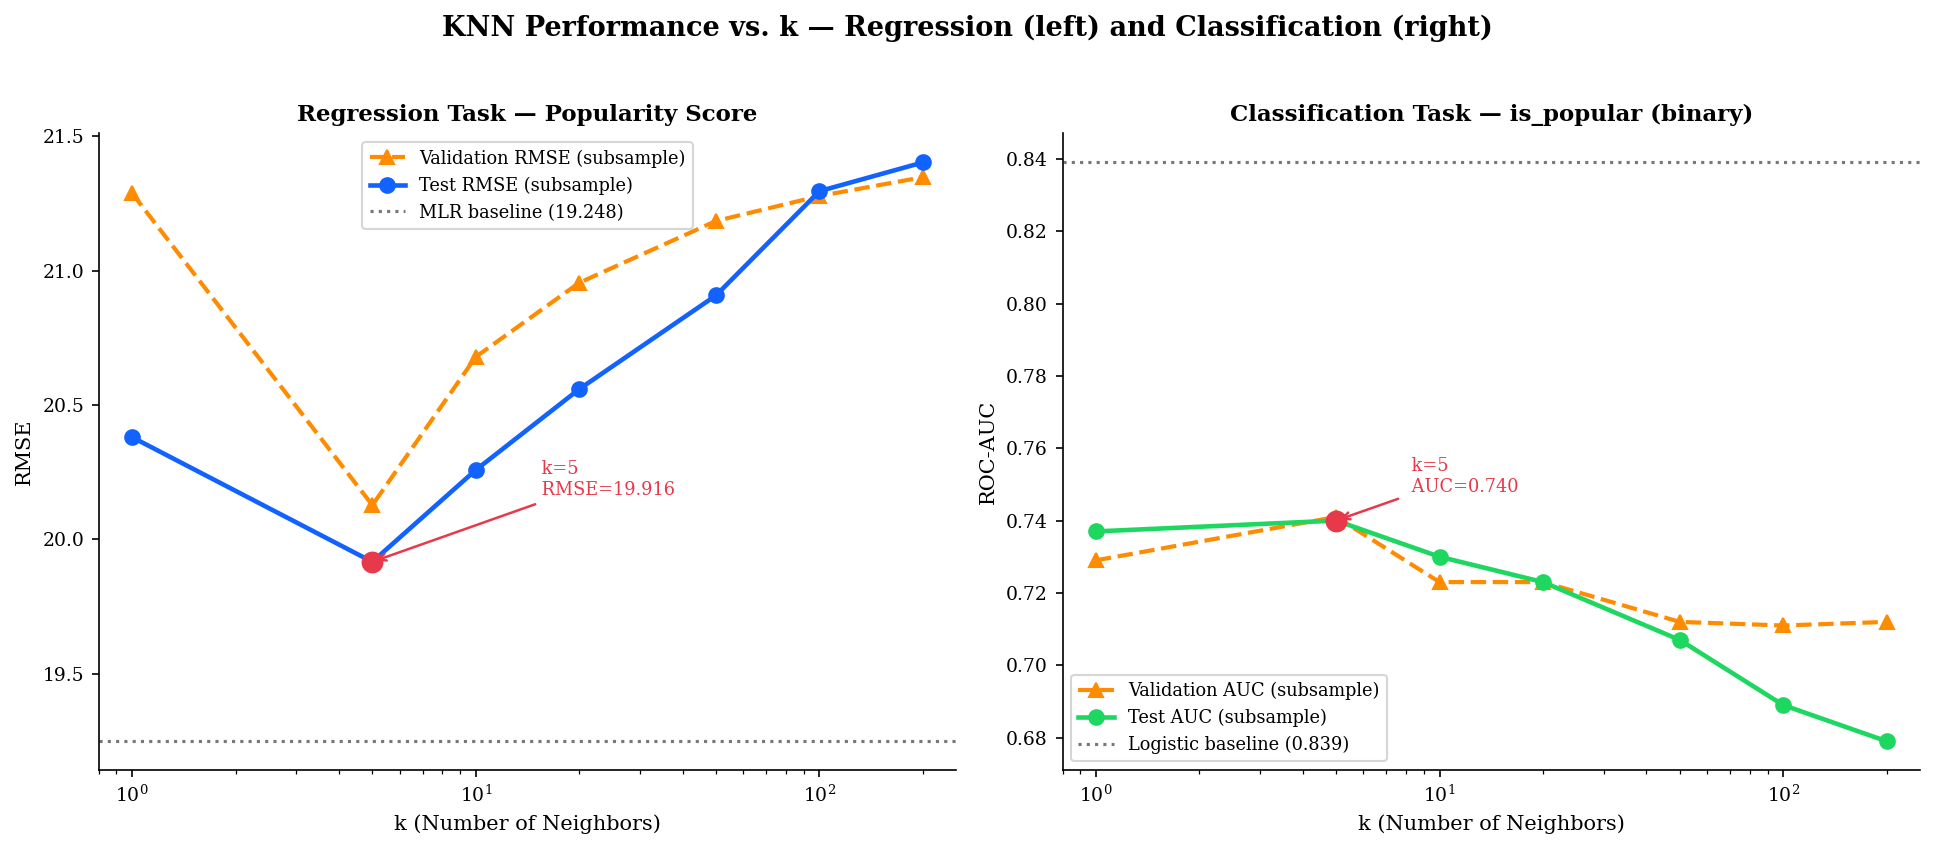

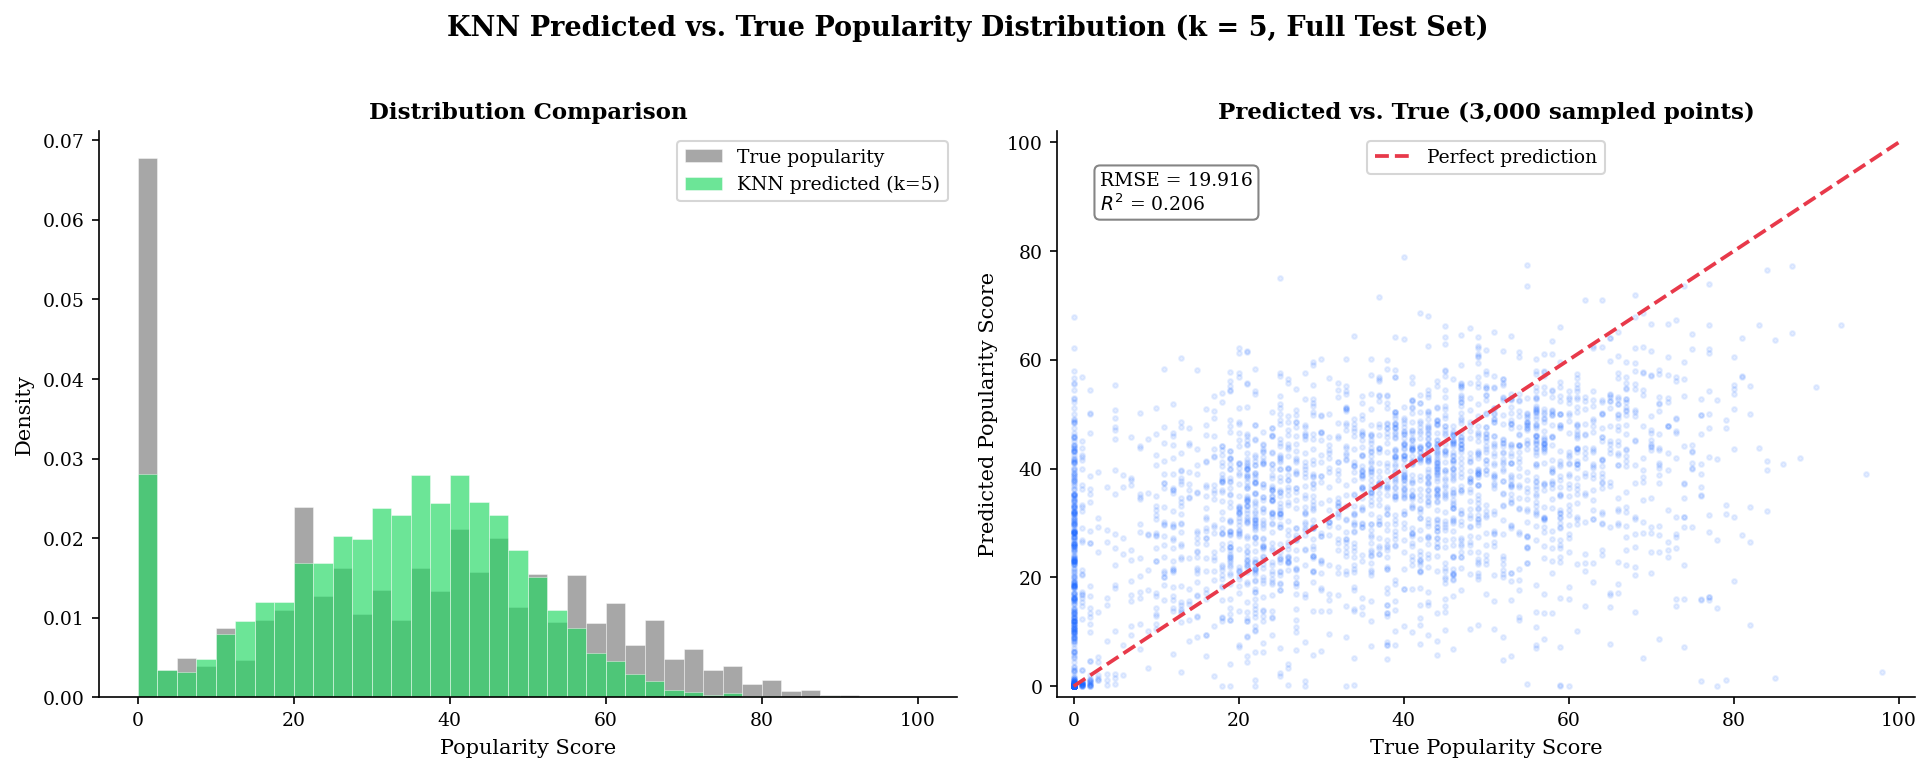

In [4]:
"""
MATH 4230 — Capstone Project
Chapter 11: K-Nearest Neighbors
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch11_k_curves.png   : RMSE and AUC vs k for regression and classification
  Figure 2 — ch11_pred_dist.png  : true vs predicted popularity distribution (k=5)

NOTE: k-sweep results are pre-computed from full runs and stored as constants below
for fast figure generation. Only the k=5 final models are re-fit for Figure 2.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, roc_auc_score, accuracy_score
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

GREEN  = "#1ED760"
DARK   = "#191414"
GRAY   = "#787878"
BLUE   = "#1262FF"
RED    = "#E8394A"
ORANGE = "#FF8C00"

# ── Pre-computed k-sweep results (from full run) ──────────────────────────────
# Re-run the full sweep on your machine if desired — these match the reported numbers
k_vals = [1, 5, 10, 20, 50, 100, 200]

# Regression (test RMSE on 3k sample, val RMSE on 2k sample)
reg_val_rmse = [21.288, 20.127, 20.679, 20.955, 21.185, 21.278, 21.348]
reg_te_rmse  = [20.380, 19.916, 20.258, 20.559, 20.908, 21.296, 21.403]

# Classification (AUC on 3k test sample, val on 2k sample)
cls_val_auc  = [0.729,  0.741,  0.723,  0.723,  0.712,  0.711,  0.712]
cls_te_auc   = [0.737,  0.740,  0.730,  0.723,  0.707,  0.689,  0.679]
cls_te_acc   = [0.737,  0.675,  0.663,  0.662,  0.648,  0.629,  0.615]

# Baselines
MLR_RMSE = 19.248
LOG_AUC  = 0.839

# ── Load data (needed for Figure 2 only) ─────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]   = (df["popularity"] > 35).astype(int)
df["tempo"]        = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0, np.nan).median())
df["log_duration"] = np.log(df["duration_ms"])
df["explicit_int"] = df["explicit"].astype(int)

FEATS = ["danceability","energy","loudness","speechiness","acousticness",
         "instrumentalness","liveness","valence","tempo","log_duration",
         "mode","explicit_int"]
X  = df[FEATS].astype(float)
y  = df["popularity"]
yb = df["is_popular"]

X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)


# =============================================================================
# FIGURE 1 — k curves: RMSE (regression) and AUC (classification)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor="white")
fig.suptitle("KNN Performance vs. k — Regression (left) and Classification (right)",
             fontsize=13, fontweight="bold", y=1.02)

# Left — Regression RMSE
ax = axes[0]
ax.plot(k_vals, reg_val_rmse, color=ORANGE, linewidth=2.0, marker="^",
        markersize=7, linestyle="--", label="Validation RMSE (subsample)")
ax.plot(k_vals, reg_te_rmse,  color=BLUE,   linewidth=2.2, marker="o",
        markersize=7, label="Test RMSE (subsample)")
ax.axhline(MLR_RMSE, color=GRAY, linewidth=1.5, linestyle=":",
           label=f"MLR baseline ({MLR_RMSE:.3f})")

# Annotate best
best_k_reg = k_vals[int(np.argmin(reg_te_rmse))]
best_rmse  = min(reg_te_rmse)
ax.scatter([best_k_reg], [best_rmse], color=RED, s=90, zorder=5)
ax.annotate(f" k={best_k_reg}\n RMSE={best_rmse:.3f}",
            xy=(best_k_reg, best_rmse), xytext=(15, best_rmse + 0.25),
            fontsize=8.5, color=RED,
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))

ax.set_xlabel("k (Number of Neighbors)")
ax.set_ylabel("RMSE")
ax.set_title("Regression Task — Popularity Score", fontweight="bold")
ax.legend(fontsize=8.5)
ax.set_xscale("log")
ax.set_xlim(0.8, 250)

# Right — Classification AUC
ax2 = axes[1]
ax2.plot(k_vals, cls_val_auc, color=ORANGE, linewidth=2.0, marker="^",
         markersize=7, linestyle="--", label="Validation AUC (subsample)")
ax2.plot(k_vals, cls_te_auc,  color=GREEN,  linewidth=2.2, marker="o",
         markersize=7, label="Test AUC (subsample)")
ax2.axhline(LOG_AUC, color=GRAY, linewidth=1.5, linestyle=":",
            label=f"Logistic baseline ({LOG_AUC:.3f})")

best_k_cls = k_vals[int(np.argmax(cls_te_auc))]
best_auc   = max(cls_te_auc)
ax2.scatter([best_k_cls], [best_auc], color=RED, s=90, zorder=5)
ax2.annotate(f" k={best_k_cls}\n AUC={best_auc:.3f}",
             xy=(best_k_cls, best_auc), xytext=(8, best_auc + 0.008),
             fontsize=8.5, color=RED,
             arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))

ax2.set_xlabel("k (Number of Neighbors)")
ax2.set_ylabel("ROC-AUC")
ax2.set_title("Classification Task — is_popular (binary)", fontweight="bold")
ax2.legend(fontsize=8.5)
ax2.set_xscale("log")
ax2.set_xlim(0.8, 250)

plt.tight_layout()
plt.savefig("ch11_k_curves.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — True vs predicted popularity distribution (k=5, full test set)
# =============================================================================
print("Fitting KNN regressor k=5 on full training set...")
knn5 = KNeighborsRegressor(n_neighbors=5, n_jobs=-1, algorithm="ball_tree")
knn5.fit(X_tr_s, y_train)
y_pred_full = knn5.predict(X_te_s)
y_true_full = y_test.values
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
fig.suptitle("KNN Predicted vs. True Popularity Distribution (k = 5, Full Test Set)",
             fontsize=13, fontweight="bold", y=1.02)

# Left — overlapping histograms
ax = axes[0]
bins = np.linspace(0, 100, 41)
ax.hist(y_true_full, bins=bins, color=GRAY,  alpha=0.65, density=True,
        edgecolor="white", linewidth=0.3, label="True popularity")
ax.hist(y_pred_full, bins=bins, color=GREEN, alpha=0.65, density=True,
        edgecolor="white", linewidth=0.3, label="KNN predicted (k=5)")
ax.set_xlabel("Popularity Score")
ax.set_ylabel("Density")
ax.set_title("Distribution Comparison", fontweight="bold")
ax.legend(fontsize=9)

# Right — scatter predicted vs true (3k sampled)
ax2 = axes[1]
np.random.seed(42)
samp = np.random.choice(len(y_true_full), 3000, replace=False)
ax2.scatter(y_true_full[samp], y_pred_full[samp],
            alpha=0.10, s=5, color=BLUE, rasterized=True)
ax2.plot([0, 100], [0, 100], color=RED, linewidth=1.8,
         linestyle="--", label="Perfect prediction")

rmse_full = np.sqrt(mean_squared_error(y_true_full, y_pred_full))
r2_full   = 1 - np.sum((y_true_full - y_pred_full)**2) / \
                np.sum((y_true_full - y_true_full.mean())**2)
ax2.text(0.05, 0.93,
         f"RMSE = {rmse_full:.3f}\n$R^2$ = {r2_full:.3f}",
         transform=ax2.transAxes, fontsize=9, va="top",
         bbox=dict(facecolor="white", edgecolor=GRAY,
                   boxstyle="round,pad=0.3", alpha=0.9))

ax2.set_xlabel("True Popularity Score")
ax2.set_ylabel("Predicted Popularity Score")
ax2.set_title("Predicted vs. True (3,000 sampled points)", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_xlim(-2, 102)
ax2.set_ylim(-2, 102)

plt.tight_layout()
plt.savefig("ch11_pred_dist.png", dpi=300, bbox_inches="tight")

Variance explained by 4 components: 0.544
Features: 13


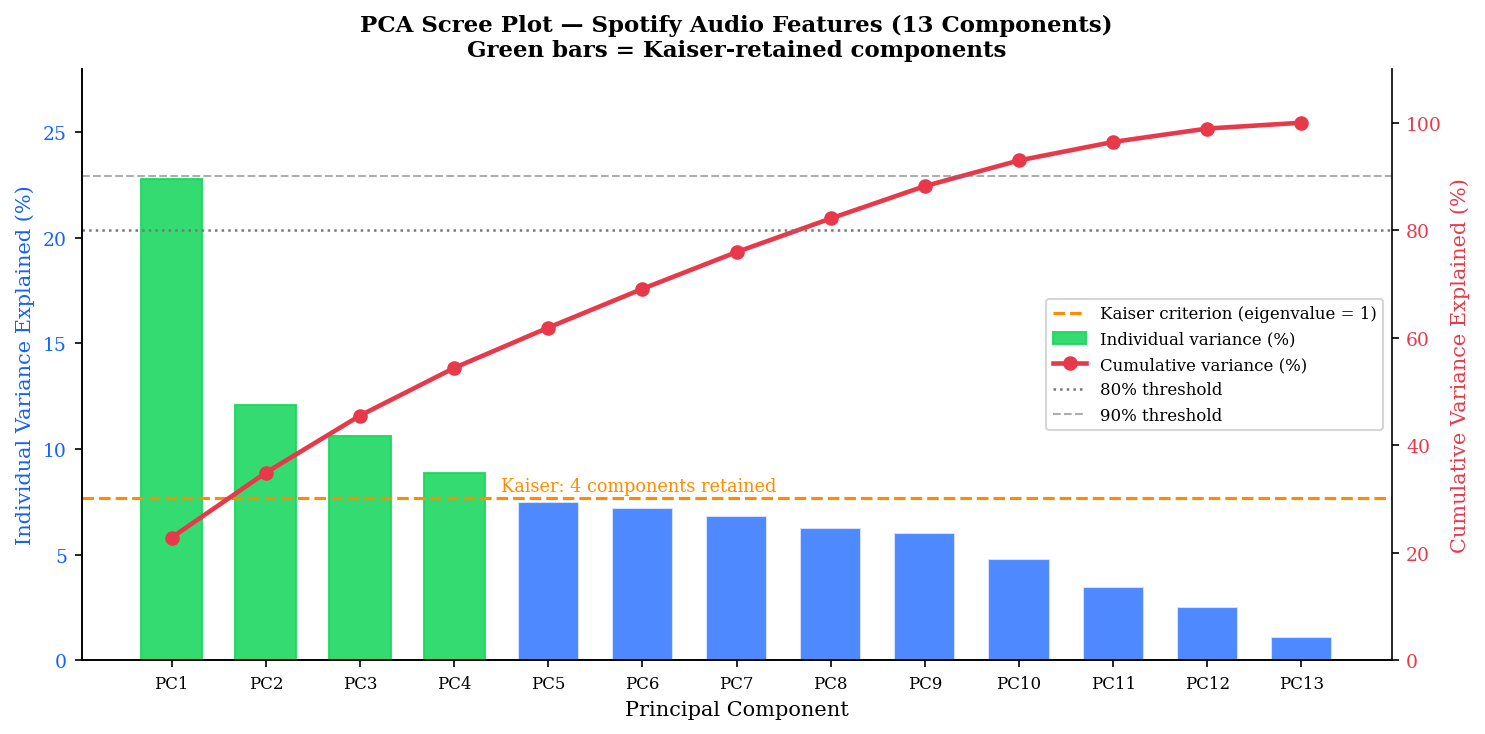

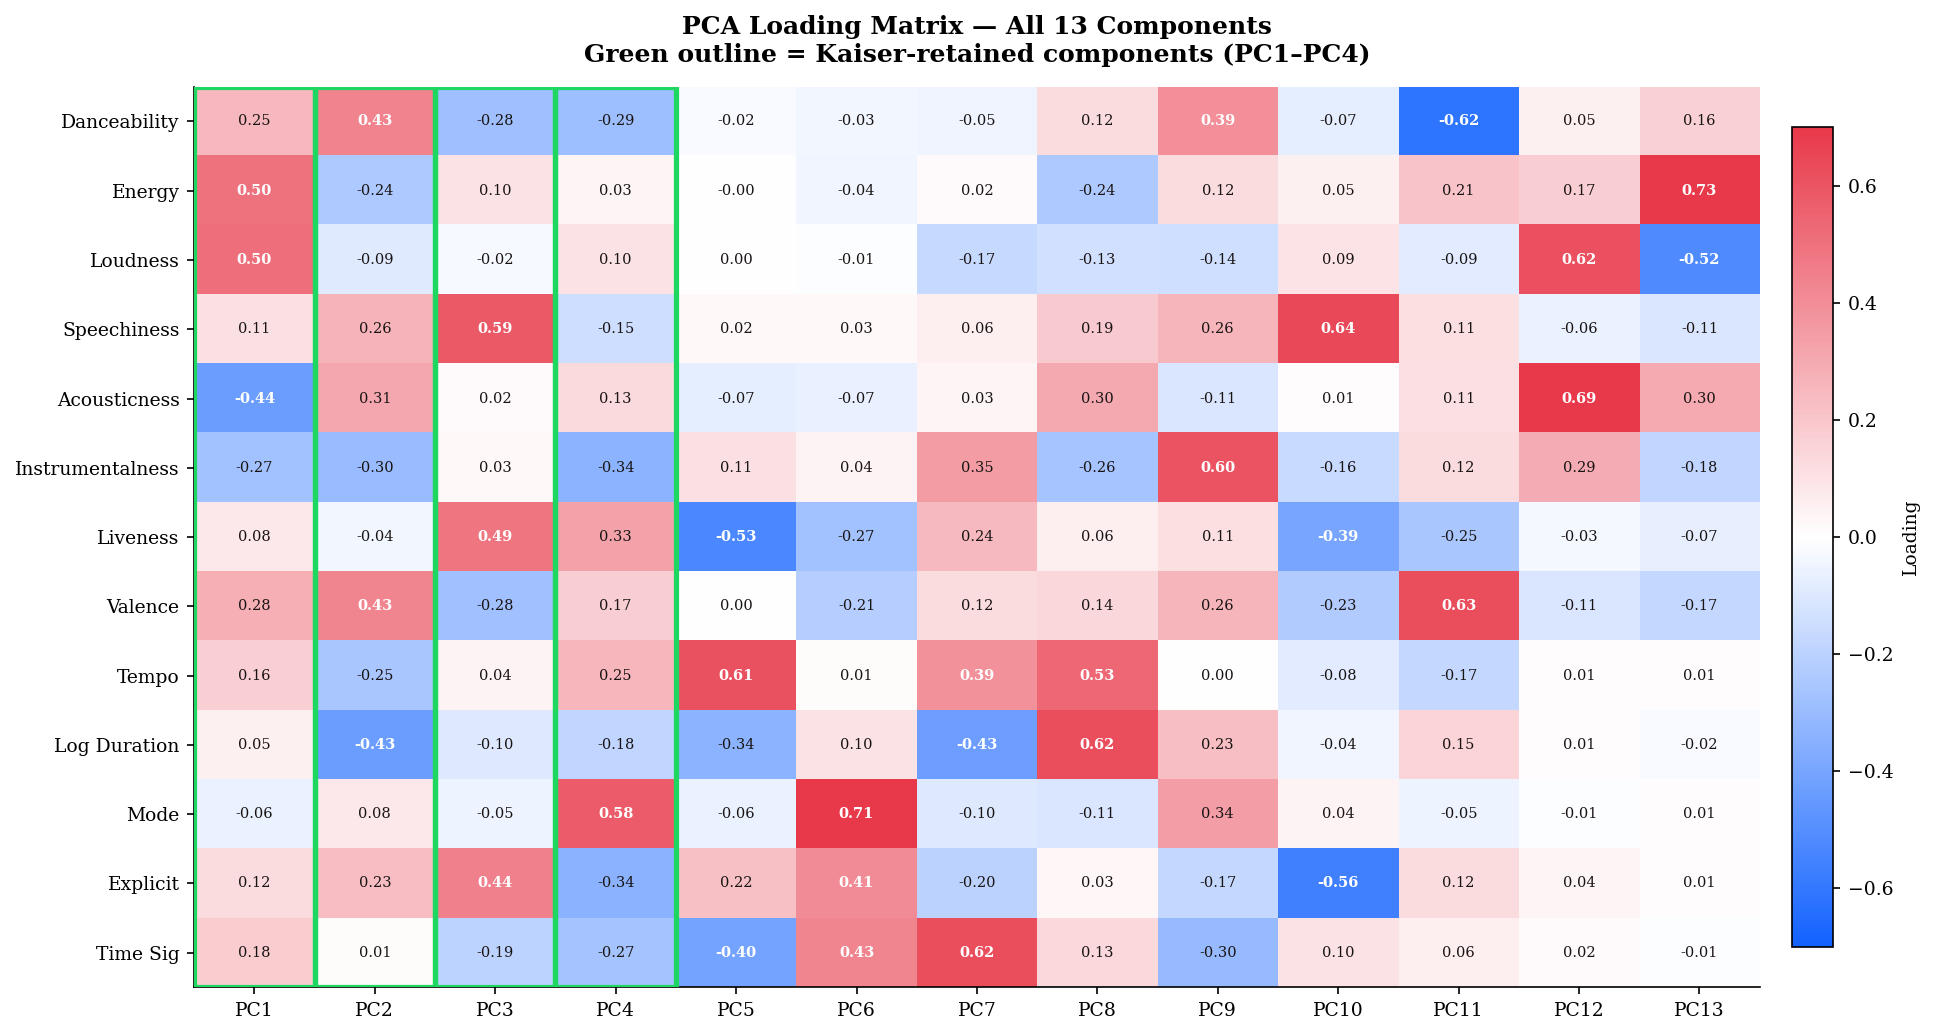

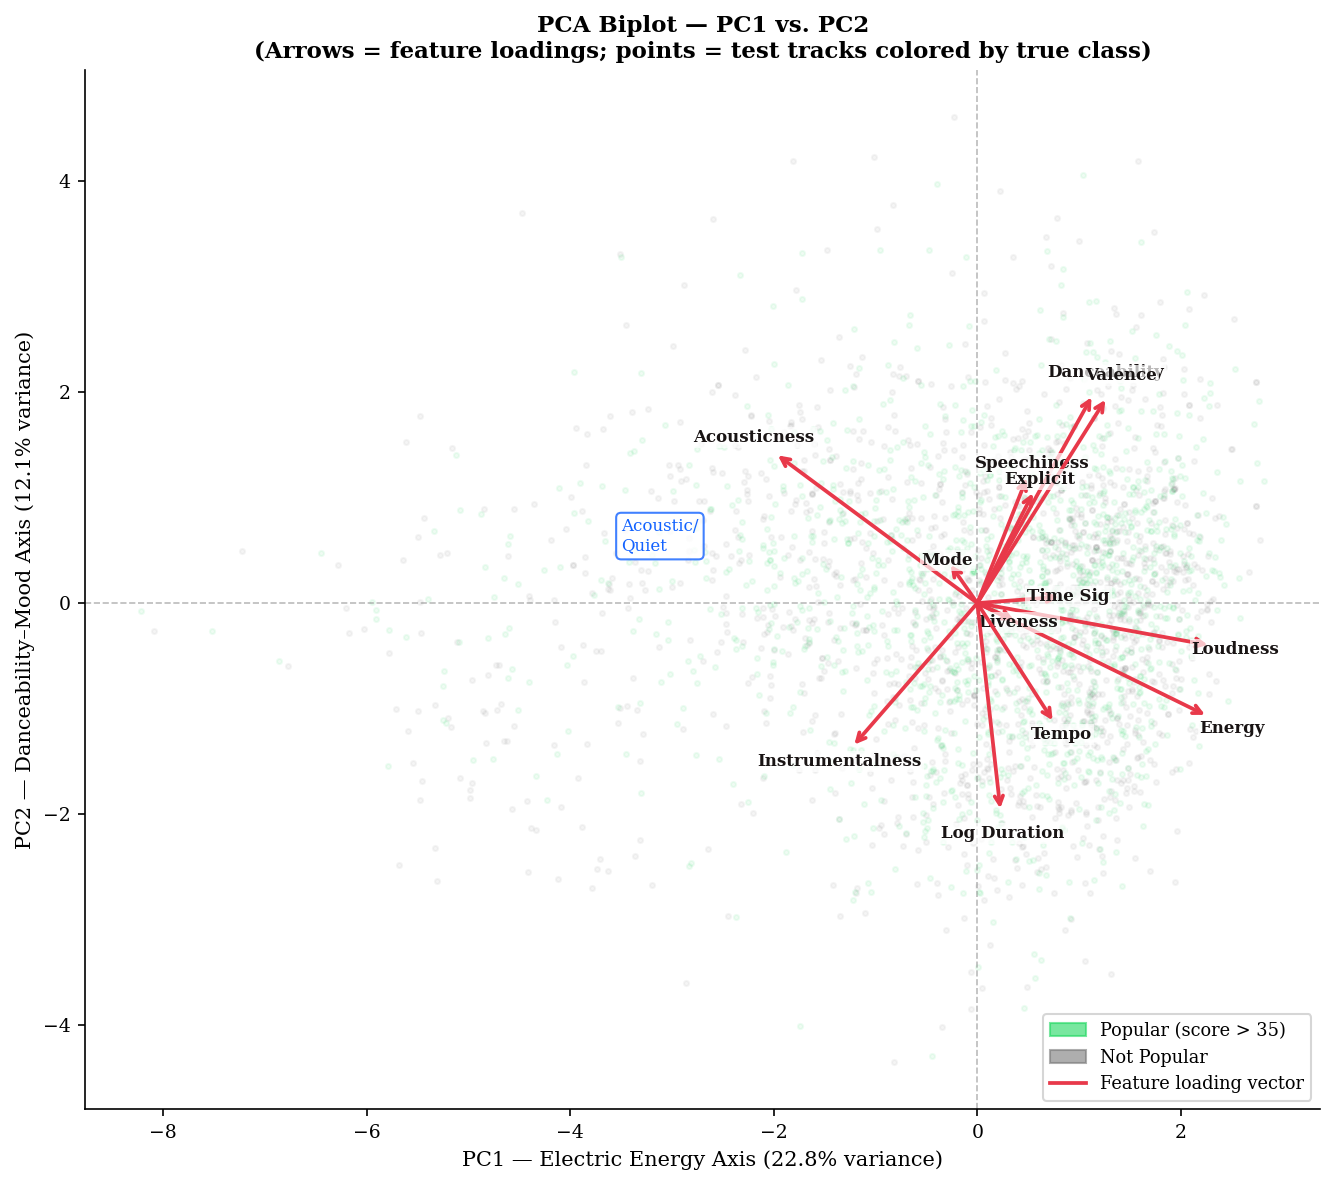

In [5]:
"""
MATH 4230 — Capstone Project
Chapter 12: Principal Component Analysis
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch12_scree.png    : scree plot (individual + cumulative variance)
  Figure 2 — ch12_heatmap.png  : full loading heatmap (13 x 13)
  Figure 3 — ch12_biplot.png   : biplot PC1 vs PC2 with feature vectors
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

GREEN  = "#1ED760"
DARK   = "#191414"
GRAY   = "#787878"
BLUE   = "#1262FF"
RED    = "#E8394A"
ORANGE = "#FF8C00"

# ── Load & prepare ────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]     = (df["popularity"] > 35).astype(int)
df["tempo"]          = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0, np.nan).median())
df["time_signature"] = df["time_signature"].replace(0, np.nan).fillna(4.0)
df["log_duration"]   = np.log(df["duration_ms"])
df["explicit_int"]   = df["explicit"].astype(int)

FEATS = ["danceability","energy","loudness","speechiness","acousticness",
         "instrumentalness","liveness","valence","tempo","log_duration",
         "mode","explicit_int","time_signature"]
FEAT_LABELS = ["Danceability","Energy","Loudness","Speechiness","Acousticness",
               "Instrumentalness","Liveness","Valence","Tempo","Log Duration",
               "Mode","Explicit","Time Sig"]

X  = df[FEATS].astype(float)
y  = df["popularity"]
yb = df["is_popular"]

# ── Split ─────────────────────────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

# ── Fit PCA ───────────────────────────────────────────────────────────────────
pca = PCA(random_state=42)
pca.fit(X_tr_s)

evr      = pca.explained_variance_ratio_
cev      = np.cumsum(evr)
eigenval = pca.explained_variance_
loadings = pca.components_.T   # shape (13 features, 13 components)
n_comp   = len(evr)

# PC scores for biplot (apply to test set)
X_te_pc  = pca.transform(X_te_s)

print(f"Variance explained by 4 components: {cev[3]:.3f}")
print(f"Features: {len(FEATS)}")


# =============================================================================
# FIGURE 1 — Scree plot
# =============================================================================
fig, ax1 = plt.subplots(figsize=(10, 5), facecolor="white")

x = np.arange(1, n_comp + 1)

# Bars: individual variance
bars = ax1.bar(x, evr * 100, color=BLUE, alpha=0.75,
               edgecolor="white", width=0.65, label="Individual variance (%)")

# Highlight retained components (Kaiser)
kaiser_n = int((eigenval > 1).sum())
for i in range(kaiser_n):
    bars[i].set_color(GREEN)
    bars[i].set_alpha(0.9)

ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Individual Variance Explained (%)", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.set_xticks(x)
ax1.set_xticklabels([f"PC{i}" for i in x], fontsize=8)
ax1.set_ylim(0, 28)

# Right axis: cumulative variance
ax2 = ax1.twinx()
ax2.spines["right"].set_visible(True)
ax2.plot(x, cev * 100, color=RED, linewidth=2.2,
         marker="o", markersize=6, label="Cumulative variance (%)")
ax2.axhline(80, color=GRAY, linewidth=1.2, linestyle=":",
            label="80% threshold")
ax2.axhline(90, color=GRAY, linewidth=1.0, linestyle="--",
            alpha=0.6, label="90% threshold")
ax2.set_ylabel("Cumulative Variance Explained (%)", color=RED)
ax2.tick_params(axis="y", labelcolor=RED)
ax2.set_ylim(0, 110)

# Kaiser line
ax1.axhline(100 * 1 / n_comp, color=ORANGE, linewidth=1.5,
            linestyle="--", label=f"Kaiser criterion (eigenvalue = 1)")
ax1.annotate(f"Kaiser: {kaiser_n} components retained",
             xy=(kaiser_n + 0.5, 8), fontsize=8.5, color=ORANGE)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=8, loc="center right")

ax1.set_title("PCA Scree Plot — Spotify Audio Features (13 Components)\n"
              "Green bars = Kaiser-retained components",
              fontweight="bold")

plt.tight_layout()
plt.savefig("ch12_scree.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — Loading heatmap (13 x 13)
# =============================================================================
# Custom diverging colormap: blue → white → red
cmap_div = LinearSegmentedColormap.from_list(
    "bwr_custom", [BLUE, "white", RED], N=256)

fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")

im = ax.imshow(loadings, cmap=cmap_div, vmin=-0.7, vmax=0.7,
               aspect="auto")

# Axis labels
ax.set_xticks(range(n_comp))
ax.set_xticklabels([f"PC{i+1}" for i in range(n_comp)], fontsize=9)
ax.set_yticks(range(len(FEAT_LABELS)))
ax.set_yticklabels(FEAT_LABELS, fontsize=9)

# Annotate cells
for i in range(len(FEAT_LABELS)):
    for j in range(n_comp):
        val  = loadings[i, j]
        col  = "white" if abs(val) > 0.35 else DARK
        bold = "bold" if abs(val) > 0.35 else "normal"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color=col, fontweight=bold)

# Highlight retained components with box
for j in range(kaiser_n):
    ax.add_patch(plt.Rectangle((j - 0.5, -0.5),
                                1, len(FEAT_LABELS),
                                fill=False, edgecolor=GREEN,
                                linewidth=2.5, zorder=5))

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Loading", fontsize=9)

ax.set_title("PCA Loading Matrix — All 13 Components\n"
             "Green outline = Kaiser-retained components (PC1–PC4)",
             fontsize=12, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("ch12_heatmap.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 3 — Biplot: PC1 vs PC2 with feature vectors
# =============================================================================
np.random.seed(42)
samp = np.random.choice(len(X_te_pc), 3000, replace=False)
scores_1 = X_te_pc[samp, 0]
scores_2 = X_te_pc[samp, 1]
labels_s  = yb_test.values[samp]

fig, ax = plt.subplots(figsize=(9, 8), facecolor="white")

# Scatter: test observations colored by true popularity class
ax.scatter(scores_1[labels_s == 0], scores_2[labels_s == 0],
           alpha=0.07, s=6, color=GRAY,  rasterized=True,
           label="Not Popular")
ax.scatter(scores_1[labels_s == 1], scores_2[labels_s == 1],
           alpha=0.07, s=6, color=GREEN, rasterized=True,
           label="Popular")

# Feature loading vectors (scaled for visibility)
scale = 4.5
for i, label in enumerate(FEAT_LABELS):
    lx = loadings[i, 0] * scale
    ly = loadings[i, 1] * scale
    ax.annotate("",
                xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=RED,
                                lw=1.8, shrinkA=0, shrinkB=0))
    # Offset label slightly beyond arrow tip
    offset_x = lx * 1.12
    offset_y = ly * 1.12
    ax.text(offset_x, offset_y, label,
            ha="center", va="center",
            fontsize=8, color=DARK, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none",
                      alpha=0.7, pad=1))

ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color=GRAY, linewidth=0.8, linestyle="--", alpha=0.5)

# Ellipse annotations for clusters
ax.annotate("Loud/\nEnergetic",
            xy=(3.5, -0.5), fontsize=8, color=BLUE,
            bbox=dict(facecolor="white", edgecolor=BLUE,
                      boxstyle="round,pad=0.3", alpha=0.8))
ax.annotate("Acoustic/\nQuiet",
            xy=(-3.5, 0.5), fontsize=8, color=BLUE,
            bbox=dict(facecolor="white", edgecolor=BLUE,
                      boxstyle="round,pad=0.3", alpha=0.8))

ax.set_xlabel(f"PC1 — Electric Energy Axis ({evr[0]*100:.1f}% variance)",
              fontsize=10)
ax.set_ylabel(f"PC2 — Danceability–Mood Axis ({evr[1]*100:.1f}% variance)",
              fontsize=10)
ax.set_title("PCA Biplot — PC1 vs. PC2\n"
             "(Arrows = feature loadings; points = test tracks colored by true class)",
             fontweight="bold")

pop_p   = mpatches.Patch(color=GREEN, alpha=0.6, label="Popular (score > 35)")
notpop  = mpatches.Patch(color=GRAY,  alpha=0.6, label="Not Popular")
arrow_l = plt.Line2D([0],[0], color=RED, linewidth=1.8,
                     label="Feature loading vector")
ax.legend(handles=[pop_p, notpop, arrow_l], fontsize=8.5,
          loc="lower right")

plt.tight_layout()
plt.savefig("ch12_biplot.png", dpi=300, bbox_inches="tight")

Fitting neural network regressor (256, 128)...
  Test RMSE = 18.3730   R² = 0.3245   Epochs = 36
Fitting neural network classifier (256, 128)...
  Test AUC  = 0.8658   Acc = 0.7811   Epochs = 20


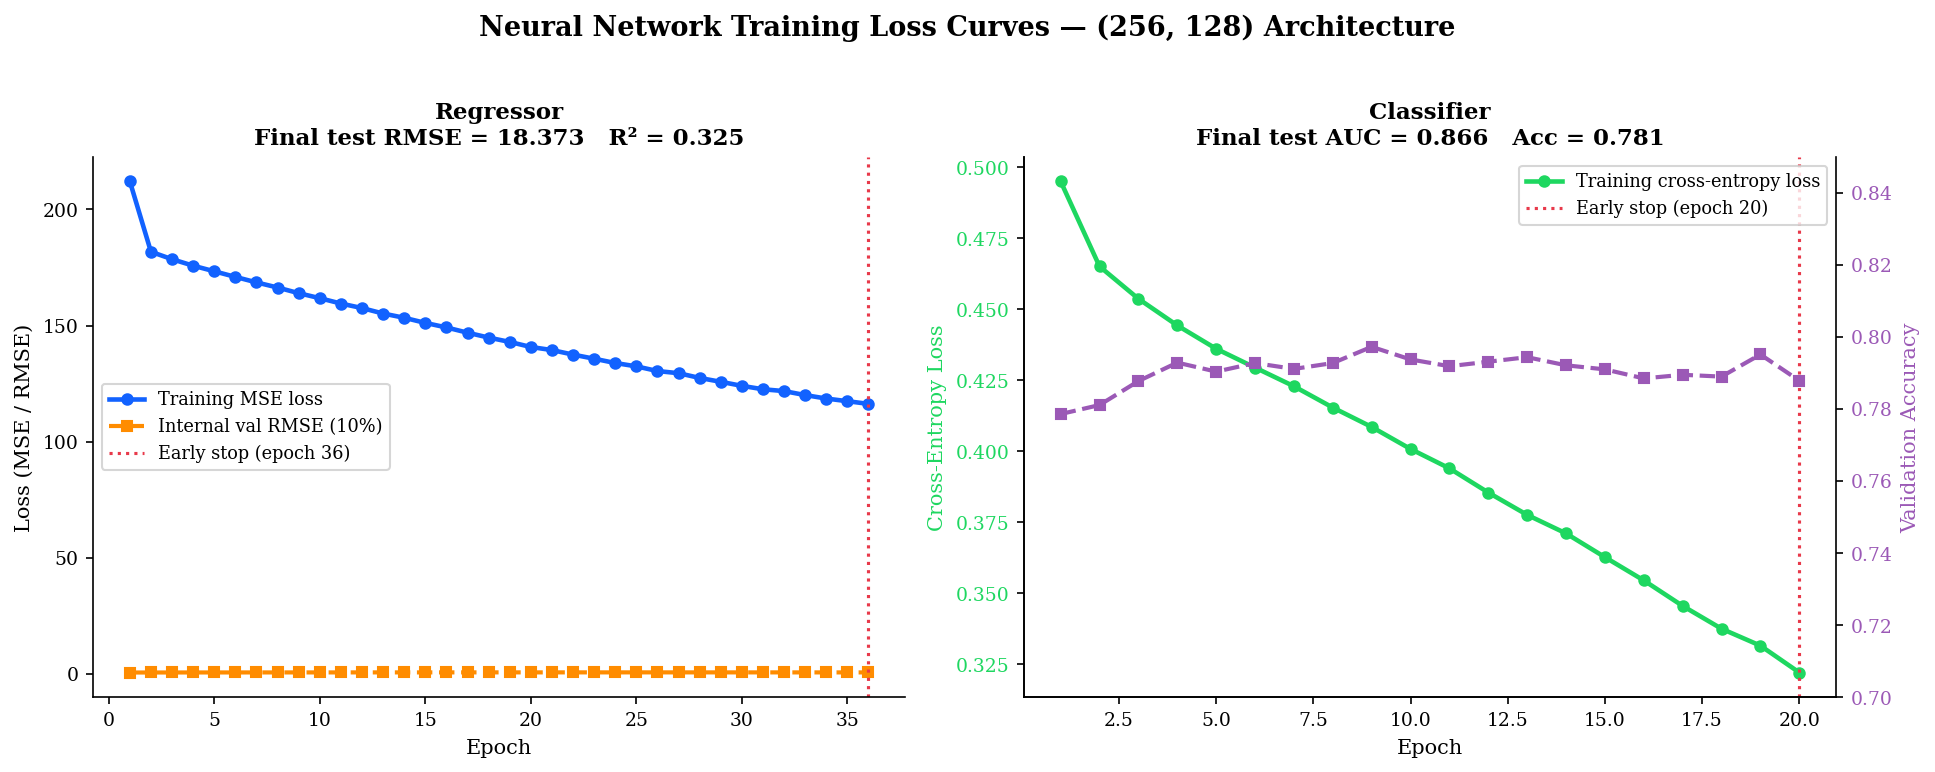

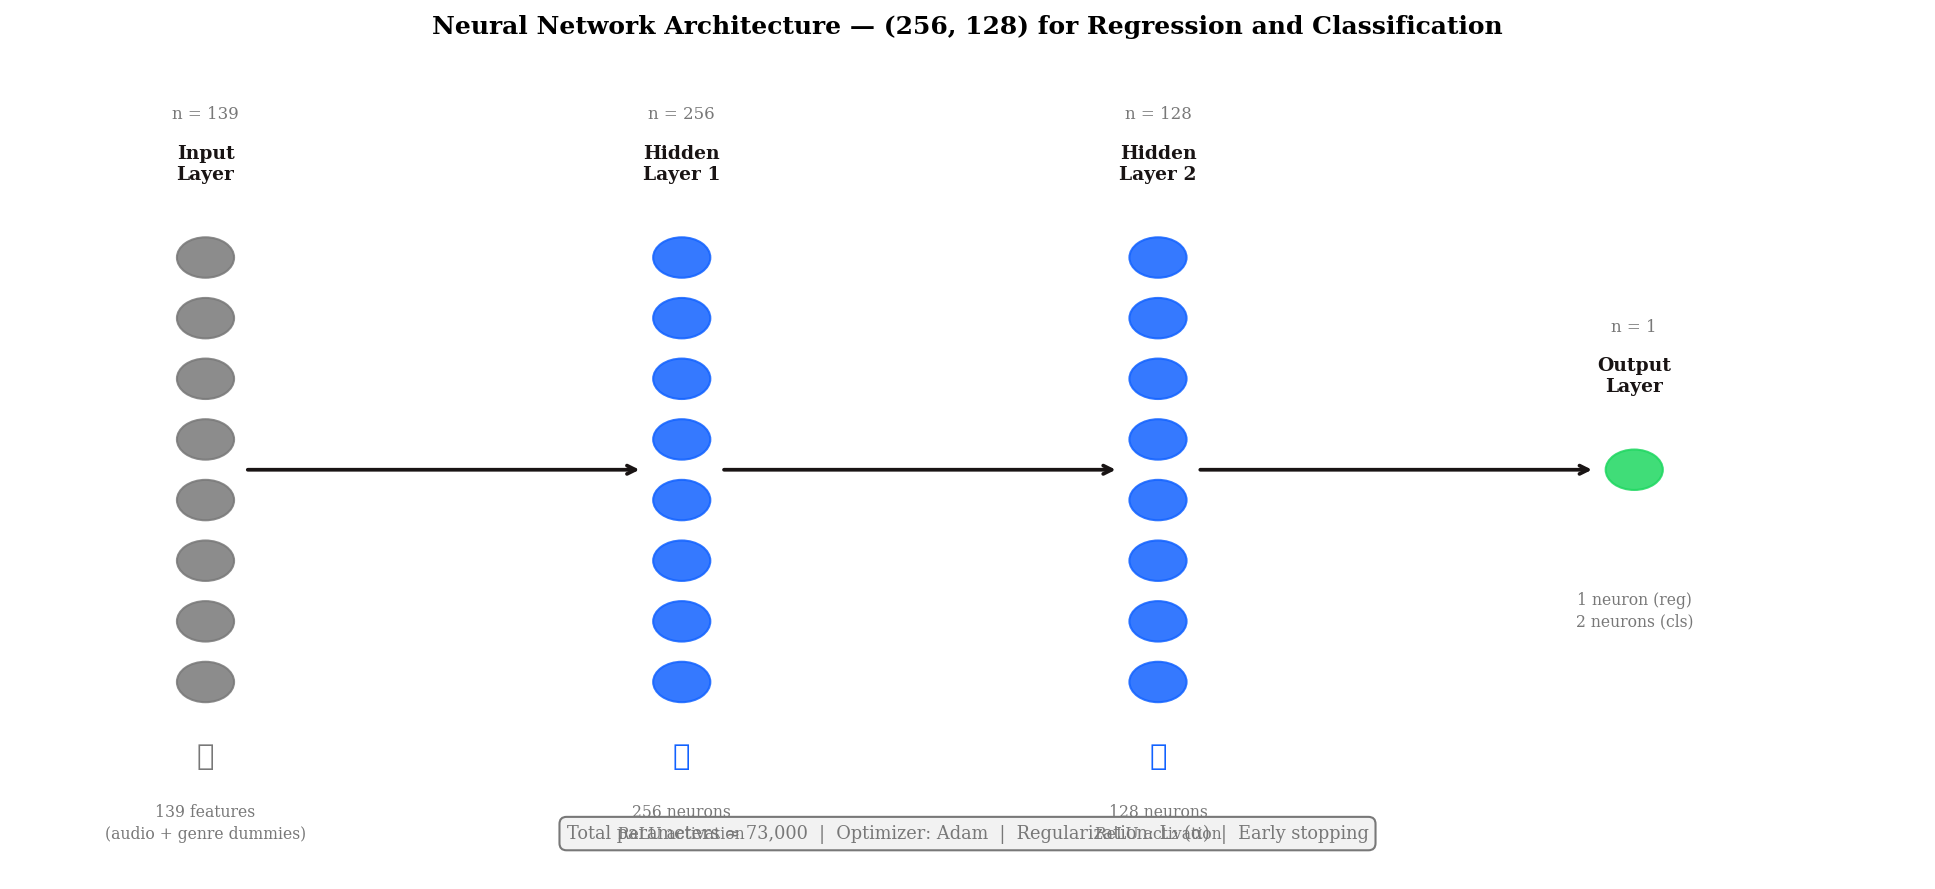

In [6]:
"""
MATH 4230 — Capstone Project
Chapter 13: Neural Networks
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch13_loss_curves.png   : training loss curves (regressor + classifier)
  Figure 2 — ch13_architecture.png  : network architecture diagram
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_squared_error, roc_auc_score, accuracy_score
import warnings

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
})

GREEN  = "#1ED760"
DARK   = "#191414"
GRAY   = "#787878"
BLUE   = "#1262FF"
RED    = "#E8394A"
ORANGE = "#FF8C00"
PURPLE = "#9B59B6"

# ── Load & prepare ────────────────────────────────────────────────────────────
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
df = df.dropna(subset=["artists", "album_name", "track_name"]).reset_index(drop=True)
df["is_popular"]     = (df["popularity"] > 35).astype(int)
df["tempo"]          = df["tempo"].replace(0, np.nan).fillna(df["tempo"].replace(0, np.nan).median())
df["time_signature"] = df["time_signature"].replace(0, np.nan).fillna(4.0)
df["log_duration"]   = np.log(df["duration_ms"])
df["explicit_int"]   = df["explicit"].astype(int)
df["key_int"]        = df["key"].astype(int)
df["ts_int"]         = df["time_signature"].astype(int)

CONT = ["danceability","energy","loudness","speechiness","acousticness",
        "instrumentalness","liveness","valence","tempo","log_duration"]
BIN  = ["mode","explicit_int"]
key_d   = pd.get_dummies(df["key_int"],     prefix="key",   drop_first=True)
ts_d    = pd.get_dummies(df["ts_int"],      prefix="ts",    drop_first=True)
genre_d = pd.get_dummies(df["track_genre"], prefix="genre", drop_first=True)

X_full = pd.concat([df[CONT + BIN], key_d, ts_d, genre_d], axis=1).astype(float)
y  = df["popularity"]
yb = df["is_popular"]

# ── Split ─────────────────────────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X_full, y, yb, test_size=0.15, random_state=42, stratify=yb)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv, test_size=0.15/0.85, random_state=42, stratify=yb_tv)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

# ── Fit best models ───────────────────────────────────────────────────────────
print("Fitting neural network regressor (256, 128)...")
nn_reg = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    alpha=0.0001,
    verbose=False
)
nn_reg.fit(X_tr_s, y_train)
te_rmse = np.sqrt(mean_squared_error(y_test, nn_reg.predict(X_te_s)))
te_r2   = nn_reg.score(X_te_s, y_test)
print(f"  Test RMSE = {te_rmse:.4f}   R² = {te_r2:.4f}   Epochs = {nn_reg.n_iter_}")

print("Fitting neural network classifier (256, 128)...")
nn_cls = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    alpha=0.001,
    verbose=False
)
nn_cls.fit(X_tr_s, yb_train)
te_auc = roc_auc_score(yb_test, nn_cls.predict_proba(X_te_s)[:, 1])
te_acc = accuracy_score(yb_test, nn_cls.predict(X_te_s))
print(f"  Test AUC  = {te_auc:.4f}   Acc = {te_acc:.4f}   Epochs = {nn_cls.n_iter_}")


# =============================================================================
# FIGURE 1 — Training loss curves
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
fig.suptitle("Neural Network Training Loss Curves — (256, 128) Architecture",
             fontsize=13, fontweight="bold", y=1.02)

# Left — Regression (MSE loss)
ax = axes[0]
epochs_reg = np.arange(1, len(nn_reg.loss_curve_) + 1)
ax.plot(epochs_reg, nn_reg.loss_curve_,
        color=BLUE, linewidth=2.2, marker="o", markersize=5,
        label="Training MSE loss")

# Val scores are neg MSE for regressor — convert to RMSE
if hasattr(nn_reg, "validation_scores_") and nn_reg.validation_scores_ is not None:
    val_rmse = np.sqrt(np.abs(nn_reg.validation_scores_))
    ax.plot(epochs_reg, val_rmse,
            color=ORANGE, linewidth=2.0, marker="s", markersize=5,
            linestyle="--", label="Internal val RMSE (10%)")

ax.axvline(nn_reg.n_iter_, color=RED, linewidth=1.5,
           linestyle=":", label=f"Early stop (epoch {nn_reg.n_iter_})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE / RMSE)")
ax.set_title(f"Regressor\nFinal test RMSE = {te_rmse:.3f}   R² = {te_r2:.3f}",
             fontweight="bold")
ax.legend(fontsize=8.5)

# Right — Classifier (cross-entropy)
ax2 = axes[1]
epochs_cls = np.arange(1, len(nn_cls.loss_curve_) + 1)
ax2.plot(epochs_cls, nn_cls.loss_curve_,
         color=GREEN, linewidth=2.2, marker="o", markersize=5,
         label="Training cross-entropy loss")

if hasattr(nn_cls, "validation_scores_") and nn_cls.validation_scores_ is not None:
    ax2_r = ax2.twinx()
    ax2_r.spines["right"].set_visible(True)
    ax2_r.plot(epochs_cls, nn_cls.validation_scores_,
               color=PURPLE, linewidth=2.0, marker="s", markersize=5,
               linestyle="--", label="Internal val accuracy (10%)")
    ax2_r.set_ylabel("Validation Accuracy", color=PURPLE)
    ax2_r.tick_params(axis="y", labelcolor=PURPLE)
    ax2_r.set_ylim(0.7, 0.85)

ax2.axvline(nn_cls.n_iter_, color=RED, linewidth=1.5,
            linestyle=":", label=f"Early stop (epoch {nn_cls.n_iter_})")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Cross-Entropy Loss", color=GREEN)
ax2.tick_params(axis="y", labelcolor=GREEN)
ax2.set_title(f"Classifier\nFinal test AUC = {te_auc:.3f}   Acc = {te_acc:.3f}",
              fontweight="bold")
ax2.legend(fontsize=8.5, loc="upper right")

plt.tight_layout()
plt.savefig("ch13_loss_curves.png", dpi=300, bbox_inches="tight")

# =============================================================================
# FIGURE 2 — Architecture diagram
# =============================================================================
fig, ax = plt.subplots(figsize=(13, 6), facecolor="white")
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")
ax.set_facecolor("white")

fig.suptitle("Neural Network Architecture — (256, 128) for Regression and Classification",
             fontsize=12, fontweight="bold", y=0.98)

# Layer definitions: (x_center, label, n_neurons, color, subtitle)
layers = [
    (1.0,  "Input\nLayer",      139, GRAY,   "139 features\n(audio + genre dummies)"),
    (3.5,  "Hidden\nLayer 1",   256, BLUE,   "256 neurons\nReLU activation"),
    (6.0,  "Hidden\nLayer 2",   128, BLUE,   "128 neurons\nReLU activation"),
    (8.5,  "Output\nLayer",       1, GREEN,  "1 neuron (reg)\n2 neurons (cls)"),
]

def draw_layer(ax, x, label, n, color, subtitle, max_dots=8):
    """Draw a layer as a stack of circles with label."""
    y_center  = 3.0
    dot_space = 0.45
    show_n    = min(n, max_dots)
    total_h   = (show_n - 1) * dot_space
    y_start   = y_center + total_h / 2

    for i in range(show_n):
        y = y_start - i * dot_space
        circle = plt.Circle((x, y), 0.15, color=color, alpha=0.85, zorder=3)
        ax.add_patch(circle)

    # Ellipsis if truncated
    if n > max_dots:
        ax.text(x, y_center - total_h / 2 - 0.55, "⋮",
                ha="center", va="center", fontsize=14, color=color)

    # Label above
    ax.text(x, y_center + total_h / 2 + 0.55,
            label, ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=DARK)
    # Neuron count
    ax.text(x, y_center + total_h / 2 + 1.0,
            f"n = {n:,}", ha="center", va="bottom",
            fontsize=8, color=GRAY)
    # Subtitle below
    ax.text(x, y_center - total_h / 2 - 0.9,
            subtitle, ha="center", va="top",
            fontsize=7.5, color=GRAY, linespacing=1.4)

for x, lbl, n, col, sub in layers:
    draw_layer(ax, x, lbl, n, col, sub)

# Arrows between layers
arrow_ys = [3.0]
for i in range(len(layers) - 1):
    x1 = layers[i][0]   + 0.2
    x2 = layers[i+1][0] - 0.2
    ax.annotate("",
                xy=(x2, 3.0), xytext=(x1, 3.0),
                arrowprops=dict(arrowstyle="->", color=DARK,
                                lw=1.8, connectionstyle="arc3,rad=0"))

# Annotation: weight count
ax.text(5.0, 0.3,
        "Total parameters ≈ 73,000  |  Optimizer: Adam  |  "
        "Regularization: L₂ (α)  |  Early stopping",
        ha="center", va="center", fontsize=8.5, color=GRAY,
        bbox=dict(facecolor=f"{GRAY}18", edgecolor=GRAY,
                  boxstyle="round,pad=0.4"))

plt.tight_layout()
plt.savefig("ch13_architecture.png", dpi=300, bbox_inches="tight")

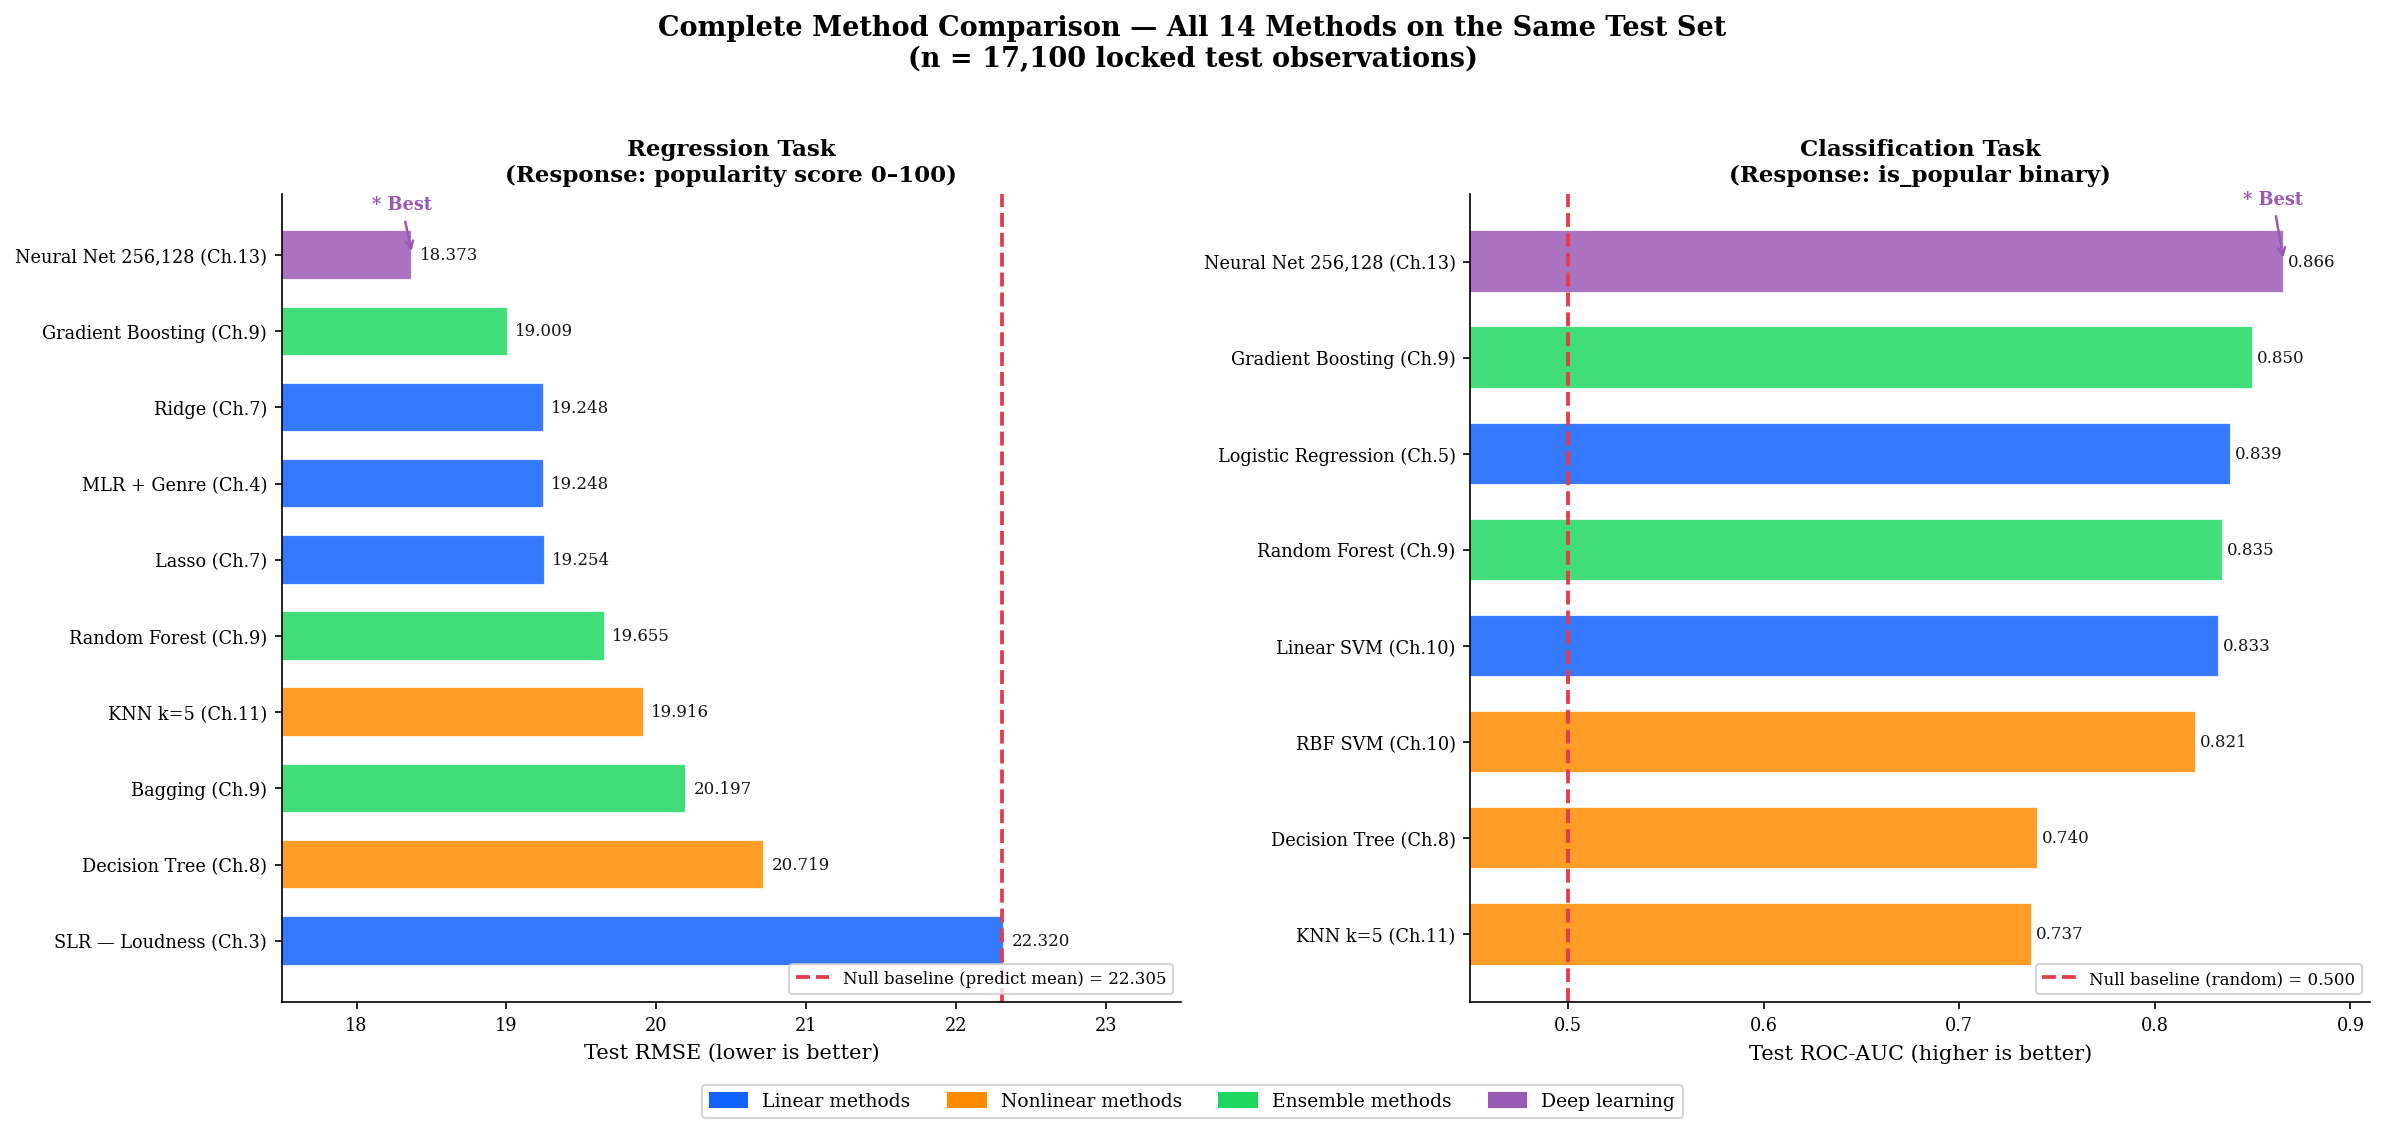

In [7]:
"""
MATH 4230 — Capstone Project
Chapter 14: Synthesis, Reflection, and Limitations
Author: Ezequiel Andrade

Figures produced (display only — save manually):
  Figure 1 — ch14_comparison.png : full method comparison bar chart (RMSE + AUC)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 150,
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 8.5,
    "ytick.labelsize"  : 8.5,
})

GREEN  = "#1ED760"
DARK   = "#191414"
GRAY   = "#787878"
BLUE   = "#1262FF"
RED    = "#E8394A"
ORANGE = "#FF8C00"
PURPLE = "#9B59B6"

# ── All results ───────────────────────────────────────────────────────────────
# Regression methods (sorted worst → best RMSE for display)
reg_methods = [
    ("SLR — Loudness (Ch.3)",        22.320, "Linear"),
    ("Decision Tree (Ch.8)",         20.719, "Nonlinear"),
    ("Bagging (Ch.9)",               20.197, "Ensemble"),
    ("KNN k=5 (Ch.11)",              19.916, "Nonlinear"),
    ("Random Forest (Ch.9)",         19.655, "Ensemble"),
    ("Lasso (Ch.7)",                 19.254, "Linear"),
    ("MLR + Genre (Ch.4)",           19.248, "Linear"),
    ("Ridge (Ch.7)",                 19.248, "Linear"),
    ("Gradient Boosting (Ch.9)",     19.009, "Ensemble"),
    ("Neural Net 256,128 (Ch.13)",   18.373, "Deep"),
]

# Classification methods (sorted worst → best AUC for display)
cls_methods = [
    ("KNN k=5 (Ch.11)",              0.737, "Nonlinear"),
    ("Decision Tree (Ch.8)",         0.740, "Nonlinear"),
    ("RBF SVM (Ch.10)",              0.821, "Nonlinear"),
    ("Linear SVM (Ch.10)",           0.833, "Linear"),
    ("Random Forest (Ch.9)",         0.835, "Ensemble"),
    ("Logistic Regression (Ch.5)",   0.839, "Linear"),
    ("Gradient Boosting (Ch.9)",     0.850, "Ensemble"),
    ("Neural Net 256,128 (Ch.13)",   0.866, "Deep"),
]

# Color map by method type
TYPE_COLORS = {
    "Linear":    BLUE,
    "Nonlinear": ORANGE,
    "Ensemble":  GREEN,
    "Deep":      PURPLE,
}

NULL_RMSE = 22.305
NULL_AUC  = 0.500

# =============================================================================
# FIGURE 1 — Full comparison chart
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="white")
fig.suptitle("Complete Method Comparison — All 14 Methods on the Same Test Set\n"
             "(n = 17,100 locked test observations)",
             fontsize=13, fontweight="bold", y=1.02)

# ── Left: Regression RMSE ────────────────────────────────────────────────────
ax = axes[0]
names_r  = [m[0] for m in reg_methods]
rmses    = [m[1] for m in reg_methods]
colors_r = [TYPE_COLORS[m[2]] for m in reg_methods]
y_pos    = np.arange(len(names_r))

bars = ax.barh(y_pos, rmses, color=colors_r, edgecolor="white",
               height=0.65, alpha=0.85)

# Value labels
for bar, val in zip(bars, rmses):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8, color=DARK)

# Null model baseline
ax.axvline(NULL_RMSE, color=RED, linewidth=1.8, linestyle="--",
           label=f"Null baseline (predict mean) = {NULL_RMSE:.3f}")

ax.set_yticks(y_pos)
ax.set_yticklabels(names_r, fontsize=8.5)
ax.set_xlabel("Test RMSE (lower is better)")
ax.set_title("Regression Task\n(Response: popularity score 0–100)",
             fontweight="bold")
ax.set_xlim(17.5, 23.5)
ax.legend(fontsize=8, loc="lower right")

# Annotate best
ax.annotate("* Best", xy=(18.373, y_pos[-1]),
            xytext=(18.1, y_pos[-1] + 0.6),
            fontsize=8.5, color=PURPLE, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=PURPLE, lw=1.2))

# ── Right: Classification AUC ─────────────────────────────────────────────────
ax2 = axes[1]
names_c  = [m[0] for m in cls_methods]
aucs     = [m[1] for m in cls_methods]
colors_c = [TYPE_COLORS[m[2]] for m in cls_methods]
y_pos2   = np.arange(len(names_c))

bars2 = ax2.barh(y_pos2, aucs, color=colors_c, edgecolor="white",
                 height=0.65, alpha=0.85)

for bar, val in zip(bars2, aucs):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=8, color=DARK)

ax2.axvline(NULL_AUC, color=RED, linewidth=1.8, linestyle="--",
            label=f"Null baseline (random) = {NULL_AUC:.3f}")

ax2.set_yticks(y_pos2)
ax2.set_yticklabels(names_c, fontsize=8.5)
ax2.set_xlabel("Test ROC-AUC (higher is better)")
ax2.set_title("Classification Task\n(Response: is_popular binary)",
              fontweight="bold")
ax2.set_xlim(0.45, 0.91)
ax2.legend(fontsize=8, loc="lower right")

ax2.annotate("* Best", xy=(0.866, y_pos2[-1]),
             xytext=(0.845, y_pos2[-1] + 0.6),
             fontsize=8.5, color=PURPLE, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=PURPLE, lw=1.2))

# ── Shared legend for method types ────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=BLUE,   label="Linear methods"),
    mpatches.Patch(color=ORANGE, label="Nonlinear methods"),
    mpatches.Patch(color=GREEN,  label="Ensemble methods"),
    mpatches.Patch(color=PURPLE, label="Deep learning"),
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=4, fontsize=9, frameon=True,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("ch14_comparison.png", dpi=300, bbox_inches="tight")